# **Trabalho 1 - EEL891: Introdução ao Aprendizado de Máquina**

## **Classificação de Aprovação de Crédito**

### Introdução
Este notebook contém a solução para o **Trabalho 1** da disciplina **EEL891 - Introdução ao Aprendizado de Máquina**, ofertada no período **2024-2**.  
O objetivo é desenvolver um classificador para apoiar a decisão de aprovação de crédito, buscando identificar clientes com alto risco de inadimplência.

Na prática, a instituição já possui critérios básicos para a aprovação de crédito. No entanto, mesmo após a aprovação, alguns clientes se tornam **inadimplentes**, ou seja, não conseguem honrar os pagamentos. Este projeto visa **antecipar esse comportamento** para evitar futuros prejuízos, ajudando a instituição a tomar decisões mais informadas.

---

### Objetivo do Projeto
O objetivo é construir um **classificador** capaz de prever, com base nos dados de uma nova solicitação de crédito, se o cliente será um **bom pagador** ou se ele apresentará **risco de inadimplência**.

### Descrição dos Dados
Você terá acesso a um **conjunto histórico** de 20.000 solicitações aprovadas, acompanhadas do desfecho real (inadimplente ou adimplente). Com base nesses dados, será desenvolvido e treinado um modelo preditivo.

- **Número de amostras históricas**: 20.000  
- **Número de amostras de teste (competição Kaggle)**: 5.000  
- **Alvo**: `Adimplente` (0 ou 1), indicando se o cliente honrou a dívida.  

O Kaggle irá medir automaticamente a **acurácia** das previsões feitas no conjunto de teste, sem revelar o gabarito. A competição entre os participantes da disciplina será baseada na **melhor performance do modelo preditivo**.

---

### Etapas do Projeto
- **Exploração e pré-processamento dos dados**:
  - Análise exploratória (EDA)
  - Tratamento de valores faltantes e outliers  
  - Codificação de variáveis categóricas  
  - Normalização/Padronização dos dados  

- **Treinamento do Modelo**:
  - Escolha de algoritmos de aprendizado de máquina  
  - Ajuste de hiperparâmetros  

- **Avaliação do Modelo**:
  - Divisão dos dados em treino/validação  
  - Avaliação com métricas apropriadas

- **Submissão no Kaggle**:
  - Preparação do arquivo de submissão com previsões  
  - Comparação dos resultados com os colegas na plataforma Kaggle

---

### Ferramentas e Bibliotecas
- **Python 3.x**  
- **Bibliotecas**:  
  - `pandas` - Manipulação de dados  
  - `numpy` - Operações matemáticas  
  - `scikit-learn` - Modelos de aprendizado de máquina  
  - `matplotlib` e `seaborn` - Visualização de dados

---

### Informações do Aluno
- **Nome**: Leonardo Soares da Costa Tanaka  
- **Curso**: Engenharia de Controle e Automação  
- **Faculdade**: Universidade Federal do Rio de Janeiro (UFRJ)

---

### Início do Desenvolvimento
Vamos começar o desenvolvimento carregando as bibliotecas necessárias e explorando o conjunto de dados históricos.


## 1. Importação das bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Coleta de Dados

In [3]:
df_train = pd.read_csv("data/conjunto_de_treinamento.csv")
df_test = pd.read_csv("data/conjunto_de_teste.csv")
print(list(df_train.columns))

['id_solicitante', 'produto_solicitado', 'dia_vencimento', 'forma_envio_solicitacao', 'tipo_endereco', 'sexo', 'idade', 'estado_civil', 'qtde_dependentes', 'grau_instrucao', 'nacionalidade', 'estado_onde_nasceu', 'estado_onde_reside', 'possui_telefone_residencial', 'codigo_area_telefone_residencial', 'tipo_residencia', 'meses_na_residencia', 'possui_telefone_celular', 'possui_email', 'renda_mensal_regular', 'renda_extra', 'possui_cartao_visa', 'possui_cartao_mastercard', 'possui_cartao_diners', 'possui_cartao_amex', 'possui_outros_cartoes', 'qtde_contas_bancarias', 'qtde_contas_bancarias_especiais', 'valor_patrimonio_pessoal', 'possui_carro', 'vinculo_formal_com_empresa', 'estado_onde_trabalha', 'possui_telefone_trabalho', 'codigo_area_telefone_trabalho', 'meses_no_trabalho', 'profissao', 'ocupacao', 'profissao_companheiro', 'grau_instrucao_companheiro', 'local_onde_reside', 'local_onde_trabalha', 'inadimplente']


In [4]:
df_train.head()

,id_solicitante,produto_solicitado,dia_vencimento,forma_envio_solicitacao,tipo_endereco,sexo,idade,estado_civil,qtde_dependentes,grau_instrucao,...,possui_telefone_trabalho,codigo_area_telefone_trabalho,meses_no_trabalho,profissao,ocupacao,profissao_companheiro,grau_instrucao_companheiro,local_onde_reside,local_onde_trabalha,inadimplente
0,1,1,10,presencial,1,M,85,2,0,0,...,N,,0,9.0,1.0,0.0,0.0,600.0,600.0,0
1,2,1,25,internet,1,F,38,1,0,0,...,N,,0,2.0,5.0,NaN,NaN,492.0,492.0,0
2,3,1,20,internet,1,F,37,2,0,0,...,N,,0,NaN,NaN,NaN,NaN,450.0,450.0,1
3,4,1,20,internet,1,M,37,1,1,0,...,Y,54,0,9.0,2.0,NaN,NaN,932.0,932.0,1
4,5,7,1,internet,1,F,51,1,3,0,...,N,,0,9.0,5.0,NaN,NaN,440.0,440.0,1


In [5]:
df_test.head()

,id_solicitante,produto_solicitado,dia_vencimento,forma_envio_solicitacao,tipo_endereco,sexo,idade,estado_civil,qtde_dependentes,grau_instrucao,...,estado_onde_trabalha,possui_telefone_trabalho,codigo_area_telefone_trabalho,meses_no_trabalho,profissao,ocupacao,profissao_companheiro,grau_instrucao_companheiro,local_onde_reside,local_onde_trabalha
0,20001,1,25,presencial,1,M,37,2,0,0,...,,N,,0,0.0,0.0,0.0,0.0,384.0,384.0
1,20002,1,10,internet,1,F,31,2,0,0,...,RJ,N,,0,9.0,5.0,NaN,NaN,275.0,275.0
2,20003,1,10,internet,1,F,18,2,0,0,...,RS,N,,0,9.0,2.0,NaN,NaN,948.0,948.0
3,20004,1,10,presencial,1,F,55,2,0,0,...,,N,,0,9.0,1.0,0.0,0.0,581.0,581.0
4,20005,1,10,presencial,1,F,55,1,0,0,...,,N,,0,0.0,1.0,0.0,0.0,573.0,573.0


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 42 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id_solicitante                    20000 non-null  int64  
 1   produto_solicitado                20000 non-null  int64  
 2   dia_vencimento                    20000 non-null  int64  
 3   forma_envio_solicitacao           20000 non-null  object 
 4   tipo_endereco                     20000 non-null  int64  
 5   sexo                              20000 non-null  object 
 6   idade                             20000 non-null  int64  
 7   estado_civil                      20000 non-null  int64  
 8   qtde_dependentes                  20000 non-null  int64  
 9   grau_instrucao                    20000 non-null  int64  
 10  nacionalidade                     20000 non-null  int64  
 11  estado_onde_nasceu                20000 non-null  object 
 12  esta

In [7]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id_solicitante                    5000 non-null   int64  
 1   produto_solicitado                5000 non-null   int64  
 2   dia_vencimento                    5000 non-null   int64  
 3   forma_envio_solicitacao           5000 non-null   object 
 4   tipo_endereco                     5000 non-null   int64  
 5   sexo                              5000 non-null   object 
 6   idade                             5000 non-null   int64  
 7   estado_civil                      5000 non-null   int64  
 8   qtde_dependentes                  5000 non-null   int64  
 9   grau_instrucao                    5000 non-null   int64  
 10  nacionalidade                     5000 non-null   int64  
 11  estado_onde_nasceu                5000 non-null   object 
 12  estado

## 3. Tratamento dos Dados

In [8]:
# Combina os dois DataFrames
df = pd.concat([df_train, df_test], ignore_index=True)
df.head()

,id_solicitante,produto_solicitado,dia_vencimento,forma_envio_solicitacao,tipo_endereco,sexo,idade,estado_civil,qtde_dependentes,grau_instrucao,...,possui_telefone_trabalho,codigo_area_telefone_trabalho,meses_no_trabalho,profissao,ocupacao,profissao_companheiro,grau_instrucao_companheiro,local_onde_reside,local_onde_trabalha,inadimplente
0,1,1,10,presencial,1,M,85,2,0,0,...,N,,0,9.0,1.0,0.0,0.0,600.0,600.0,0.0
1,2,1,25,internet,1,F,38,1,0,0,...,N,,0,2.0,5.0,NaN,NaN,492.0,492.0,0.0
2,3,1,20,internet,1,F,37,2,0,0,...,N,,0,NaN,NaN,NaN,NaN,450.0,450.0,1.0
3,4,1,20,internet,1,M,37,1,1,0,...,Y,54,0,9.0,2.0,NaN,NaN,932.0,932.0,1.0
4,5,7,1,internet,1,F,51,1,3,0,...,N,,0,9.0,5.0,NaN,NaN,440.0,440.0,1.0


In [9]:
# Aplicando One-Hot Encoding do Produto Solicitado
df = pd.get_dummies(df, columns=['produto_solicitado'], prefix='produto_solicitado',dtype=int)
df.head()

,id_solicitante,dia_vencimento,forma_envio_solicitacao,tipo_endereco,sexo,idade,estado_civil,qtde_dependentes,grau_instrucao,nacionalidade,...,profissao,ocupacao,profissao_companheiro,grau_instrucao_companheiro,local_onde_reside,local_onde_trabalha,inadimplente,produto_solicitado_1,produto_solicitado_2,produto_solicitado_7
0,1,10,presencial,1,M,85,2,0,0,1,...,9.0,1.0,0.0,0.0,600.0,600.0,0.0,1,0,0
1,2,25,internet,1,F,38,1,0,0,1,...,2.0,5.0,NaN,NaN,492.0,492.0,0.0,1,0,0
2,3,20,internet,1,F,37,2,0,0,1,...,NaN,NaN,NaN,NaN,450.0,450.0,1.0,1,0,0
3,4,20,internet,1,M,37,1,1,0,1,...,9.0,2.0,NaN,NaN,932.0,932.0,1.0,1,0,0
4,5,1,internet,1,F,51,1,3,0,1,...,9.0,5.0,NaN,NaN,440.0,440.0,1.0,0,0,1


In [10]:
# Aplicando One-Hot Encoding do Produto Solicitado
df = pd.get_dummies(df, columns=['dia_vencimento'], prefix='dia_vencimento',dtype=int)
df.head()

,id_solicitante,forma_envio_solicitacao,tipo_endereco,sexo,idade,estado_civil,qtde_dependentes,grau_instrucao,nacionalidade,estado_onde_nasceu,...,inadimplente,produto_solicitado_1,produto_solicitado_2,produto_solicitado_7,dia_vencimento_1,dia_vencimento_5,dia_vencimento_10,dia_vencimento_15,dia_vencimento_20,dia_vencimento_25
0,1,presencial,1,M,85,2,0,0,1,CE,...,0.0,1,0,0,0,0,1,0,0,0
1,2,internet,1,F,38,1,0,0,1,SE,...,0.0,1,0,0,0,0,0,0,0,1
2,3,internet,1,F,37,2,0,0,1,BA,...,1.0,1,0,0,0,0,0,0,1,0
3,4,internet,1,M,37,1,1,0,1,RS,...,1.0,1,0,0,0,0,0,0,1,0
4,5,internet,1,F,51,1,3,0,1,BA,...,1.0,0,0,1,1,0,0,0,0,0


In [11]:
# Aplicando One-Hot Encoding do Forma de Envio da Solicitação
df = pd.get_dummies(df, columns=['forma_envio_solicitacao'], prefix='forma_envio_solicitacao',dtype=int)
df.head()

,id_solicitante,tipo_endereco,sexo,idade,estado_civil,qtde_dependentes,grau_instrucao,nacionalidade,estado_onde_nasceu,estado_onde_reside,...,produto_solicitado_7,dia_vencimento_1,dia_vencimento_5,dia_vencimento_10,dia_vencimento_15,dia_vencimento_20,dia_vencimento_25,forma_envio_solicitacao_correio,forma_envio_solicitacao_internet,forma_envio_solicitacao_presencial
0,1,1,M,85,2,0,0,1,CE,CE,...,0,0,0,1,0,0,0,0,0,1
1,2,1,F,38,1,0,0,1,SE,SE,...,0,0,0,0,0,0,1,0,1,0
2,3,1,F,37,2,0,0,1,BA,BA,...,0,0,0,0,0,1,0,0,1,0
3,4,1,M,37,1,1,0,1,RS,RS,...,0,0,0,0,0,1,0,0,1,0
4,5,1,F,51,1,3,0,1,BA,BA,...,1,1,0,0,0,0,0,0,1,0


In [12]:
# Substitui valores ausentes ou inválidos por 'N'
df['sexo'] = df['sexo'].replace(['', ' ', None, np.nan], 'N')

# Aplica One-Hot Encoding do Sexo
df = pd.get_dummies(df, columns=['sexo'], prefix='sexo', dtype=int)
df.head()

,id_solicitante,tipo_endereco,idade,estado_civil,qtde_dependentes,grau_instrucao,nacionalidade,estado_onde_nasceu,estado_onde_reside,possui_telefone_residencial,...,dia_vencimento_10,dia_vencimento_15,dia_vencimento_20,dia_vencimento_25,forma_envio_solicitacao_correio,forma_envio_solicitacao_internet,forma_envio_solicitacao_presencial,sexo_F,sexo_M,sexo_N
0,1,1,85,2,0,0,1,CE,CE,Y,...,1,0,0,0,0,0,1,0,1,0
1,2,1,38,1,0,0,1,SE,SE,Y,...,0,0,0,1,0,1,0,1,0,0
2,3,1,37,2,0,0,1,BA,BA,Y,...,0,0,1,0,0,1,0,1,0,0
3,4,1,37,1,1,0,1,RS,RS,Y,...,0,0,1,0,0,1,0,0,1,0
4,5,1,51,1,3,0,1,BA,BA,Y,...,0,0,0,0,0,1,0,1,0,0


In [13]:
# Aplica One-Hot Encoding do Estado Civil
df = pd.get_dummies(df, columns=['estado_civil'], prefix='estado_civil', dtype=int)
df.head()

,id_solicitante,tipo_endereco,idade,qtde_dependentes,grau_instrucao,nacionalidade,estado_onde_nasceu,estado_onde_reside,possui_telefone_residencial,codigo_area_telefone_residencial,...,sexo_M,sexo_N,estado_civil_0,estado_civil_1,estado_civil_2,estado_civil_3,estado_civil_4,estado_civil_5,estado_civil_6,estado_civil_7
0,1,1,85,0,0,1,CE,CE,Y,107,...,1,0,0,0,1,0,0,0,0,0
1,2,1,38,0,0,1,SE,SE,Y,91,...,0,0,0,1,0,0,0,0,0,0
2,3,1,37,0,0,1,BA,BA,Y,90,...,0,0,0,0,1,0,0,0,0,0
3,4,1,37,1,0,1,RS,RS,Y,54,...,1,0,0,1,0,0,0,0,0,0
4,5,1,51,3,0,1,BA,BA,Y,86,...,0,0,0,1,0,0,0,0,0,0


In [14]:
# Verifica se a coluna 'grau_instrucao' contém apenas zeros
if (df['grau_instrucao'] == 0).all():
    df = df.drop(columns=['grau_instrucao'])

# Exibe as primeiras linhas do DataFrame atualizado
df.head()

,id_solicitante,tipo_endereco,idade,qtde_dependentes,nacionalidade,estado_onde_nasceu,estado_onde_reside,possui_telefone_residencial,codigo_area_telefone_residencial,tipo_residencia,...,sexo_M,sexo_N,estado_civil_0,estado_civil_1,estado_civil_2,estado_civil_3,estado_civil_4,estado_civil_5,estado_civil_6,estado_civil_7
0,1,1,85,0,1,CE,CE,Y,107,1.0,...,1,0,0,0,1,0,0,0,0,0
1,2,1,38,0,1,SE,SE,Y,91,1.0,...,0,0,0,1,0,0,0,0,0,0
2,3,1,37,0,1,BA,BA,Y,90,5.0,...,0,0,0,0,1,0,0,0,0,0
3,4,1,37,1,1,RS,RS,Y,54,1.0,...,1,0,0,1,0,0,0,0,0,0
4,5,1,51,3,1,BA,BA,Y,86,0.0,...,0,0,0,1,0,0,0,0,0,0


In [15]:
# Aplica One-Hot Encoding da Nacionalidade
df = pd.get_dummies(df, columns=['nacionalidade'], prefix='nacionalidade', dtype=int)
df.head()

,id_solicitante,tipo_endereco,idade,qtde_dependentes,estado_onde_nasceu,estado_onde_reside,possui_telefone_residencial,codigo_area_telefone_residencial,tipo_residencia,meses_na_residencia,...,estado_civil_1,estado_civil_2,estado_civil_3,estado_civil_4,estado_civil_5,estado_civil_6,estado_civil_7,nacionalidade_0,nacionalidade_1,nacionalidade_2
0,1,1,85,0,CE,CE,Y,107,1.0,12.0,...,0,1,0,0,0,0,0,0,1,0
1,2,1,38,0,SE,SE,Y,91,1.0,5.0,...,1,0,0,0,0,0,0,0,1,0
2,3,1,37,0,BA,BA,Y,90,5.0,1.0,...,0,1,0,0,0,0,0,0,1,0
3,4,1,37,1,RS,RS,Y,54,1.0,1.0,...,1,0,0,0,0,0,0,0,1,0
4,5,1,51,3,BA,BA,Y,86,0.0,1.0,...,1,0,0,0,0,0,0,0,1,0


In [16]:
# Substitui valores contendo apenas espaços por 'XX'
df['estado_onde_nasceu'] = df['estado_onde_nasceu'].replace(" ", "XX")

# Exibe a contagem dos valores únicos após a substituição
valores_unicos = df['estado_onde_nasceu'].value_counts(dropna=False)
print("Valores únicos em 'estado_onde_nasceu' após substituição:")
print(valores_unicos)

Valores únicos em 'estado_onde_nasceu' após substituição:
estado_onde_nasceu
BA    2918
SP    2891
CE    2408
RS    2398
PE    2069
MG    1840
XX    1032
RN    1015
PR     932
RJ     918
PA     856
AL     855
PB     770
MA     719
GO     569
MT     461
SC     344
PI     338
ES     317
MS     251
AC     246
SE     188
AM     177
DF     167
AP     129
TO     108
RO      66
RR      18
Name: count, dtype: int64


In [17]:
# Aplica One-Hot Encoding da Estado Onde Nasceu
df = pd.get_dummies(df, columns=['estado_onde_nasceu'], prefix='estado_onde_nasceu', dtype=int)
df.head()

,id_solicitante,tipo_endereco,idade,qtde_dependentes,estado_onde_reside,possui_telefone_residencial,codigo_area_telefone_residencial,tipo_residencia,meses_na_residencia,possui_telefone_celular,...,estado_onde_nasceu_RJ,estado_onde_nasceu_RN,estado_onde_nasceu_RO,estado_onde_nasceu_RR,estado_onde_nasceu_RS,estado_onde_nasceu_SC,estado_onde_nasceu_SE,estado_onde_nasceu_SP,estado_onde_nasceu_TO,estado_onde_nasceu_XX
0,1,1,85,0,CE,Y,107,1.0,12.0,N,...,0,0,0,0,0,0,0,0,0,0
1,2,1,38,0,SE,Y,91,1.0,5.0,N,...,0,0,0,0,0,0,1,0,0,0
2,3,1,37,0,BA,Y,90,5.0,1.0,N,...,0,0,0,0,0,0,0,0,0,0
3,4,1,37,1,RS,Y,54,1.0,1.0,N,...,0,0,0,0,1,0,0,0,0,0
4,5,1,51,3,BA,Y,86,0.0,1.0,N,...,0,0,0,0,0,0,0,0,0,0


In [18]:
# Substitui valores contendo apenas espaços por 'XX'
df['estado_onde_reside'] = df['estado_onde_reside'].replace("  ", "XX")

# Exibe a contagem dos valores únicos após a substituição
valores_unicos = df['estado_onde_reside'].value_counts(dropna=False)
print("Valores únicos em 'estado_onde_reside' após substituição:")
print(valores_unicos)

Valores únicos em 'estado_onde_reside' após substituição:
estado_onde_reside
SP    4435
BA    2536
RS    2489
CE    2346
PE    1864
MG    1521
PA    1147
RJ    1086
RN    1037
GO     848
AL     753
PR     736
MT     669
PB     628
MA     365
DF     362
MS     349
ES     342
SC     313
AP     257
AM     206
PI     192
RO     159
SE     156
AC     116
TO      59
RR      29
Name: count, dtype: int64


In [19]:
# Aplica One-Hot Encoding para 'estado_onde_reside'
df = pd.get_dummies(df, columns=['estado_onde_reside'], prefix='estado_onde_reside', dtype=int)
df.head()

,id_solicitante,tipo_endereco,idade,qtde_dependentes,possui_telefone_residencial,codigo_area_telefone_residencial,tipo_residencia,meses_na_residencia,possui_telefone_celular,possui_email,...,estado_onde_reside_PR,estado_onde_reside_RJ,estado_onde_reside_RN,estado_onde_reside_RO,estado_onde_reside_RR,estado_onde_reside_RS,estado_onde_reside_SC,estado_onde_reside_SE,estado_onde_reside_SP,estado_onde_reside_TO
0,1,1,85,0,Y,107,1.0,12.0,N,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,38,0,Y,91,1.0,5.0,N,1,...,0,0,0,0,0,0,0,1,0,0
2,3,1,37,0,Y,90,5.0,1.0,N,1,...,0,0,0,0,0,0,0,0,0,0
3,4,1,37,1,Y,54,1.0,1.0,N,1,...,0,0,0,0,0,1,0,0,0,0
4,5,1,51,3,Y,86,0.0,1.0,N,1,...,0,0,0,0,0,0,0,0,0,0


In [20]:
# Substitui 'Y' por 1 e 'N' por 0 na coluna 'possui_telefone_residencial'
df['possui_telefone_residencial'] = df['possui_telefone_residencial'].map({'Y': 1, 'N': 0})
print(df['possui_telefone_residencial'].dtype)
df.head()

int64


,id_solicitante,tipo_endereco,idade,qtde_dependentes,possui_telefone_residencial,codigo_area_telefone_residencial,tipo_residencia,meses_na_residencia,possui_telefone_celular,possui_email,...,estado_onde_reside_PR,estado_onde_reside_RJ,estado_onde_reside_RN,estado_onde_reside_RO,estado_onde_reside_RR,estado_onde_reside_RS,estado_onde_reside_SC,estado_onde_reside_SE,estado_onde_reside_SP,estado_onde_reside_TO
0,1,1,85,0,1,107,1.0,12.0,N,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,38,0,1,91,1.0,5.0,N,1,...,0,0,0,0,0,0,0,1,0,0
2,3,1,37,0,1,90,5.0,1.0,N,1,...,0,0,0,0,0,0,0,0,0,0
3,4,1,37,1,1,54,1.0,1.0,N,1,...,0,0,0,0,0,1,0,0,0,0
4,5,1,51,3,1,86,0.0,1.0,N,1,...,0,0,0,0,0,0,0,0,0,0


In [21]:
# Verificando valores únicos e suas frequências
valores_unicos = df['codigo_area_telefone_residencial'].value_counts(dropna=False)

# Exibindo os valores únicos e suas frequências
print(valores_unicos)

# Removendo a coluna 'codigo_area_telefone_residencial' do DataFrame
df = df.drop(columns=['codigo_area_telefone_residencial'])
df.head()

codigo_area_telefone_residencial
       4353
5      2319
107    1448
97     1432
54     1125
       ... 
113       1
109       1
17        1
2         1
98        1
Name: count, Length: 87, dtype: int64


,id_solicitante,tipo_endereco,idade,qtde_dependentes,possui_telefone_residencial,tipo_residencia,meses_na_residencia,possui_telefone_celular,possui_email,renda_mensal_regular,...,estado_onde_reside_PR,estado_onde_reside_RJ,estado_onde_reside_RN,estado_onde_reside_RO,estado_onde_reside_RR,estado_onde_reside_RS,estado_onde_reside_SC,estado_onde_reside_SE,estado_onde_reside_SP,estado_onde_reside_TO
0,1,1,85,0,1,1.0,12.0,N,0,480.0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,38,0,1,1.0,5.0,N,1,380.0,...,0,0,0,0,0,0,0,1,0,0
2,3,1,37,0,1,5.0,1.0,N,1,600.0,...,0,0,0,0,0,0,0,0,0,0
3,4,1,37,1,1,1.0,1.0,N,1,460.0,...,0,0,0,0,0,1,0,0,0,0
4,5,1,51,3,1,0.0,1.0,N,1,687.0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
# Substitui NaN por um valor específico, como -1
df['tipo_residencia'] = df['tipo_residencia'].fillna(-1).astype(int)

# Aplica One-Hot Encoding para 'tipo_residencia'
df = pd.get_dummies(df, columns=['tipo_residencia'], prefix='tipo_residencia', dtype=int)
df.head()

,id_solicitante,tipo_endereco,idade,qtde_dependentes,possui_telefone_residencial,meses_na_residencia,possui_telefone_celular,possui_email,renda_mensal_regular,renda_extra,...,estado_onde_reside_SE,estado_onde_reside_SP,estado_onde_reside_TO,tipo_residencia_-1,tipo_residencia_0,tipo_residencia_1,tipo_residencia_2,tipo_residencia_3,tipo_residencia_4,tipo_residencia_5
0,1,1,85,0,1,12.0,N,0,480.0,0.0,...,0,0,0,0,0,1,0,0,0,0
1,2,1,38,0,1,5.0,N,1,380.0,0.0,...,1,0,0,0,0,1,0,0,0,0
2,3,1,37,0,1,1.0,N,1,600.0,0.0,...,0,0,0,0,0,0,0,0,0,1
3,4,1,37,1,1,1.0,N,1,460.0,0.0,...,0,0,0,0,0,1,0,0,0,0
4,5,1,51,3,1,1.0,N,1,687.0,600.0,...,0,0,0,0,1,0,0,0,0,0


In [23]:
# Verificando os value_counts da coluna 'meses_na_residencia' e a quantidade de valores NaN
value_counts_meses_na_residencia = df['meses_na_residencia'].value_counts(dropna=False)
print(value_counts_meses_na_residencia)

meses_na_residencia
1.0     3661
0.0     2319
10.0    1931
5.0     1841
NaN     1812
        ... 
72.0       1
89.0       1
80.0       1
78.0       1
70.0       1
Name: count, Length: 81, dtype: int64


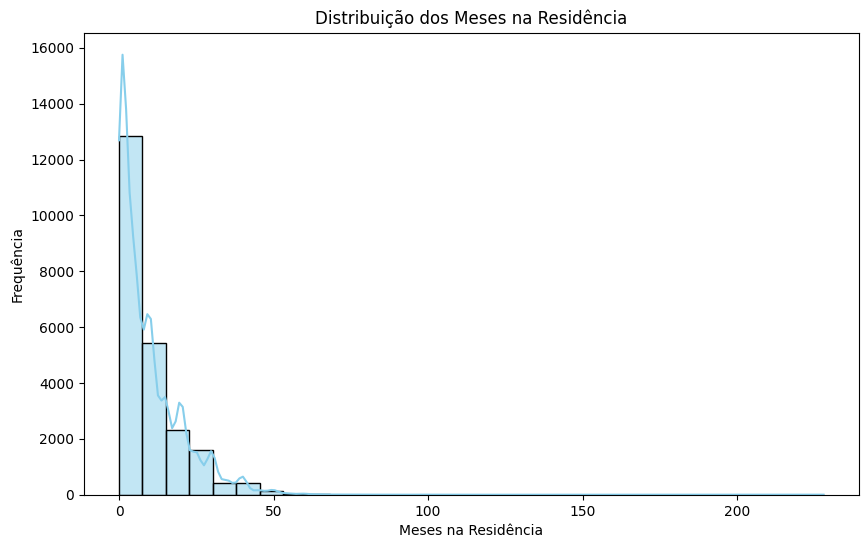

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(df['meses_na_residencia'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribuição dos Meses na Residência')
plt.xlabel('Meses na Residência')
plt.ylabel('Frequência')
plt.show()

In [25]:
# Substituindo valores NaN por 0 na coluna 'meses_na_residencia'
df['meses_na_residencia'] = df['meses_na_residencia'].fillna(0)
df.head()

,id_solicitante,tipo_endereco,idade,qtde_dependentes,possui_telefone_residencial,meses_na_residencia,possui_telefone_celular,possui_email,renda_mensal_regular,renda_extra,...,estado_onde_reside_SE,estado_onde_reside_SP,estado_onde_reside_TO,tipo_residencia_-1,tipo_residencia_0,tipo_residencia_1,tipo_residencia_2,tipo_residencia_3,tipo_residencia_4,tipo_residencia_5
0,1,1,85,0,1,12.0,N,0,480.0,0.0,...,0,0,0,0,0,1,0,0,0,0
1,2,1,38,0,1,5.0,N,1,380.0,0.0,...,1,0,0,0,0,1,0,0,0,0
2,3,1,37,0,1,1.0,N,1,600.0,0.0,...,0,0,0,0,0,0,0,0,0,1
3,4,1,37,1,1,1.0,N,1,460.0,0.0,...,0,0,0,0,0,1,0,0,0,0
4,5,1,51,3,1,1.0,N,1,687.0,600.0,...,0,0,0,0,1,0,0,0,0,0


In [26]:
# Remove a coluna 'possui_telefone_celular'
df.drop(columns=['possui_telefone_celular'], inplace=True)
df.head()

,id_solicitante,tipo_endereco,idade,qtde_dependentes,possui_telefone_residencial,meses_na_residencia,possui_email,renda_mensal_regular,renda_extra,possui_cartao_visa,...,estado_onde_reside_SE,estado_onde_reside_SP,estado_onde_reside_TO,tipo_residencia_-1,tipo_residencia_0,tipo_residencia_1,tipo_residencia_2,tipo_residencia_3,tipo_residencia_4,tipo_residencia_5
0,1,1,85,0,1,12.0,0,480.0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
1,2,1,38,0,1,5.0,1,380.0,0.0,0,...,1,0,0,0,0,1,0,0,0,0
2,3,1,37,0,1,1.0,1,600.0,0.0,0,...,0,0,0,0,0,0,0,0,0,1
3,4,1,37,1,1,1.0,1,460.0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
4,5,1,51,3,1,1.0,1,687.0,600.0,0,...,0,0,0,0,1,0,0,0,0,0


In [27]:
# Remove a coluna 'qtde_contas_bancarias_especiais'
df.drop(columns=['qtde_contas_bancarias_especiais'], inplace=True)
df.head()

,id_solicitante,tipo_endereco,idade,qtde_dependentes,possui_telefone_residencial,meses_na_residencia,possui_email,renda_mensal_regular,renda_extra,possui_cartao_visa,...,estado_onde_reside_SE,estado_onde_reside_SP,estado_onde_reside_TO,tipo_residencia_-1,tipo_residencia_0,tipo_residencia_1,tipo_residencia_2,tipo_residencia_3,tipo_residencia_4,tipo_residencia_5
0,1,1,85,0,1,12.0,0,480.0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
1,2,1,38,0,1,5.0,1,380.0,0.0,0,...,1,0,0,0,0,1,0,0,0,0
2,3,1,37,0,1,1.0,1,600.0,0.0,0,...,0,0,0,0,0,0,0,0,0,1
3,4,1,37,1,1,1.0,1,460.0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
4,5,1,51,3,1,1.0,1,687.0,600.0,0,...,0,0,0,0,1,0,0,0,0,0


In [28]:
# Substitui 'Y' por 1 e 'N' por 0 na coluna 'vinculo_formal_com_empresa'
df['vinculo_formal_com_empresa'] = df['vinculo_formal_com_empresa'].map({'Y': 1, 'N': 0})
print(df['vinculo_formal_com_empresa'].dtype)
df.head()

int64


,id_solicitante,tipo_endereco,idade,qtde_dependentes,possui_telefone_residencial,meses_na_residencia,possui_email,renda_mensal_regular,renda_extra,possui_cartao_visa,...,estado_onde_reside_SE,estado_onde_reside_SP,estado_onde_reside_TO,tipo_residencia_-1,tipo_residencia_0,tipo_residencia_1,tipo_residencia_2,tipo_residencia_3,tipo_residencia_4,tipo_residencia_5
0,1,1,85,0,1,12.0,0,480.0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
1,2,1,38,0,1,5.0,1,380.0,0.0,0,...,1,0,0,0,0,1,0,0,0,0
2,3,1,37,0,1,1.0,1,600.0,0.0,0,...,0,0,0,0,0,0,0,0,0,1
3,4,1,37,1,1,1.0,1,460.0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
4,5,1,51,3,1,1.0,1,687.0,600.0,0,...,0,0,0,0,1,0,0,0,0,0


In [29]:
# Substitui valores contendo apenas espaços por 'XX'
df['estado_onde_trabalha'] = df['estado_onde_trabalha'].replace(" ", "XX")

# Exibe a contagem dos valores únicos após a substituição
valores_unicos = df['estado_onde_trabalha'].value_counts(dropna=False)
print("Valores únicos em 'estado_onde_trabalha' após substituição:")
print(valores_unicos)

Valores únicos em 'estado_onde_trabalha' após substituição:
estado_onde_trabalha
XX    17006
SP     1225
RS     1030
CE      729
BA      717
MG      642
PE      459
PA      390
RJ      298
PR      289
MT      282
GO      260
RN      242
AL      188
MS      183
PB      171
DF      143
SC      142
ES      116
AP       98
MA       95
RO       74
AM       67
PI       49
AC       43
SE       29
TO       26
RR        7
Name: count, dtype: int64


In [30]:
# Remove a coluna por conter muitos valores indesejados
df.drop('estado_onde_trabalha', axis=1, inplace=True)
df.head()

,id_solicitante,tipo_endereco,idade,qtde_dependentes,possui_telefone_residencial,meses_na_residencia,possui_email,renda_mensal_regular,renda_extra,possui_cartao_visa,...,estado_onde_reside_SE,estado_onde_reside_SP,estado_onde_reside_TO,tipo_residencia_-1,tipo_residencia_0,tipo_residencia_1,tipo_residencia_2,tipo_residencia_3,tipo_residencia_4,tipo_residencia_5
0,1,1,85,0,1,12.0,0,480.0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
1,2,1,38,0,1,5.0,1,380.0,0.0,0,...,1,0,0,0,0,1,0,0,0,0
2,3,1,37,0,1,1.0,1,600.0,0.0,0,...,0,0,0,0,0,0,0,0,0,1
3,4,1,37,1,1,1.0,1,460.0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
4,5,1,51,3,1,1.0,1,687.0,600.0,0,...,0,0,0,0,1,0,0,0,0,0


In [31]:
# Substitui 'Y' por 1 e 'N' por 0 na coluna 'possui_telefone_trabalho'
df['possui_telefone_trabalho'] = df['possui_telefone_trabalho'].map({'Y': 1, 'N': 0})
print(df['possui_telefone_trabalho'].dtype)
df.head()

int64


,id_solicitante,tipo_endereco,idade,qtde_dependentes,possui_telefone_residencial,meses_na_residencia,possui_email,renda_mensal_regular,renda_extra,possui_cartao_visa,...,estado_onde_reside_SE,estado_onde_reside_SP,estado_onde_reside_TO,tipo_residencia_-1,tipo_residencia_0,tipo_residencia_1,tipo_residencia_2,tipo_residencia_3,tipo_residencia_4,tipo_residencia_5
0,1,1,85,0,1,12.0,0,480.0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
1,2,1,38,0,1,5.0,1,380.0,0.0,0,...,1,0,0,0,0,1,0,0,0,0
2,3,1,37,0,1,1.0,1,600.0,0.0,0,...,0,0,0,0,0,0,0,0,0,1
3,4,1,37,1,1,1.0,1,460.0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
4,5,1,51,3,1,1.0,1,687.0,600.0,0,...,0,0,0,0,1,0,0,0,0,0


In [32]:
# Remove a coluna 'codigo_area_telefone_trabalho' usando inplace=True
df.drop('codigo_area_telefone_trabalho', axis=1, inplace=True)
df.head()

,id_solicitante,tipo_endereco,idade,qtde_dependentes,possui_telefone_residencial,meses_na_residencia,possui_email,renda_mensal_regular,renda_extra,possui_cartao_visa,...,estado_onde_reside_SE,estado_onde_reside_SP,estado_onde_reside_TO,tipo_residencia_-1,tipo_residencia_0,tipo_residencia_1,tipo_residencia_2,tipo_residencia_3,tipo_residencia_4,tipo_residencia_5
0,1,1,85,0,1,12.0,0,480.0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
1,2,1,38,0,1,5.0,1,380.0,0.0,0,...,1,0,0,0,0,1,0,0,0,0
2,3,1,37,0,1,1.0,1,600.0,0.0,0,...,0,0,0,0,0,0,0,0,0,1
3,4,1,37,1,1,1.0,1,460.0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
4,5,1,51,3,1,1.0,1,687.0,600.0,0,...,0,0,0,0,1,0,0,0,0,0


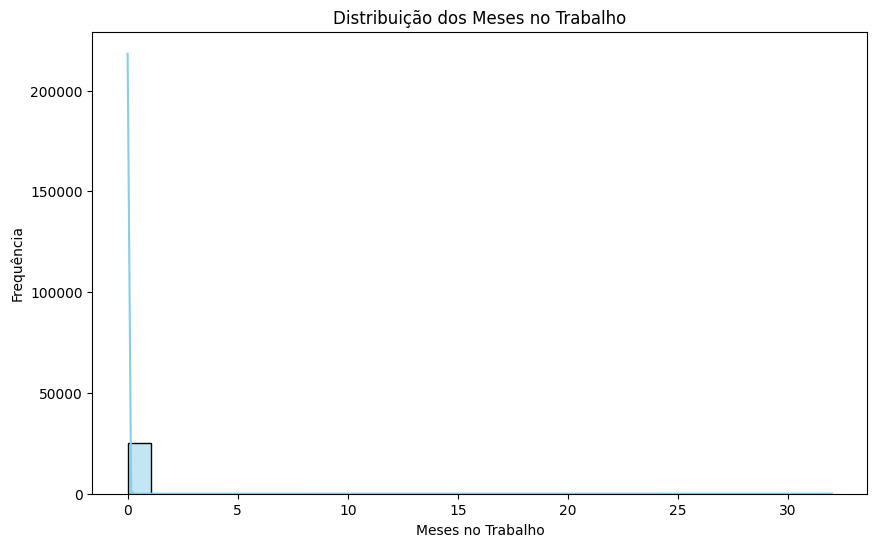

In [33]:
# Verificando a existência da coluna
if 'meses_no_trabalho' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df['meses_no_trabalho'].dropna(), bins=30, kde=True, color='skyblue')
    plt.title('Distribuição dos Meses no Trabalho')
    plt.xlabel('Meses no Trabalho')
    plt.ylabel('Frequência')
    plt.show()
else:
    print("A coluna 'meses_no_trabalho' não foi encontrada no DataFrame.")

In [34]:
# Remove a coluna 'meses_no_trabalho' usando inplace=True
df.drop('meses_no_trabalho', axis=1, inplace=True)
df.head()

,id_solicitante,tipo_endereco,idade,qtde_dependentes,possui_telefone_residencial,meses_na_residencia,possui_email,renda_mensal_regular,renda_extra,possui_cartao_visa,...,estado_onde_reside_SE,estado_onde_reside_SP,estado_onde_reside_TO,tipo_residencia_-1,tipo_residencia_0,tipo_residencia_1,tipo_residencia_2,tipo_residencia_3,tipo_residencia_4,tipo_residencia_5
0,1,1,85,0,1,12.0,0,480.0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
1,2,1,38,0,1,5.0,1,380.0,0.0,0,...,1,0,0,0,0,1,0,0,0,0
2,3,1,37,0,1,1.0,1,600.0,0.0,0,...,0,0,0,0,0,0,0,0,0,1
3,4,1,37,1,1,1.0,1,460.0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
4,5,1,51,3,1,1.0,1,687.0,600.0,0,...,0,0,0,0,1,0,0,0,0,0


In [35]:
# Lista das colunas a serem processadas
colunas_para_processar = ['profissao', 'ocupacao']

# Iterando pelas colunas para realizar as operações desejadas
for coluna in colunas_para_processar:
    if coluna in df.columns:
        # Exibe a quantidade de valores nulos na coluna
        print(f"Quantidade de valores nulos em '{coluna}': {df[coluna].isnull().sum()}")

        # Substitui os valores nulos por -1 e atribui de volta à coluna
        df[coluna] = df[coluna].fillna(-1)

        # Aplica One-Hot Encoding na coluna
        df = pd.get_dummies(df, columns=[coluna], prefix=coluna, dtype=int)

# Exibe o DataFrame atualizado
df.head()

Quantidade de valores nulos em 'profissao': 3859
Quantidade de valores nulos em 'ocupacao': 3668


,id_solicitante,tipo_endereco,idade,qtde_dependentes,possui_telefone_residencial,meses_na_residencia,possui_email,renda_mensal_regular,renda_extra,possui_cartao_visa,...,profissao_16.0,profissao_17.0,profissao_18.0,ocupacao_-1.0,ocupacao_0.0,ocupacao_1.0,ocupacao_2.0,ocupacao_3.0,ocupacao_4.0,ocupacao_5.0
0,1,1,85,0,1,12.0,0,480.0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
1,2,1,38,0,1,5.0,1,380.0,0.0,0,...,0,0,0,0,0,0,0,0,0,1
2,3,1,37,0,1,1.0,1,600.0,0.0,0,...,0,0,0,1,0,0,0,0,0,0
3,4,1,37,1,1,1.0,1,460.0,0.0,0,...,0,0,0,0,0,0,1,0,0,0
4,5,1,51,3,1,1.0,1,687.0,600.0,0,...,0,0,0,0,0,0,0,0,0,1


In [36]:
# Lista das colunas a serem removidas
colunas_para_remover = ['profissao_companheiro', 'grau_instrucao_companheiro', 'local_onde_reside', 'local_onde_trabalha']

# Remove as colunas do DataFrame
df.drop(columns=colunas_para_remover, inplace=True)
df.head()

,id_solicitante,tipo_endereco,idade,qtde_dependentes,possui_telefone_residencial,meses_na_residencia,possui_email,renda_mensal_regular,renda_extra,possui_cartao_visa,...,profissao_16.0,profissao_17.0,profissao_18.0,ocupacao_-1.0,ocupacao_0.0,ocupacao_1.0,ocupacao_2.0,ocupacao_3.0,ocupacao_4.0,ocupacao_5.0
0,1,1,85,0,1,12.0,0,480.0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
1,2,1,38,0,1,5.0,1,380.0,0.0,0,...,0,0,0,0,0,0,0,0,0,1
2,3,1,37,0,1,1.0,1,600.0,0.0,0,...,0,0,0,1,0,0,0,0,0,0
3,4,1,37,1,1,1.0,1,460.0,0.0,0,...,0,0,0,0,0,0,1,0,0,0
4,5,1,51,3,1,1.0,1,687.0,600.0,0,...,0,0,0,0,0,0,0,0,0,1


In [37]:
# Contagem de valores nulos por coluna
valores_nulos = df.isnull().sum()

# Filtra e exibe apenas as colunas com valores nulos
valores_nulos_com_nulos = valores_nulos[valores_nulos > 0]
print("\nQuantidade de valores nulos por coluna (apenas colunas com valores nulos):")
print(valores_nulos_com_nulos)



Quantidade de valores nulos por coluna (apenas colunas com valores nulos):
inadimplente    5000
dtype: int64


## 4. Análise dos Dados

In [38]:
print(list(df.columns))

['id_solicitante', 'tipo_endereco', 'idade', 'qtde_dependentes', 'possui_telefone_residencial', 'meses_na_residencia', 'possui_email', 'renda_mensal_regular', 'renda_extra', 'possui_cartao_visa', 'possui_cartao_mastercard', 'possui_cartao_diners', 'possui_cartao_amex', 'possui_outros_cartoes', 'qtde_contas_bancarias', 'valor_patrimonio_pessoal', 'possui_carro', 'vinculo_formal_com_empresa', 'possui_telefone_trabalho', 'inadimplente', 'produto_solicitado_1', 'produto_solicitado_2', 'produto_solicitado_7', 'dia_vencimento_1', 'dia_vencimento_5', 'dia_vencimento_10', 'dia_vencimento_15', 'dia_vencimento_20', 'dia_vencimento_25', 'forma_envio_solicitacao_correio', 'forma_envio_solicitacao_internet', 'forma_envio_solicitacao_presencial', 'sexo_F', 'sexo_M', 'sexo_N', 'estado_civil_0', 'estado_civil_1', 'estado_civil_2', 'estado_civil_3', 'estado_civil_4', 'estado_civil_5', 'estado_civil_6', 'estado_civil_7', 'nacionalidade_0', 'nacionalidade_1', 'nacionalidade_2', 'estado_onde_nasceu_AC', '

In [39]:
# Filtrando o DataFrame para remover linhas onde 'inadimplente' é NaN
df_filtrado = df[df['inadimplente'].notna()]
print(len(df_filtrado))

20000


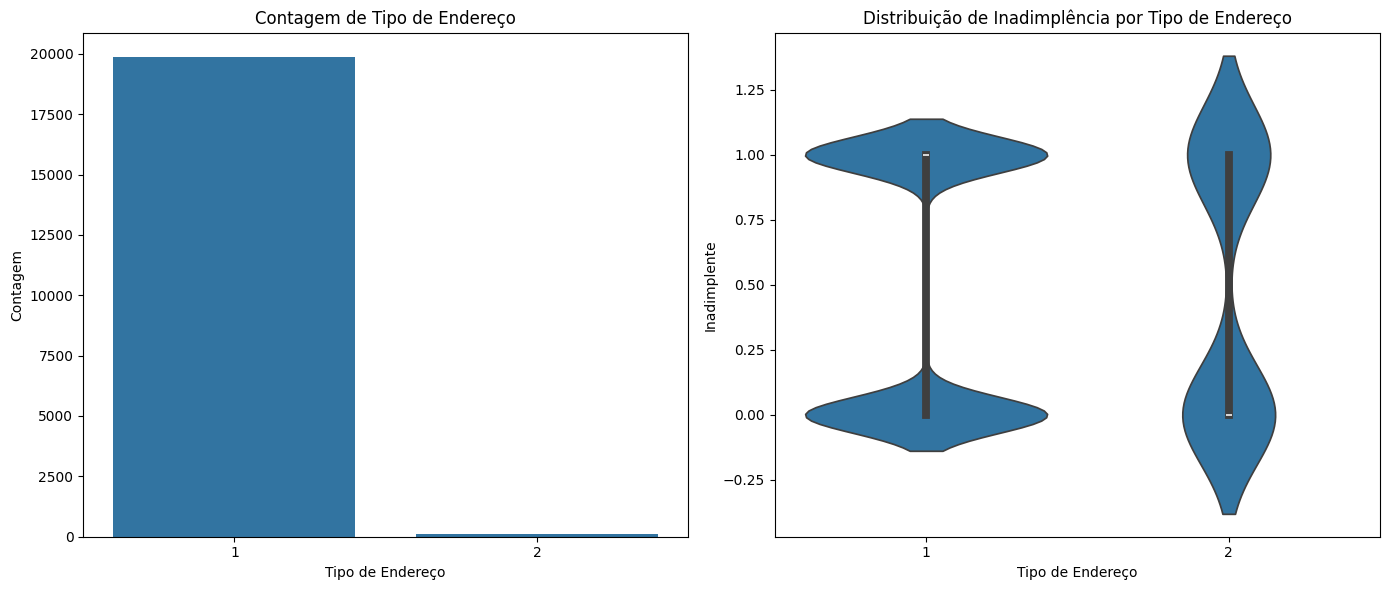

In [40]:
# Criando a figura e os eixos
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de Contagem
sns.countplot(data=df_filtrado, x='tipo_endereco', ax=axs[0])
axs[0].set_title('Contagem de Tipo de Endereço')
axs[0].set_xlabel('Tipo de Endereço')
axs[0].set_ylabel('Contagem')

# Violin Plot
sns.violinplot(data=df_filtrado, x='tipo_endereco', y='inadimplente', ax=axs[1])
axs[1].set_title('Distribuição de Inadimplência por Tipo de Endereço')
axs[1].set_xlabel('Tipo de Endereço')
axs[1].set_ylabel('Inadimplente')

plt.tight_layout()
plt.show()

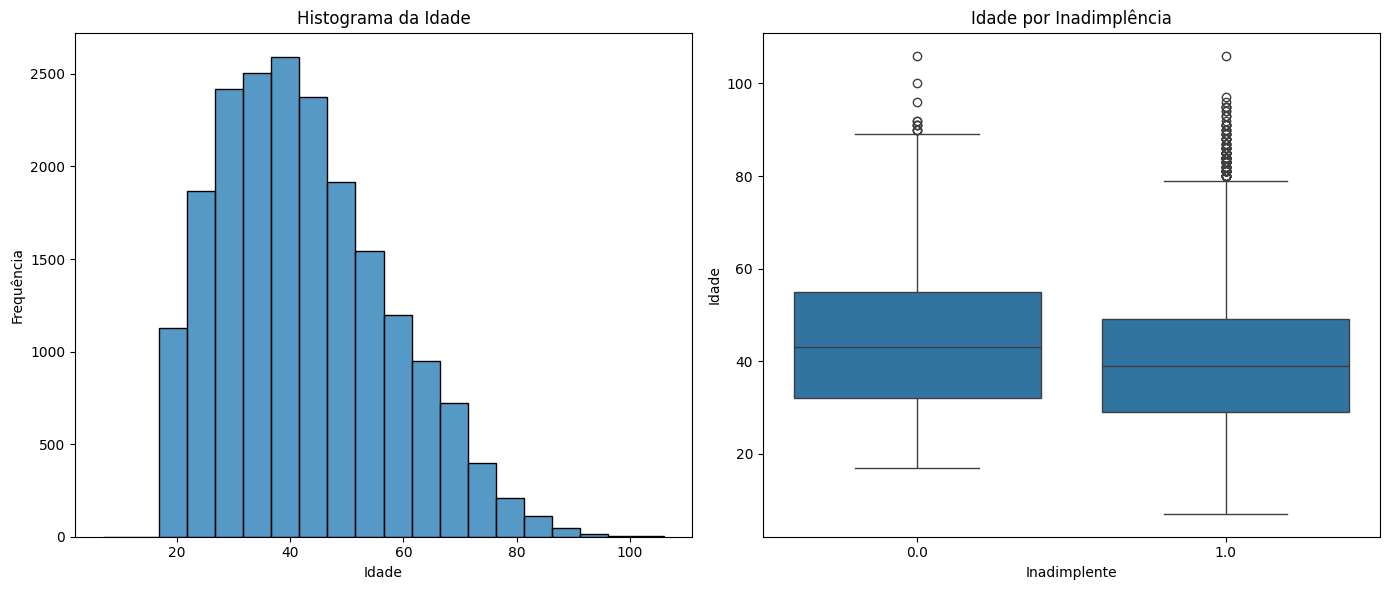

In [41]:
# Criando a figura e os eixos
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Histograma
sns.histplot(df_filtrado['idade'], bins=20, kde=False, ax=axs[0])
axs[0].set_title('Histograma da Idade')
axs[0].set_xlabel('Idade')
axs[0].set_ylabel('Frequência')

# Boxplot
sns.boxplot(data=df_filtrado, x='inadimplente', y='idade', ax=axs[1])
axs[1].set_title('Idade por Inadimplência')
axs[1].set_xlabel('Inadimplente')
axs[1].set_ylabel('Idade')

plt.tight_layout()
plt.show()

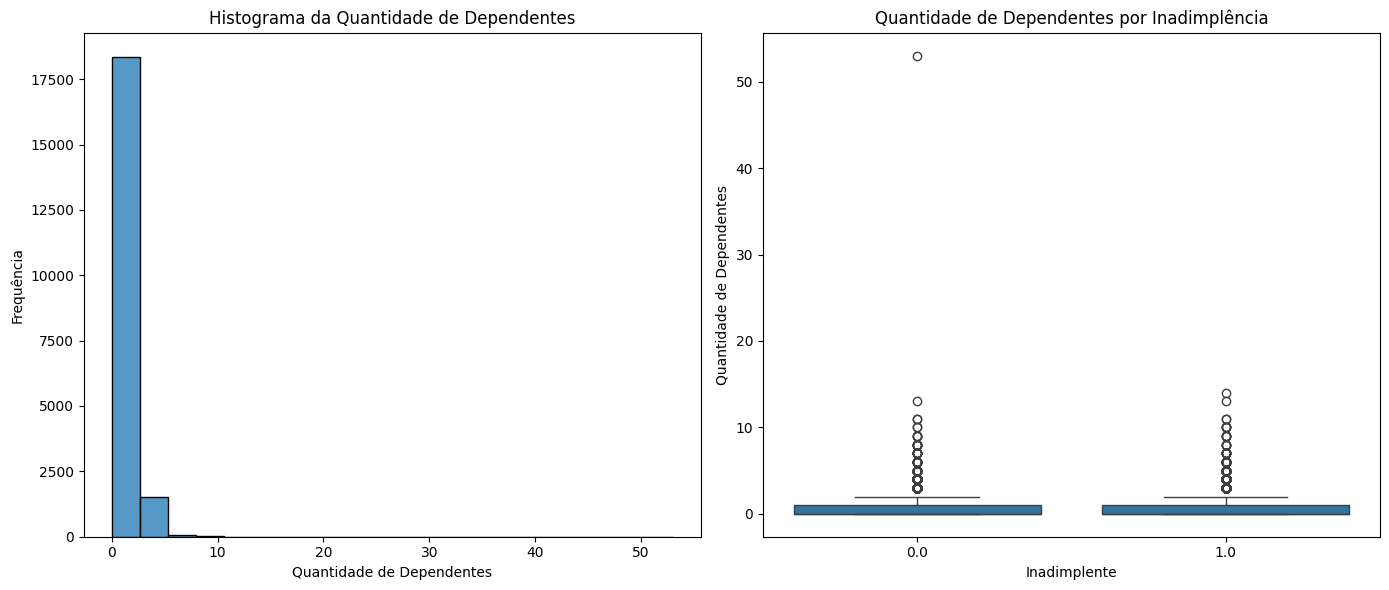

In [42]:
# Criando a figura e os eixos
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Histograma
sns.histplot(df_filtrado['qtde_dependentes'], bins=20, kde=False, ax=axs[0])
axs[0].set_title('Histograma da Quantidade de Dependentes')
axs[0].set_xlabel('Quantidade de Dependentes')
axs[0].set_ylabel('Frequência')

# Boxplot
sns.boxplot(data=df_filtrado, x='inadimplente', y='qtde_dependentes', ax=axs[1])
axs[1].set_title('Quantidade de Dependentes por Inadimplência')
axs[1].set_xlabel('Inadimplente')
axs[1].set_ylabel('Quantidade de Dependentes')

plt.tight_layout()
plt.show()

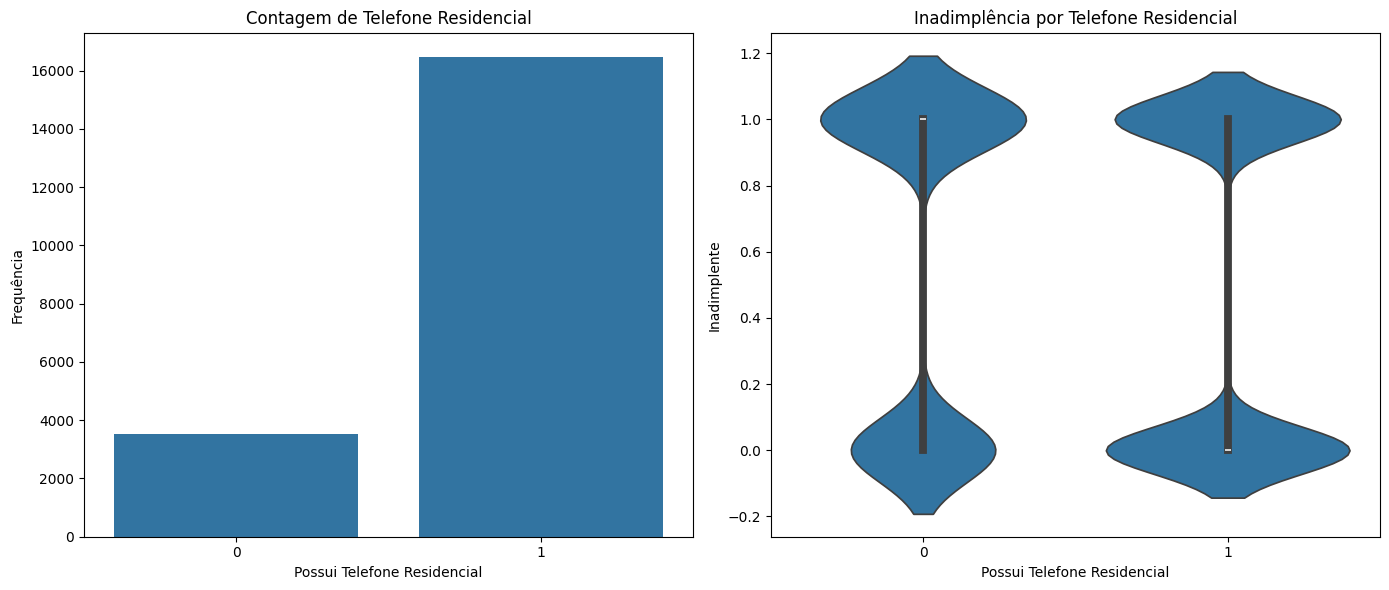

In [43]:
# Criando a figura e os eixos
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Countplot
sns.countplot(data=df_filtrado, x='possui_telefone_residencial', ax=axs[0])
axs[0].set_title('Contagem de Telefone Residencial')
axs[0].set_xlabel('Possui Telefone Residencial')
axs[0].set_ylabel('Frequência')

# Violinplot
sns.violinplot(data=df_filtrado, x='possui_telefone_residencial', y='inadimplente', ax=axs[1])
axs[1].set_title('Inadimplência por Telefone Residencial')
axs[1].set_xlabel('Possui Telefone Residencial')
axs[1].set_ylabel('Inadimplente')

plt.tight_layout()
plt.show()

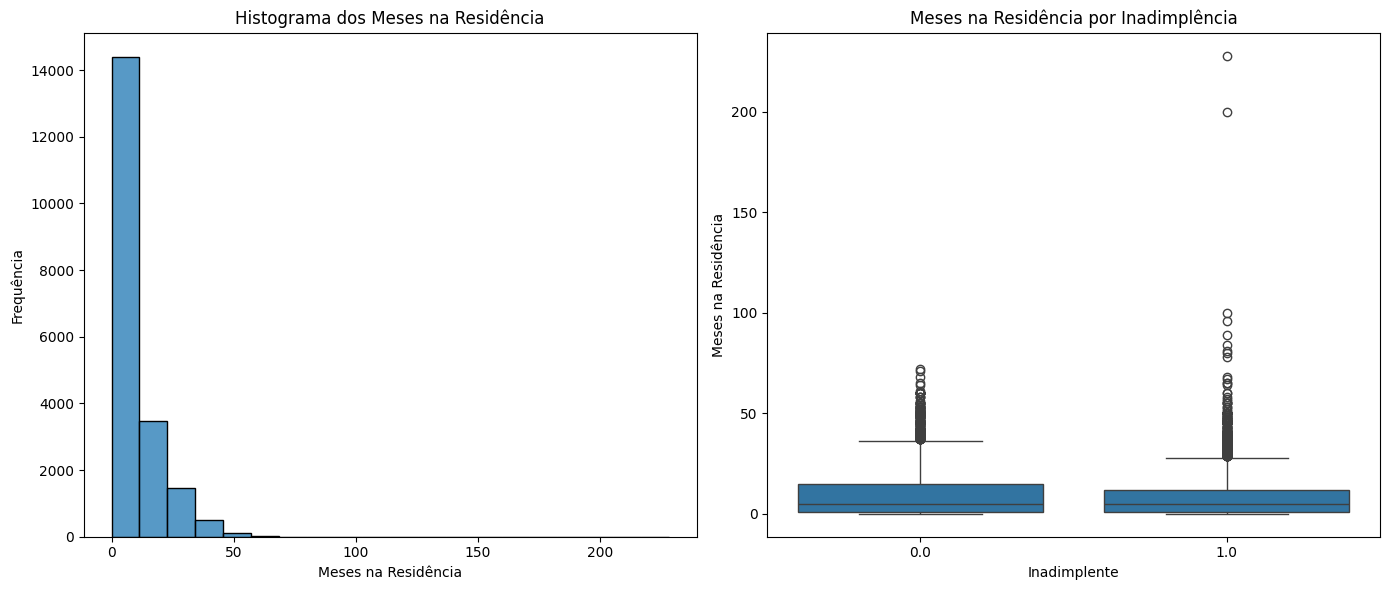

In [44]:
# Criando a figura e os eixos
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Histograma
sns.histplot(df_filtrado['meses_na_residencia'], bins=20, kde=False, ax=axs[0])
axs[0].set_title('Histograma dos Meses na Residência')
axs[0].set_xlabel('Meses na Residência')
axs[0].set_ylabel('Frequência')

# Boxplot
sns.boxplot(data=df_filtrado, x='inadimplente', y='meses_na_residencia', ax=axs[1])
axs[1].set_title('Meses na Residência por Inadimplência')
axs[1].set_xlabel('Inadimplente')
axs[1].set_ylabel('Meses na Residência')

plt.tight_layout()
plt.show()

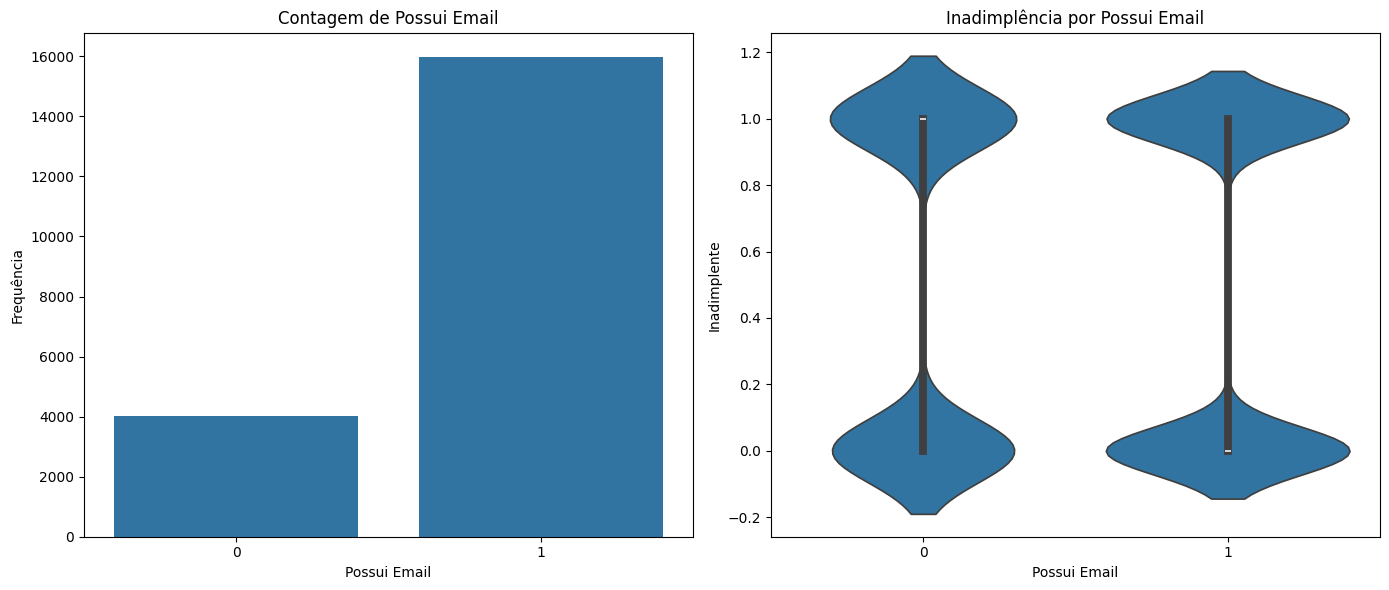

In [45]:
# Criando a figura e os eixos
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Countplot
sns.countplot(data=df_filtrado, x='possui_email', ax=axs[0])
axs[0].set_title('Contagem de Possui Email')
axs[0].set_xlabel('Possui Email')
axs[0].set_ylabel('Frequência')

# Violinplot
sns.violinplot(data=df_filtrado, x='possui_email', y='inadimplente', ax=axs[1])
axs[1].set_title('Inadimplência por Possui Email')
axs[1].set_xlabel('Possui Email')
axs[1].set_ylabel('Inadimplente')

plt.tight_layout()
plt.show()

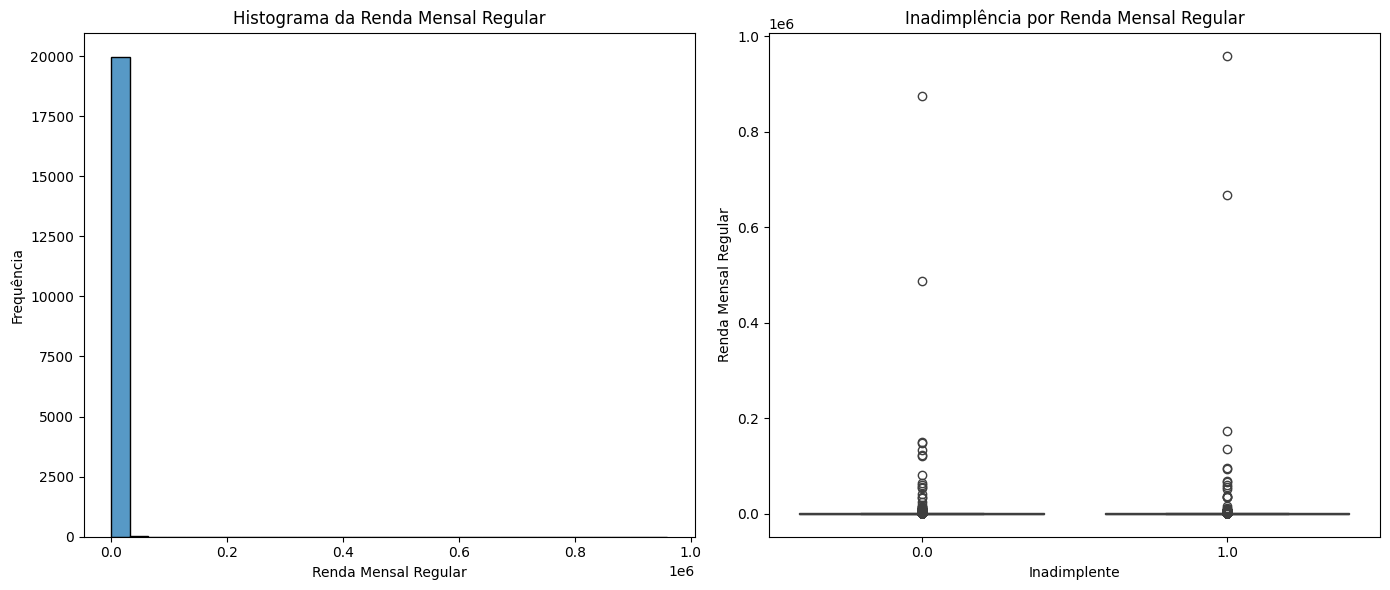

In [46]:
# Criando a figura e os eixos
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Histograma sem KDE
sns.histplot(df_filtrado['renda_mensal_regular'], bins=30, ax=axs[0])
axs[0].set_title('Histograma da Renda Mensal Regular')
axs[0].set_xlabel('Renda Mensal Regular')
axs[0].set_ylabel('Frequência')

# Boxplot para visualização da renda mensal e inadimplência
sns.boxplot(data=df_filtrado, x='inadimplente', y='renda_mensal_regular', ax=axs[1])
axs[1].set_title('Inadimplência por Renda Mensal Regular')
axs[1].set_xlabel('Inadimplente')
axs[1].set_ylabel('Renda Mensal Regular')

plt.tight_layout()
plt.show()

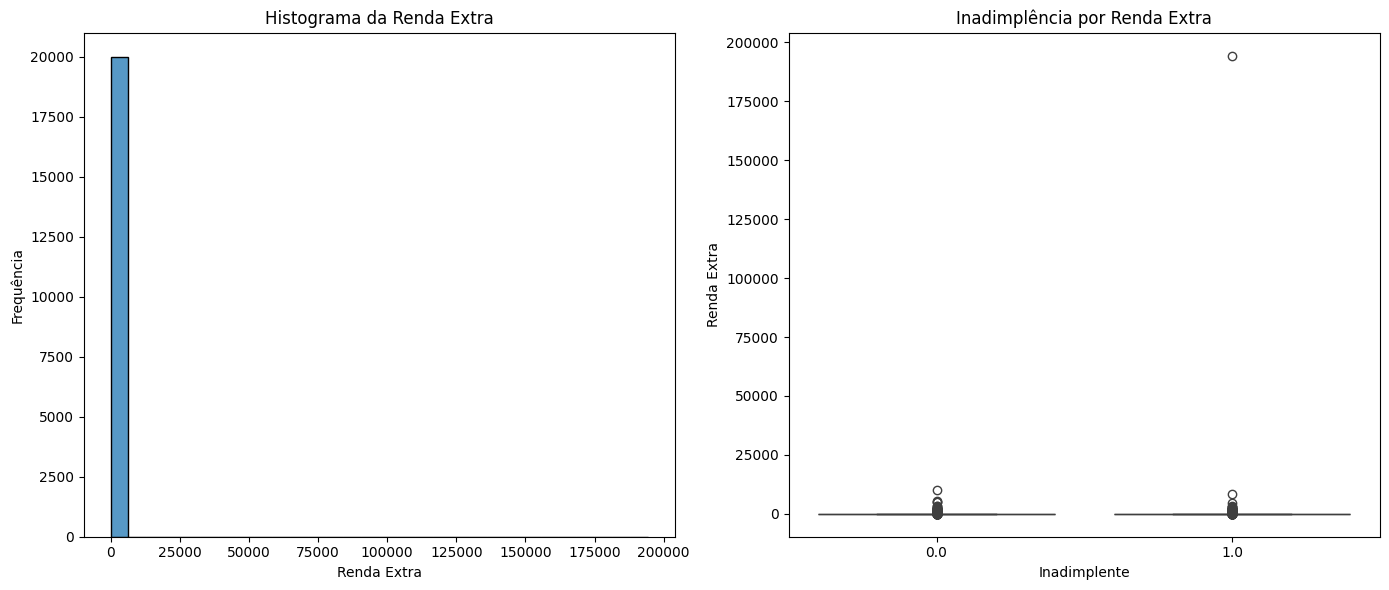

In [47]:
# Criando a figura e os eixos
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Histograma da renda extra
sns.histplot(df_filtrado['renda_extra'], bins=30, ax=axs[0])
axs[0].set_title('Histograma da Renda Extra')
axs[0].set_xlabel('Renda Extra')
axs[0].set_ylabel('Frequência')

# Boxplot para visualização da renda extra e inadimplência
sns.boxplot(data=df_filtrado, x='inadimplente', y='renda_extra', ax=axs[1])
axs[1].set_title('Inadimplência por Renda Extra')
axs[1].set_xlabel('Inadimplente')
axs[1].set_ylabel('Renda Extra')

plt.tight_layout()
plt.show()

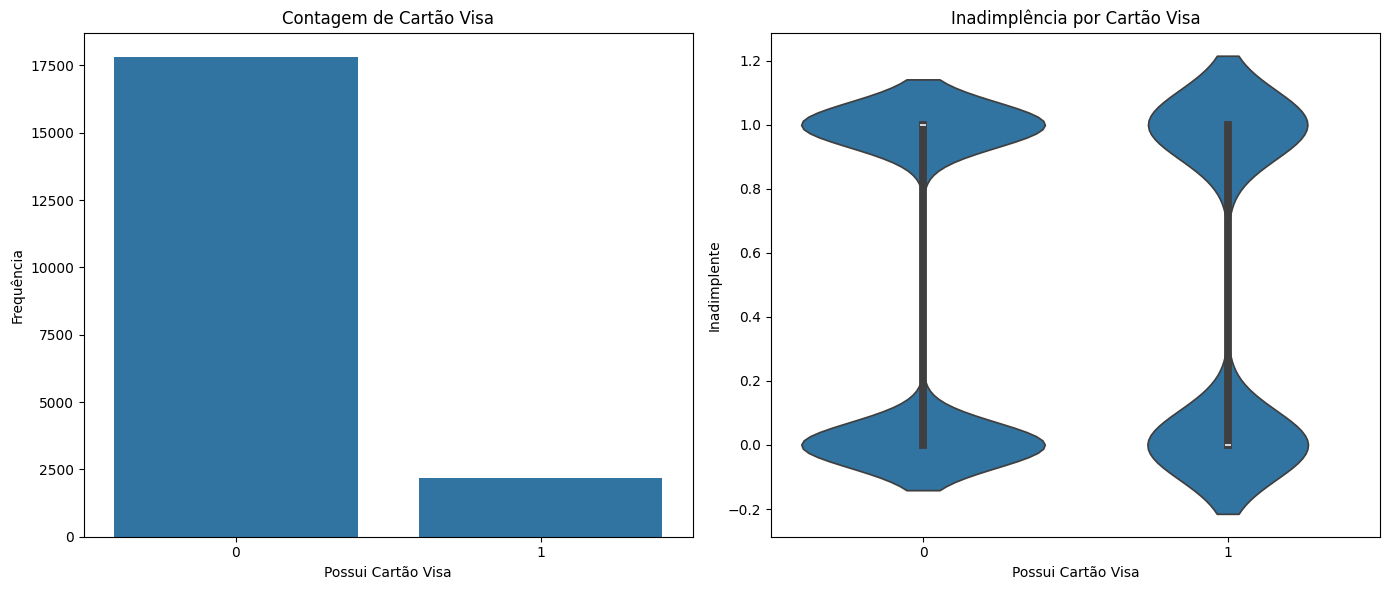

In [48]:
# Criando a figura e os eixos
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Countplot para 'possui_cartao_visa'
sns.countplot(data=df_filtrado, x='possui_cartao_visa', ax=axs[0])
axs[0].set_title('Contagem de Cartão Visa')
axs[0].set_xlabel('Possui Cartão Visa')
axs[0].set_ylabel('Frequência')

# Violinplot para 'possui_cartao_visa' e 'inadimplente'
sns.violinplot(data=df_filtrado, x='possui_cartao_visa', y='inadimplente', ax=axs[1])
axs[1].set_title('Inadimplência por Cartão Visa')
axs[1].set_xlabel('Possui Cartão Visa')
axs[1].set_ylabel('Inadimplente')

plt.tight_layout()
plt.show()

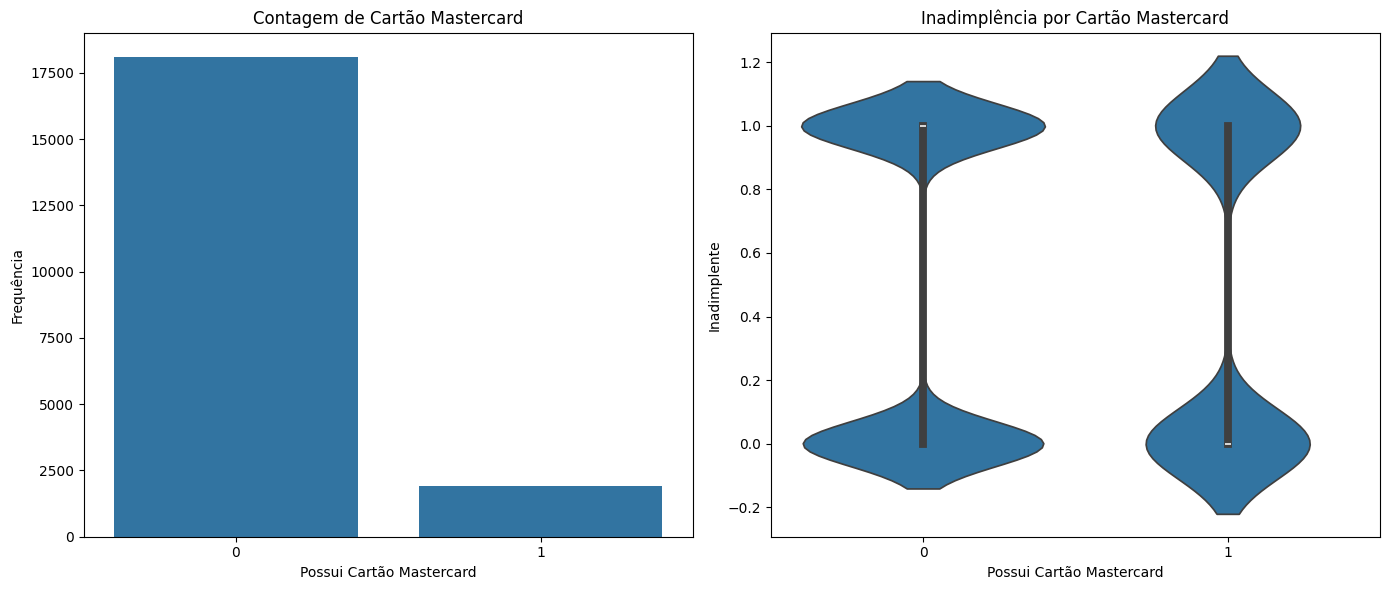

In [49]:
# Criando a figura e os eixos para Cartão Mastercard
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Countplot
sns.countplot(data=df_filtrado, x='possui_cartao_mastercard', ax=axs[0])
axs[0].set_title('Contagem de Cartão Mastercard')
axs[0].set_xlabel('Possui Cartão Mastercard')
axs[0].set_ylabel('Frequência')

# Violinplot
sns.violinplot(data=df_filtrado, x='possui_cartao_mastercard', y='inadimplente', ax=axs[1])
axs[1].set_title('Inadimplência por Cartão Mastercard')
axs[1].set_xlabel('Possui Cartão Mastercard')
axs[1].set_ylabel('Inadimplente')

plt.tight_layout()
plt.show()

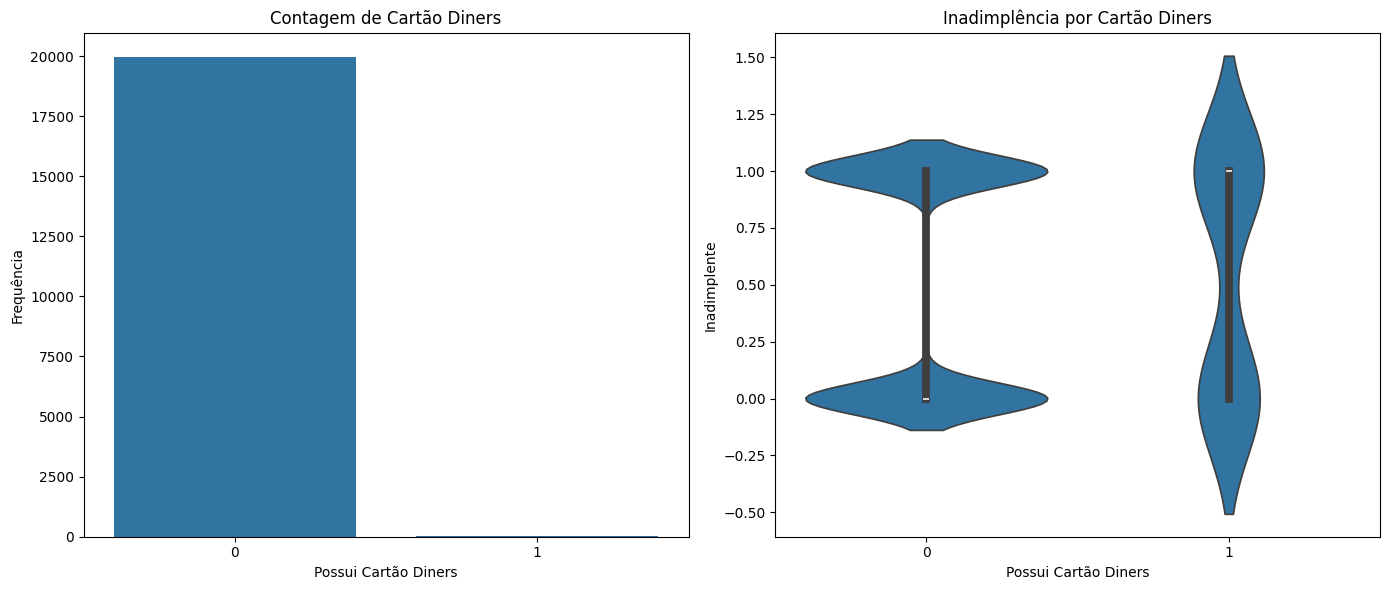

In [50]:
# Criando a figura e os eixos para Cartão Diners
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Countplot
sns.countplot(data=df_filtrado, x='possui_cartao_diners', ax=axs[0])
axs[0].set_title('Contagem de Cartão Diners')
axs[0].set_xlabel('Possui Cartão Diners')
axs[0].set_ylabel('Frequência')

# Violinplot
sns.violinplot(data=df_filtrado, x='possui_cartao_diners', y='inadimplente', ax=axs[1])
axs[1].set_title('Inadimplência por Cartão Diners')
axs[1].set_xlabel('Possui Cartão Diners')
axs[1].set_ylabel('Inadimplente')

plt.tight_layout()
plt.show()

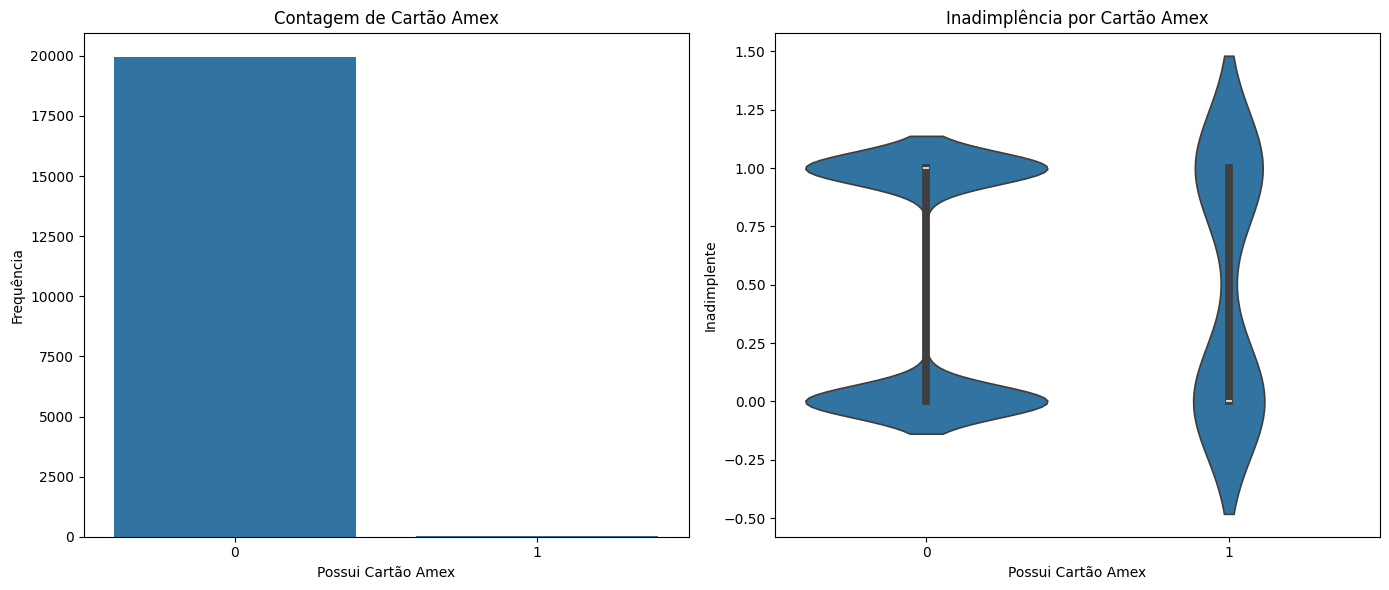

In [51]:
# Criando a figura e os eixos para Cartão Amex
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Countplot
sns.countplot(data=df_filtrado, x='possui_cartao_amex', ax=axs[0])
axs[0].set_title('Contagem de Cartão Amex')
axs[0].set_xlabel('Possui Cartão Amex')
axs[0].set_ylabel('Frequência')

# Violinplot
sns.violinplot(data=df_filtrado, x='possui_cartao_amex', y='inadimplente', ax=axs[1])
axs[1].set_title('Inadimplência por Cartão Amex')
axs[1].set_xlabel('Possui Cartão Amex')
axs[1].set_ylabel('Inadimplente')

plt.tight_layout()
plt.show()

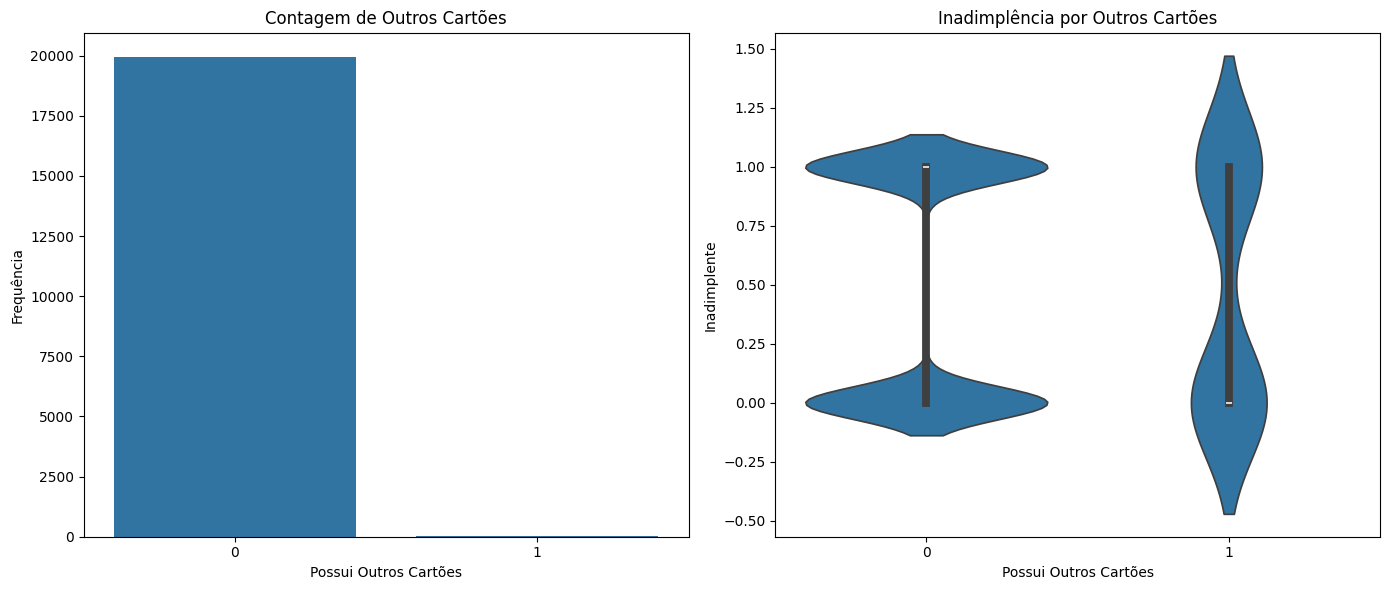

In [52]:
# Criando a figura e os eixos para Outros Cartões
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Countplot
sns.countplot(data=df_filtrado, x='possui_outros_cartoes', ax=axs[0])
axs[0].set_title('Contagem de Outros Cartões')
axs[0].set_xlabel('Possui Outros Cartões')
axs[0].set_ylabel('Frequência')

# Violinplot
sns.violinplot(data=df_filtrado, x='possui_outros_cartoes', y='inadimplente', ax=axs[1])
axs[1].set_title('Inadimplência por Outros Cartões')
axs[1].set_xlabel('Possui Outros Cartões')
axs[1].set_ylabel('Inadimplente')

plt.tight_layout()
plt.show()

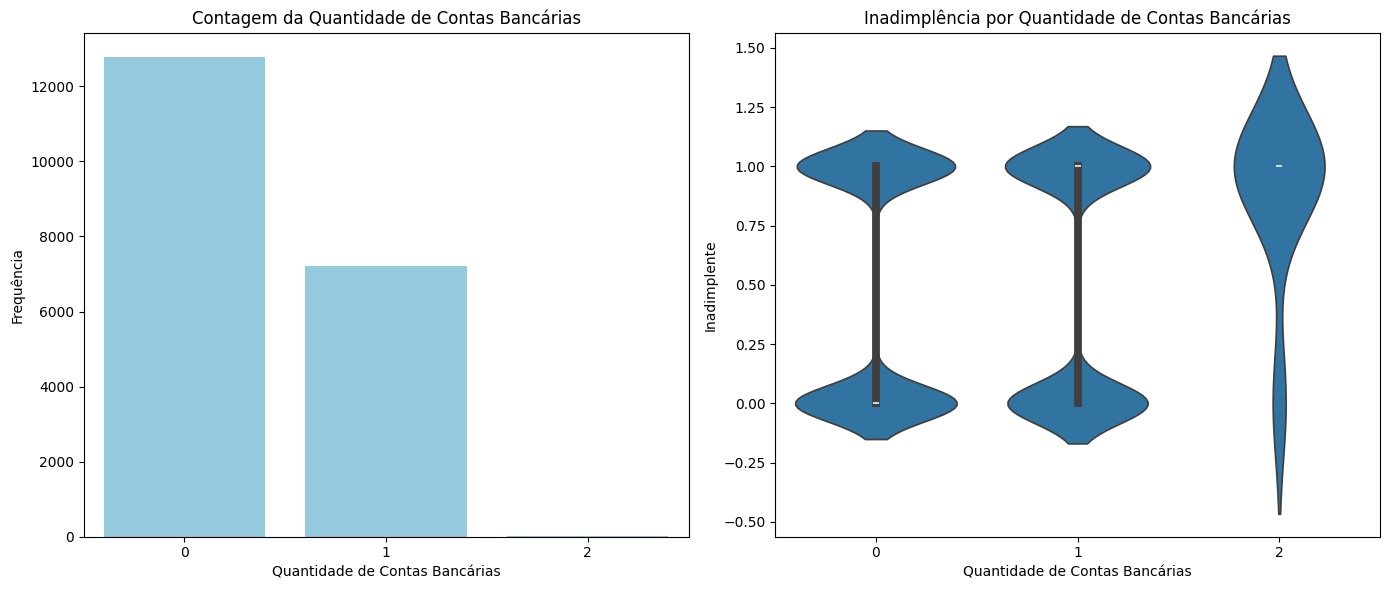

In [53]:
# Criando a figura e os eixos
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Countplot para a quantidade de contas bancárias
sns.countplot(data=df_filtrado, x='qtde_contas_bancarias', ax=axs[0], color='skyblue')
axs[0].set_title('Contagem da Quantidade de Contas Bancárias')
axs[0].set_xlabel('Quantidade de Contas Bancárias')
axs[0].set_ylabel('Frequência')

# Violinplot para a quantidade de contas bancárias em relação à inadimplência
sns.violinplot(data=df_filtrado, x='qtde_contas_bancarias', y='inadimplente', ax=axs[1])
axs[1].set_title('Inadimplência por Quantidade de Contas Bancárias')
axs[1].set_xlabel('Quantidade de Contas Bancárias')
axs[1].set_ylabel('Inadimplente')

plt.tight_layout()
plt.show()

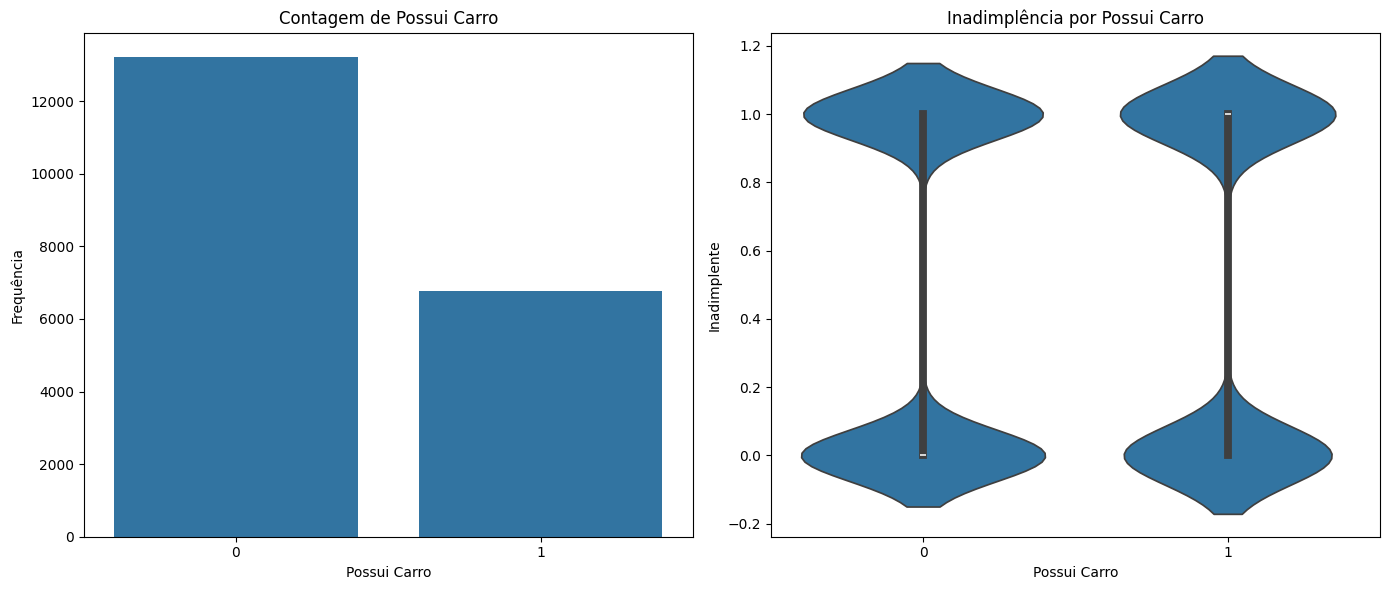

In [54]:
# Para possui_carro
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Countplot para possui_carro
sns.countplot(data=df_filtrado, x='possui_carro', ax=axs[0])
axs[0].set_title('Contagem de Possui Carro')
axs[0].set_xlabel('Possui Carro')
axs[0].set_ylabel('Frequência')

# Violinplot para possui_carro e inadimplência
sns.violinplot(data=df_filtrado, x='possui_carro', y='inadimplente', ax=axs[1])
axs[1].set_title('Inadimplência por Possui Carro')
axs[1].set_xlabel('Possui Carro')
axs[1].set_ylabel('Inadimplente')

plt.tight_layout()
plt.show()

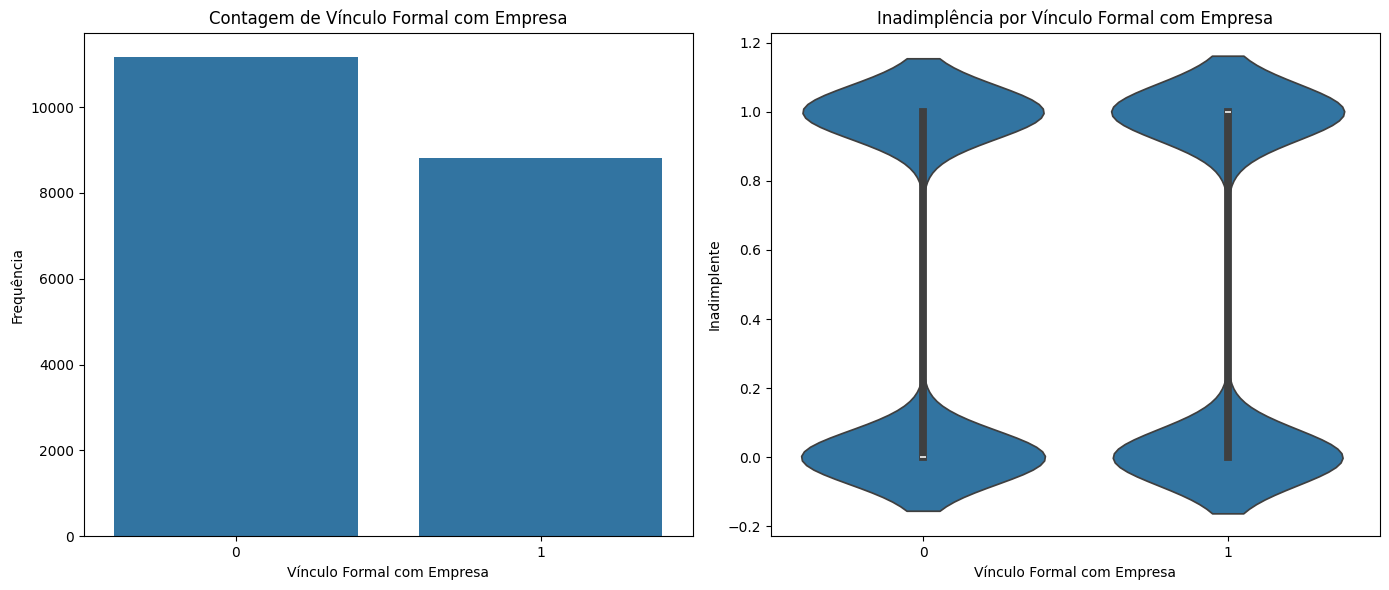

In [55]:
# Para vinculo_formal_com_empresa
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Countplot para vinculo_formal_com_empresa
sns.countplot(data=df_filtrado, x='vinculo_formal_com_empresa', ax=axs[0])
axs[0].set_title('Contagem de Vínculo Formal com Empresa')
axs[0].set_xlabel('Vínculo Formal com Empresa')
axs[0].set_ylabel('Frequência')

# Violinplot para vinculo_formal_com_empresa e inadimplência
sns.violinplot(data=df_filtrado, x='vinculo_formal_com_empresa', y='inadimplente', ax=axs[1])
axs[1].set_title('Inadimplência por Vínculo Formal com Empresa')
axs[1].set_xlabel('Vínculo Formal com Empresa')
axs[1].set_ylabel('Inadimplente')

plt.tight_layout()
plt.show()

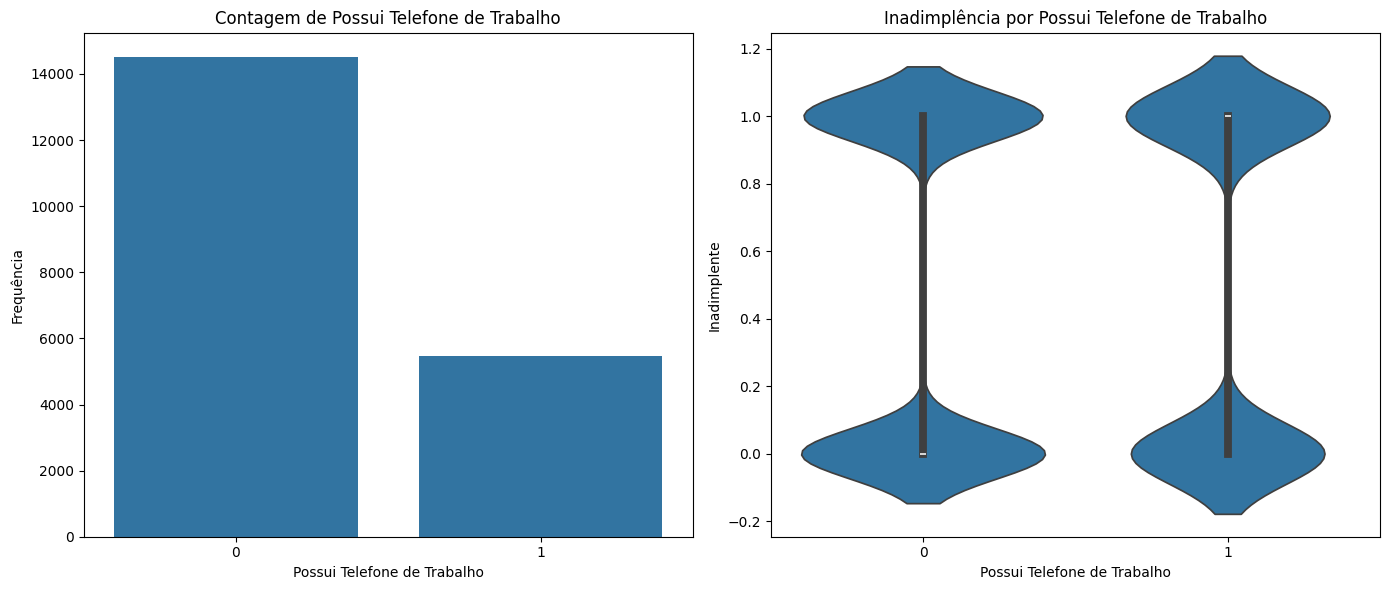

In [56]:
# Para possui_telefone_trabalho
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Countplot para possui_telefone_trabalho
sns.countplot(data=df_filtrado, x='possui_telefone_trabalho', ax=axs[0])
axs[0].set_title('Contagem de Possui Telefone de Trabalho')
axs[0].set_xlabel('Possui Telefone de Trabalho')
axs[0].set_ylabel('Frequência')

# Violinplot para possui_telefone_trabalho e inadimplência
sns.violinplot(data=df_filtrado, x='possui_telefone_trabalho', y='inadimplente', ax=axs[1])
axs[1].set_title('Inadimplência por Possui Telefone de Trabalho')
axs[1].set_xlabel('Possui Telefone de Trabalho')
axs[1].set_ylabel('Inadimplente')

plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_16272\3845288654.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado.loc[:, 'produto_solicitado'] = df_filtrado[['produto_solicitado_1', 'produto_solicitado_2', 'produto_solicitado_7']].idxmax(axis=1)


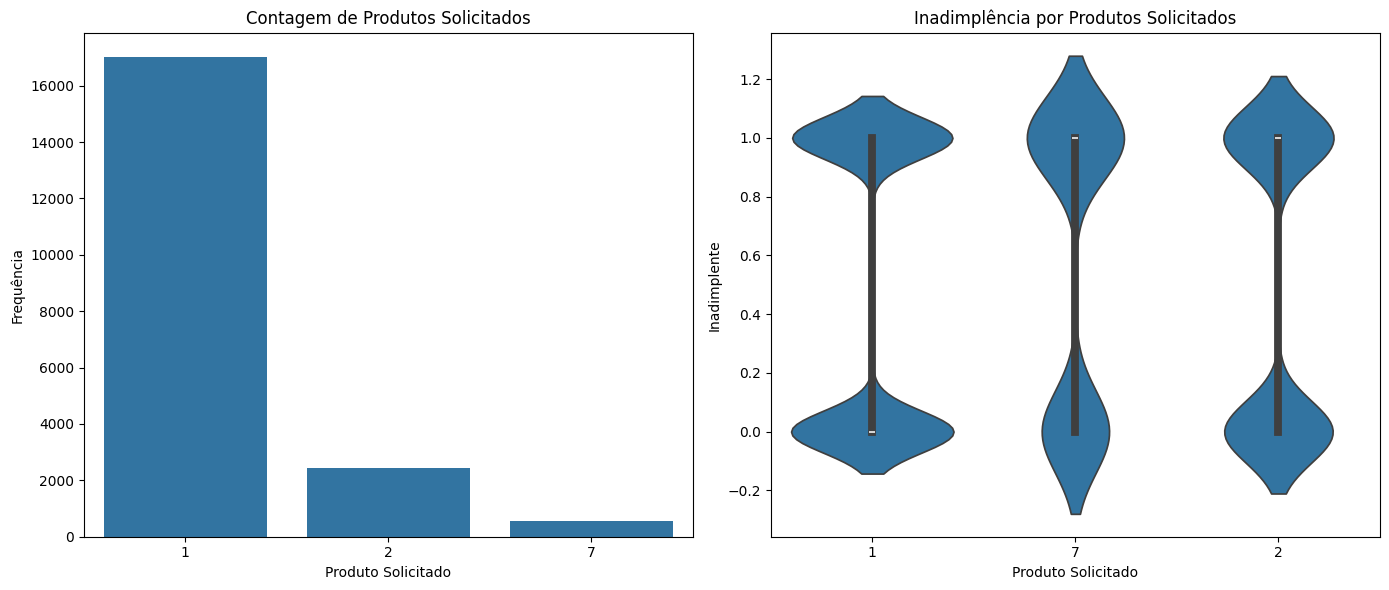

In [57]:
# Criando uma nova coluna para produtos solicitados
df_filtrado.loc[:, 'produto_solicitado'] = df_filtrado[['produto_solicitado_1', 'produto_solicitado_2', 'produto_solicitado_7']].idxmax(axis=1)

# Mapeando os nomes das colunas para os produtos
df_filtrado.loc[:, 'produto_solicitado'] = df_filtrado['produto_solicitado'].str.extract(r'(\d+)')[0]  # Extrai o número da string

# Criando a figura e os eixos
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Countplot para produtos solicitados
sns.countplot(data=df_filtrado, x='produto_solicitado', ax=axs[0], order=df_filtrado['produto_solicitado'].value_counts().index)
axs[0].set_title('Contagem de Produtos Solicitados')
axs[0].set_xlabel('Produto Solicitado')
axs[0].set_ylabel('Frequência')

# Violinplot para produtos solicitados e inadimplência
sns.violinplot(data=df_filtrado, x='produto_solicitado', y='inadimplente', ax=axs[1])
axs[1].set_title('Inadimplência por Produtos Solicitados')
axs[1].set_xlabel('Produto Solicitado')
axs[1].set_ylabel('Inadimplente')

plt.tight_layout()
plt.show()



C:\Users\Lucas\AppData\Local\Temp\ipykernel_16272\1418520423.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado.loc[:, 'dia_vencimento'] = df_filtrado[['dia_vencimento_1', 'dia_vencimento_5', 'dia_vencimento_10',
C:\Users\Lucas\AppData\Local\Temp\ipykernel_16272\1418520423.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['dia_vencimento'] = pd.to_numeric(df_filtrado['dia_vencimento'], errors='coerce')


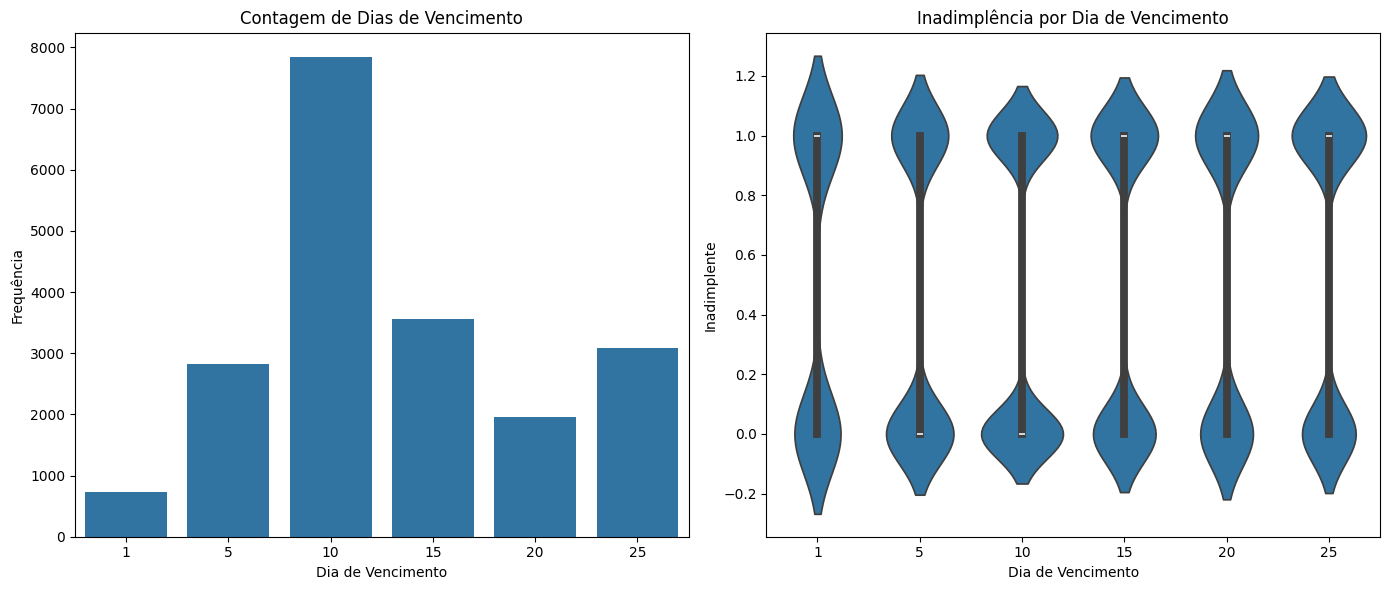

In [58]:
# Criando uma nova coluna para o dia de vencimento
df_filtrado.loc[:, 'dia_vencimento'] = df_filtrado[['dia_vencimento_1', 'dia_vencimento_5', 'dia_vencimento_10', 
                                                      'dia_vencimento_15', 'dia_vencimento_20', 'dia_vencimento_25']].idxmax(axis=1)

# Extraindo o dia do vencimento
df_filtrado.loc[:, 'dia_vencimento'] = df_filtrado['dia_vencimento'].str.extract(r'(\d+)')[0]  # Extrai o número da string

# Convertendo a coluna 'dia_vencimento' para numérico para ordenação
df_filtrado['dia_vencimento'] = pd.to_numeric(df_filtrado['dia_vencimento'], errors='coerce')

# Criando a figura e os eixos
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Countplot para dias de vencimento
sns.countplot(data=df_filtrado, x='dia_vencimento', ax=axs[0], order=sorted(df_filtrado['dia_vencimento'].dropna().unique()))
axs[0].set_title('Contagem de Dias de Vencimento')
axs[0].set_xlabel('Dia de Vencimento')
axs[0].set_ylabel('Frequência')

# Violinplot para dias de vencimento e inadimplência
sns.violinplot(data=df_filtrado, x='dia_vencimento', y='inadimplente', ax=axs[1])
axs[1].set_title('Inadimplência por Dia de Vencimento')
axs[1].set_xlabel('Dia de Vencimento')
axs[1].set_ylabel('Inadimplente')

plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_16272\4157517211.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado.loc[:, 'forma_envio_solicitacao'] = df_filtrado[['forma_envio_solicitacao_correio',


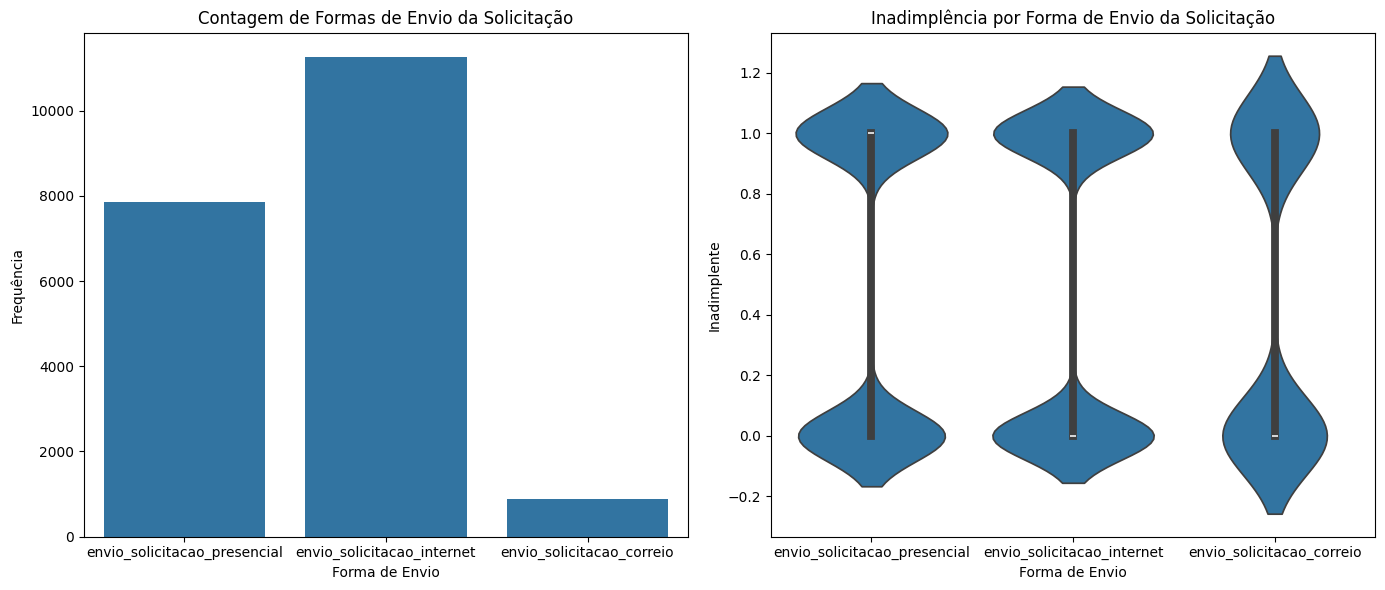

In [59]:
# Criando uma nova coluna para a forma de envio da solicitação
df_filtrado.loc[:, 'forma_envio_solicitacao'] = df_filtrado[['forma_envio_solicitacao_correio', 
                                                               'forma_envio_solicitacao_internet', 
                                                               'forma_envio_solicitacao_presencial']].idxmax(axis=1)

# Extraindo o tipo de envio da string
df_filtrado.loc[:, 'forma_envio_solicitacao'] = df_filtrado['forma_envio_solicitacao'].str.extract(r'_(.+)')[0]  # Extrai o tipo de envio

# Criando a figura e os eixos
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Countplot para formas de envio
sns.countplot(data=df_filtrado, x='forma_envio_solicitacao', ax=axs[0])
axs[0].set_title('Contagem de Formas de Envio da Solicitação')
axs[0].set_xlabel('Forma de Envio')
axs[0].set_ylabel('Frequência')

# Violinplot para formas de envio e inadimplência
sns.violinplot(data=df_filtrado, x='forma_envio_solicitacao', y='inadimplente', ax=axs[1])
axs[1].set_title('Inadimplência por Forma de Envio da Solicitação')
axs[1].set_xlabel('Forma de Envio')
axs[1].set_ylabel('Inadimplente')

plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_16272\3245117069.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado.loc[:, 'sexo'] = df_filtrado[['sexo_F', 'sexo_M', 'sexo_N']].idxmax(axis=1)


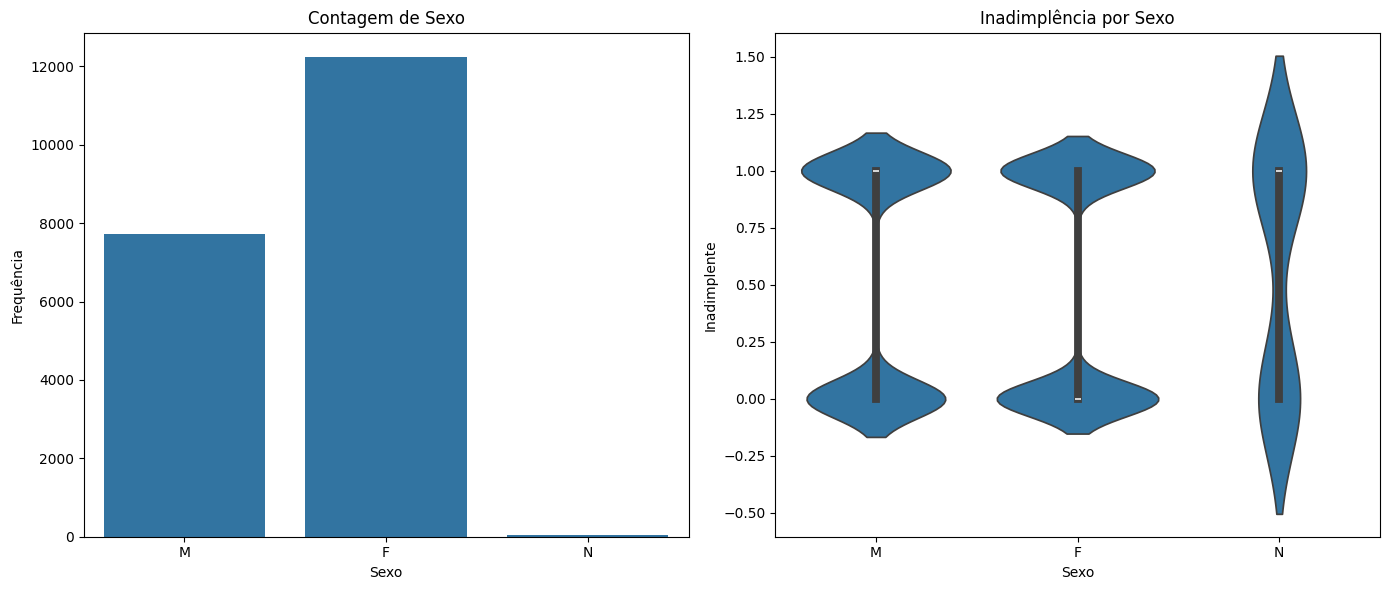

In [60]:
# Criando uma nova coluna para o sexo
df_filtrado.loc[:, 'sexo'] = df_filtrado[['sexo_F', 'sexo_M', 'sexo_N']].idxmax(axis=1)

# Extraindo o tipo de sexo da string
df_filtrado.loc[:, 'sexo'] = df_filtrado['sexo'].str.extract(r'_(.+)')[0]  # Extrai o tipo de sexo

# Criando a figura e os eixos
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Countplot para sexos
sns.countplot(data=df_filtrado, x='sexo', ax=axs[0])
axs[0].set_title('Contagem de Sexo')
axs[0].set_xlabel('Sexo')
axs[0].set_ylabel('Frequência')

# Violinplot para sexo e inadimplência
sns.violinplot(data=df_filtrado, x='sexo', y='inadimplente', ax=axs[1])
axs[1].set_title('Inadimplência por Sexo')
axs[1].set_xlabel('Sexo')
axs[1].set_ylabel('Inadimplente')

plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_16272\895815523.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['estado_civil'] = df_filtrado[['estado_civil_0', 'estado_civil_1', 'estado_civil_2',
C:\Users\Lucas\AppData\Local\Temp\ipykernel_16272\895815523.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['estado_civil'] = df_filtrado['estado_civil'].str.extract(r'_(\d+)')[0]  # Extrai apenas o número


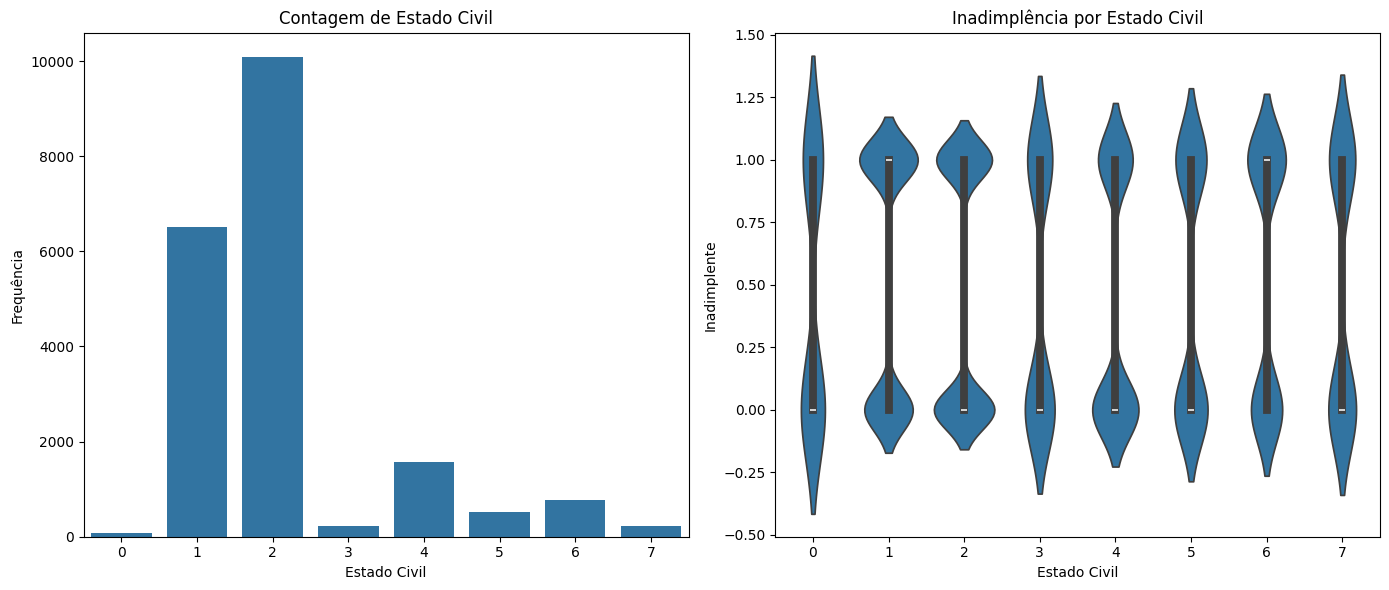

In [61]:
# Criando uma nova coluna para o estado civil
df_filtrado['estado_civil'] = df_filtrado[['estado_civil_0', 'estado_civil_1', 'estado_civil_2', 
                                            'estado_civil_3', 'estado_civil_4', 'estado_civil_5', 
                                            'estado_civil_6', 'estado_civil_7']].idxmax(axis=1)

# Extraindo o número do estado civil
df_filtrado['estado_civil'] = df_filtrado['estado_civil'].str.extract(r'_(\d+)')[0]  # Extrai apenas o número

# Criando a figura e os eixos
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Countplot para estado civil, ordenando
sns.countplot(data=df_filtrado, x='estado_civil', ax=axs[0], order=sorted(df_filtrado['estado_civil'].dropna().unique(), key=int))
axs[0].set_title('Contagem de Estado Civil')
axs[0].set_xlabel('Estado Civil')
axs[0].set_ylabel('Frequência')

# Violinplot para estado civil e inadimplência, ordenando
sns.violinplot(data=df_filtrado, x='estado_civil', y='inadimplente', ax=axs[1], order=sorted(df_filtrado['estado_civil'].dropna().unique(), key=int))
axs[1].set_title('Inadimplência por Estado Civil')
axs[1].set_xlabel('Estado Civil')
axs[1].set_ylabel('Inadimplente')

plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_16272\2268830875.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['nacionalidade'] = df_filtrado[['nacionalidade_0', 'nacionalidade_1', 'nacionalidade_2']].idxmax(axis=1)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_16272\2268830875.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['nacionalidade'] = df_filtrado['nacionalidade'].str.extract(r'_(\d+)')[0]  # Extrai apenas o número


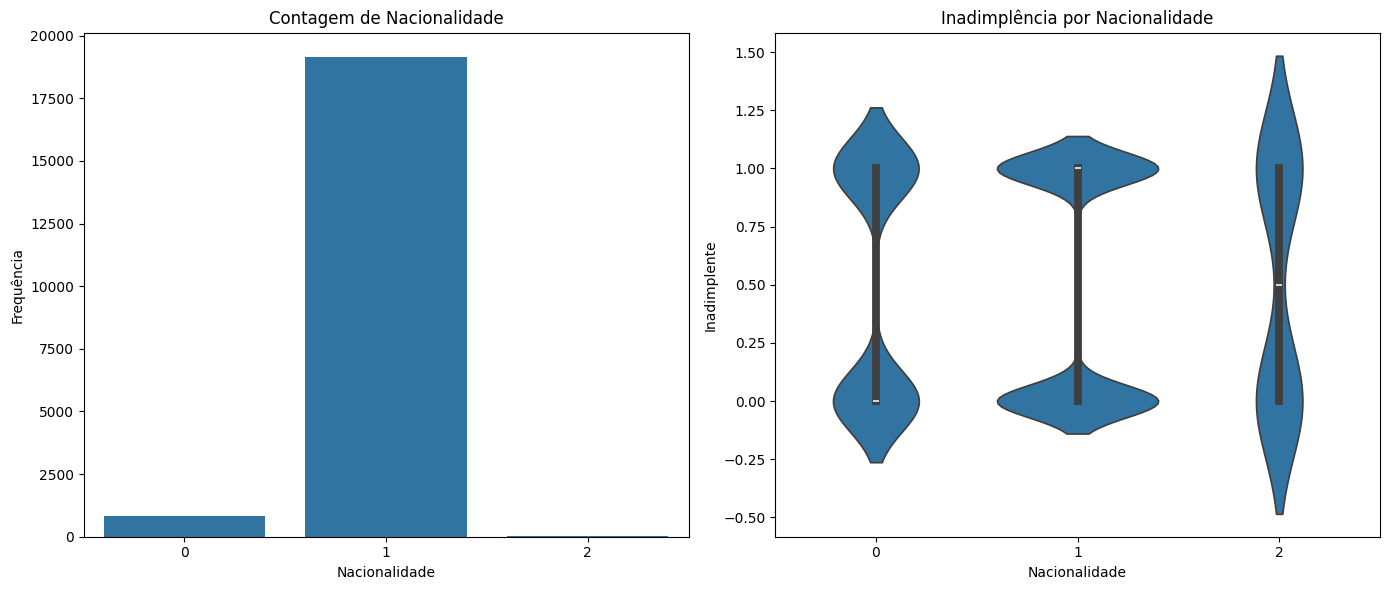

In [62]:
# Criando uma nova coluna para a nacionalidade
df_filtrado['nacionalidade'] = df_filtrado[['nacionalidade_0', 'nacionalidade_1', 'nacionalidade_2']].idxmax(axis=1)

# Extraindo o número da nacionalidade
df_filtrado['nacionalidade'] = df_filtrado['nacionalidade'].str.extract(r'_(\d+)')[0]  # Extrai apenas o número

# Criando a figura e os eixos
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Countplot para nacionalidade, ordenando
sns.countplot(data=df_filtrado, x='nacionalidade', ax=axs[0], order=sorted(df_filtrado['nacionalidade'].dropna().unique(), key=int))
axs[0].set_title('Contagem de Nacionalidade')
axs[0].set_xlabel('Nacionalidade')
axs[0].set_ylabel('Frequência')

# Violinplot para nacionalidade e inadimplência, ordenando
sns.violinplot(data=df_filtrado, x='nacionalidade', y='inadimplente', ax=axs[1], order=sorted(df_filtrado['nacionalidade'].dropna().unique(), key=int))
axs[1].set_title('Inadimplência por Nacionalidade')
axs[1].set_xlabel('Nacionalidade')
axs[1].set_ylabel('Inadimplente')

plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_16272\223416410.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['estado_nascimento'] = df_filtrado[['estado_onde_nasceu_AC', 'estado_onde_nasceu_AL', 'estado_onde_nasceu_AM',
C:\Users\Lucas\AppData\Local\Temp\ipykernel_16272\223416410.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['estado_nascimento'] = df_filtrado['estado_nascimento'].str.extract(r'_(\w\w)$')[0]  # Extrai as duas últimas letras


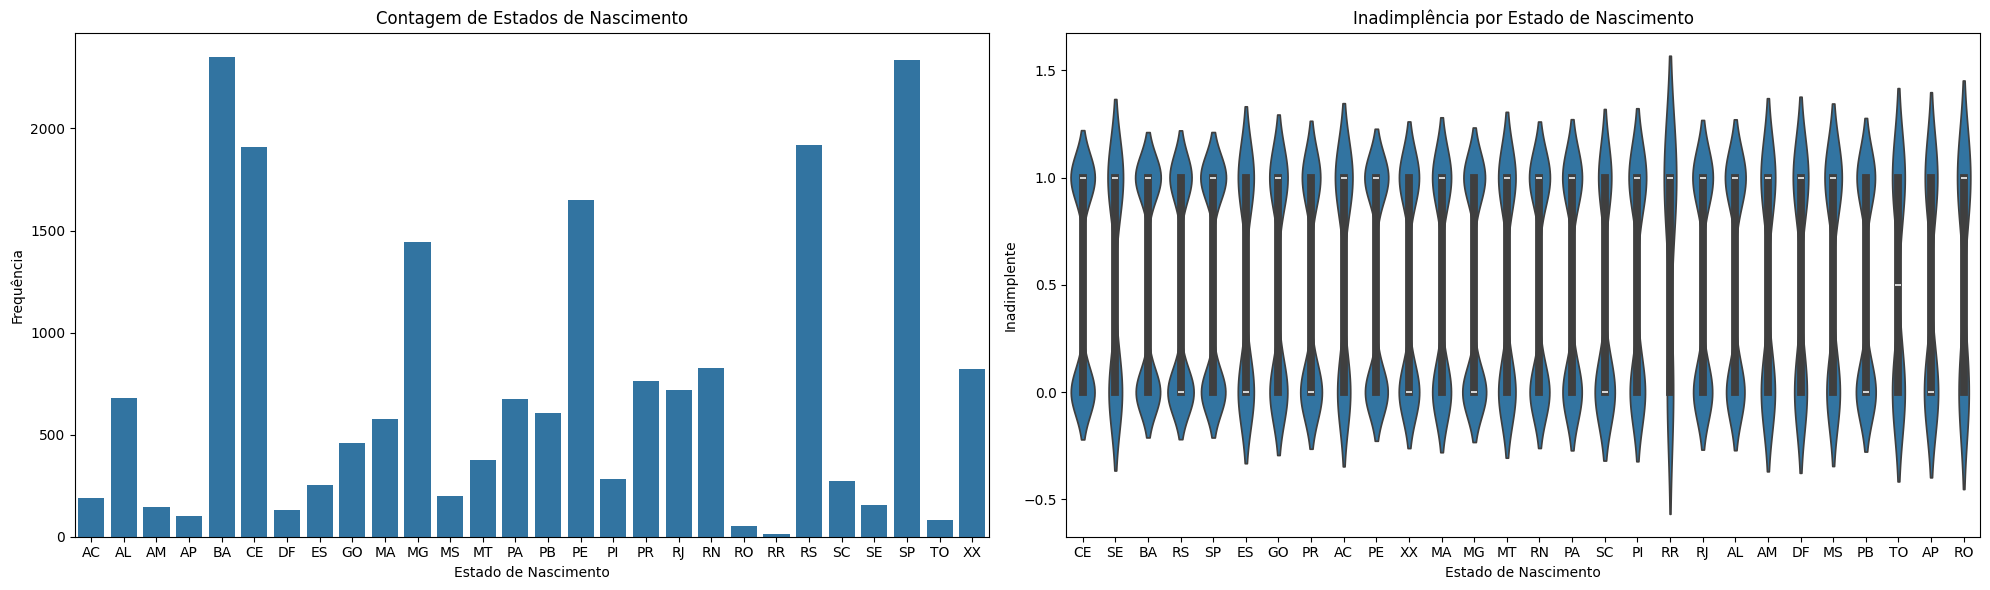

In [63]:
# Criando uma nova coluna para o estado de nascimento
df_filtrado['estado_nascimento'] = df_filtrado[['estado_onde_nasceu_AC', 'estado_onde_nasceu_AL', 'estado_onde_nasceu_AM',
                                                'estado_onde_nasceu_AP', 'estado_onde_nasceu_BA', 'estado_onde_nasceu_CE',
                                                'estado_onde_nasceu_DF', 'estado_onde_nasceu_ES', 'estado_onde_nasceu_GO',
                                                'estado_onde_nasceu_MA', 'estado_onde_nasceu_MG', 'estado_onde_nasceu_MS',
                                                'estado_onde_nasceu_MT', 'estado_onde_nasceu_PA', 'estado_onde_nasceu_PB',
                                                'estado_onde_nasceu_PE', 'estado_onde_nasceu_PI', 'estado_onde_nasceu_PR',
                                                'estado_onde_nasceu_RJ', 'estado_onde_nasceu_RN', 'estado_onde_nasceu_RO',
                                                'estado_onde_nasceu_RR', 'estado_onde_nasceu_RS', 'estado_onde_nasceu_SC',
                                                'estado_onde_nasceu_SE', 'estado_onde_nasceu_SP', 'estado_onde_nasceu_TO',
                                                'estado_onde_nasceu_XX']].idxmax(axis=1)

# Extraindo as duas últimas letras do nome do estado
df_filtrado['estado_nascimento'] = df_filtrado['estado_nascimento'].str.extract(r'_(\w\w)$')[0]  # Extrai as duas últimas letras

# Criando a figura e os eixos
fig, axs = plt.subplots(1, 2, figsize=(20, 6))

# Countplot
sns.countplot(data=df_filtrado, x='estado_nascimento', ax=axs[0], order=sorted(df_filtrado['estado_nascimento'].unique()))
axs[0].set_title('Contagem de Estados de Nascimento')
axs[0].set_xlabel('Estado de Nascimento')
axs[0].set_ylabel('Frequência')

# Violinplot
sns.violinplot(data=df_filtrado, x='estado_nascimento', y='inadimplente', ax=axs[1])
axs[1].set_title('Inadimplência por Estado de Nascimento')
axs[1].set_xlabel('Estado de Nascimento')
axs[1].set_ylabel('Inadimplente')

plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_16272\3999909618.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['estado_residencia'] = df_filtrado[['estado_onde_reside_AC', 'estado_onde_reside_AL', 'estado_onde_reside_AM',
C:\Users\Lucas\AppData\Local\Temp\ipykernel_16272\3999909618.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['estado_residencia'] = df_filtrado['estado_residencia'].str.extract(r'_(\w\w)$')[0]  # Extrai as duas últimas letras


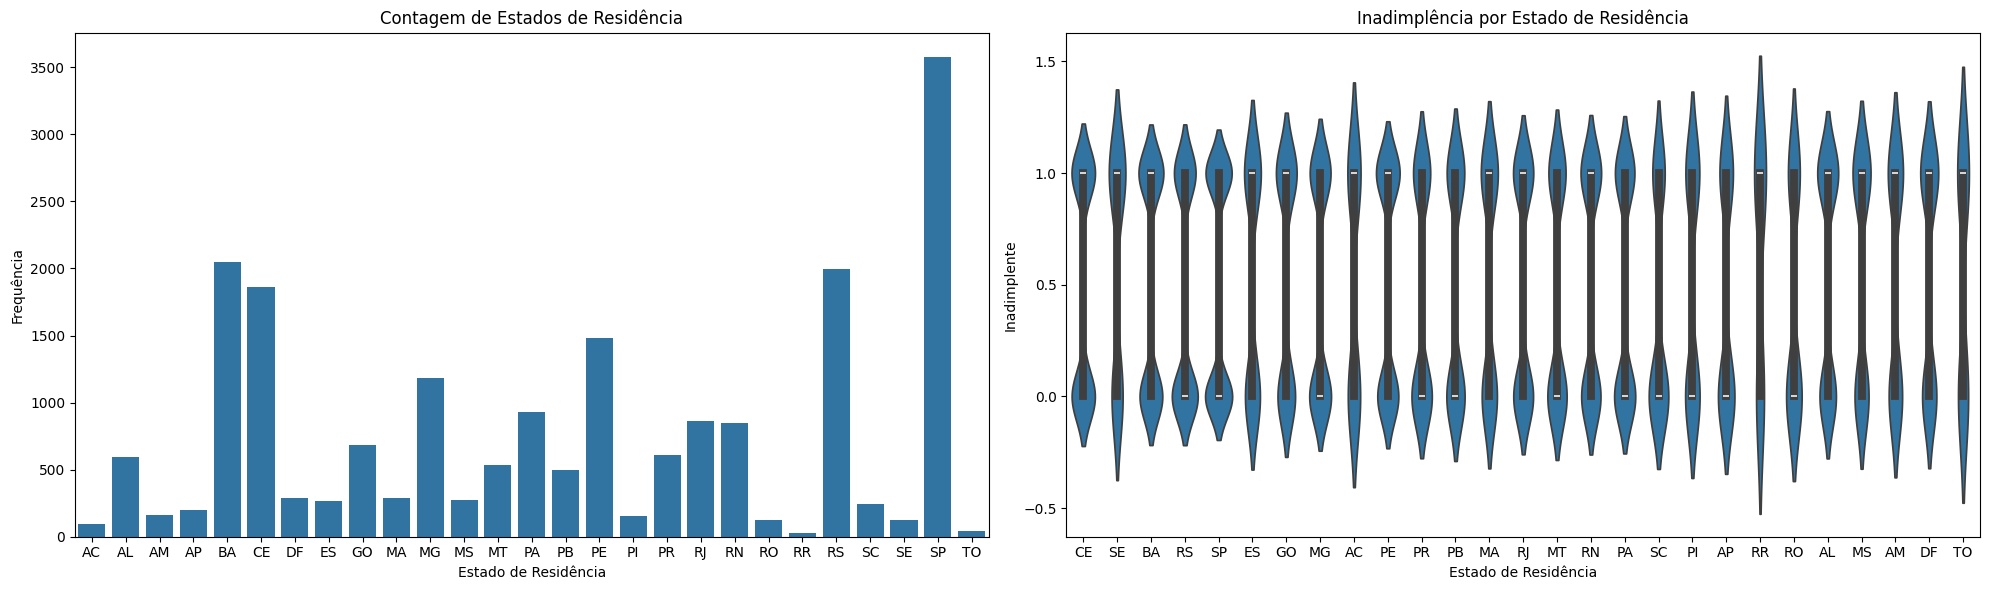

In [64]:
# Criando uma nova coluna para o estado de residência
df_filtrado['estado_residencia'] = df_filtrado[['estado_onde_reside_AC', 'estado_onde_reside_AL', 'estado_onde_reside_AM',
                                                'estado_onde_reside_AP', 'estado_onde_reside_BA', 'estado_onde_reside_CE',
                                                'estado_onde_reside_DF', 'estado_onde_reside_ES', 'estado_onde_reside_GO',
                                                'estado_onde_reside_MA', 'estado_onde_reside_MG', 'estado_onde_reside_MS',
                                                'estado_onde_reside_MT', 'estado_onde_reside_PA', 'estado_onde_reside_PB',
                                                'estado_onde_reside_PE', 'estado_onde_reside_PI', 'estado_onde_reside_PR',
                                                'estado_onde_reside_RJ', 'estado_onde_reside_RN', 'estado_onde_reside_RO',
                                                'estado_onde_reside_RR', 'estado_onde_reside_RS', 'estado_onde_reside_SC',
                                                'estado_onde_reside_SE', 'estado_onde_reside_SP', 'estado_onde_reside_TO']].idxmax(axis=1)

# Extraindo as duas últimas letras do nome do estado
df_filtrado['estado_residencia'] = df_filtrado['estado_residencia'].str.extract(r'_(\w\w)$')[0]  # Extrai as duas últimas letras

# Criando a figura e os eixos
fig, axs = plt.subplots(1, 2, figsize=(20, 6))

# Countplot
sns.countplot(data=df_filtrado, x='estado_residencia', ax=axs[0], order=sorted(df_filtrado['estado_residencia'].unique()))
axs[0].set_title('Contagem de Estados de Residência')
axs[0].set_xlabel('Estado de Residência')
axs[0].set_ylabel('Frequência')

# Violinplot
sns.violinplot(data=df_filtrado, x='estado_residencia', y='inadimplente', ax=axs[1])
axs[1].set_title('Inadimplência por Estado de Residência')
axs[1].set_xlabel('Estado de Residência')
axs[1].set_ylabel('Inadimplente')

plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_16272\3432676173.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['tipo_residencia'] = df_filtrado[['tipo_residencia_-1', 'tipo_residencia_0', 'tipo_residencia_1',
C:\Users\Lucas\AppData\Local\Temp\ipykernel_16272\3432676173.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['tipo_residencia'] = df_filtrado['tipo_residencia'].str.extract(r'_(\d+)$')[0]  # Extrai o número
C:\Users\Lucas\AppData\Local\Temp\ipykernel_16272\3432676173.py:10

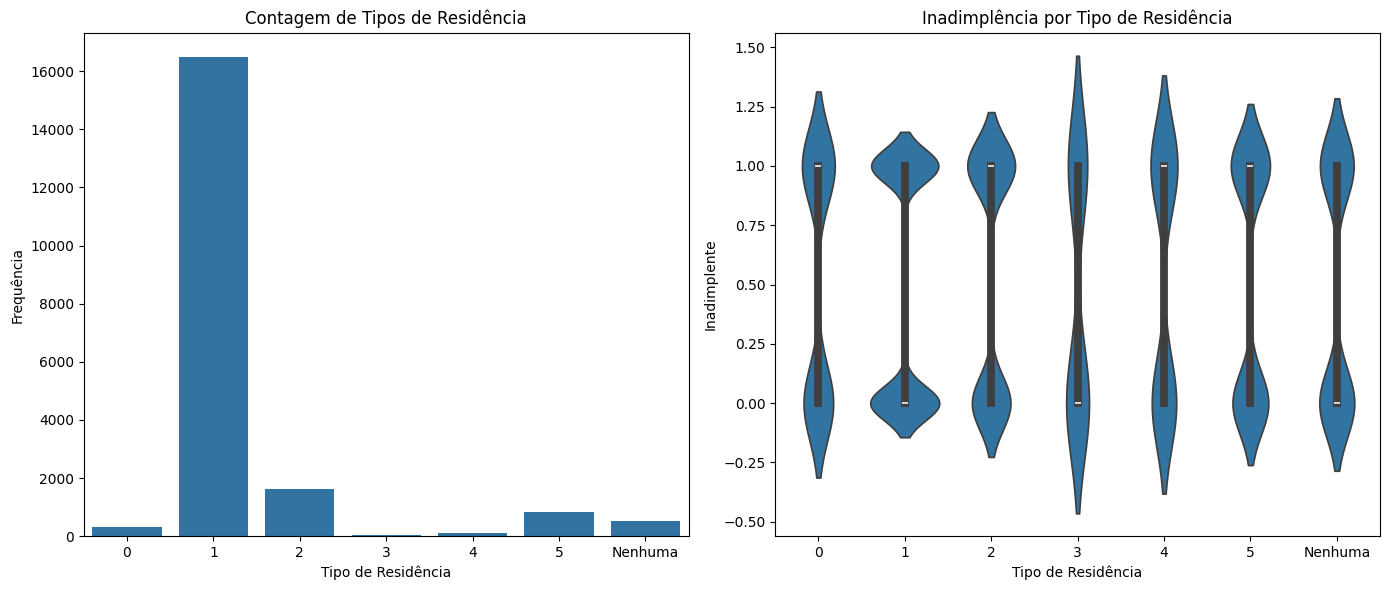

In [65]:
# Criando uma nova coluna para o tipo de residência
df_filtrado['tipo_residencia'] = df_filtrado[['tipo_residencia_-1', 'tipo_residencia_0', 'tipo_residencia_1',
                                               'tipo_residencia_2', 'tipo_residencia_3', 'tipo_residencia_4',
                                               'tipo_residencia_5']].idxmax(axis=1)

# Extraindo o número do tipo de residência
df_filtrado['tipo_residencia'] = df_filtrado['tipo_residencia'].str.extract(r'_(\d+)$')[0]  # Extrai o número

# Preenchendo valores nulos com 'Nenhum'
df_filtrado['tipo_residencia'] = df_filtrado['tipo_residencia'].fillna('Nenhuma')

# Criando a figura e os eixos
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Countplot
sns.countplot(data=df_filtrado, x='tipo_residencia', ax=axs[0], order=sorted(df_filtrado['tipo_residencia'].unique()))
axs[0].set_title('Contagem de Tipos de Residência')
axs[0].set_xlabel('Tipo de Residência')
axs[0].set_ylabel('Frequência')

# Violinplot
sns.violinplot(data=df_filtrado, x='tipo_residencia', y='inadimplente', ax=axs[1],
               order=sorted(df_filtrado['tipo_residencia'].unique()))  # Ordenando o violinplot
axs[1].set_title('Inadimplência por Tipo de Residência')
axs[1].set_xlabel('Tipo de Residência')
axs[1].set_ylabel('Inadimplente')

plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_16272\1238357757.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['profissao'] = df_filtrado[['profissao_-1.0', 'profissao_0.0', 'profissao_1.0', 'profissao_2.0',
C:\Users\Lucas\AppData\Local\Temp\ipykernel_16272\1238357757.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['profissao'] = df_filtrado['profissao'].str.replace('profissao_', '').str.replace('.0', '').astype(int)


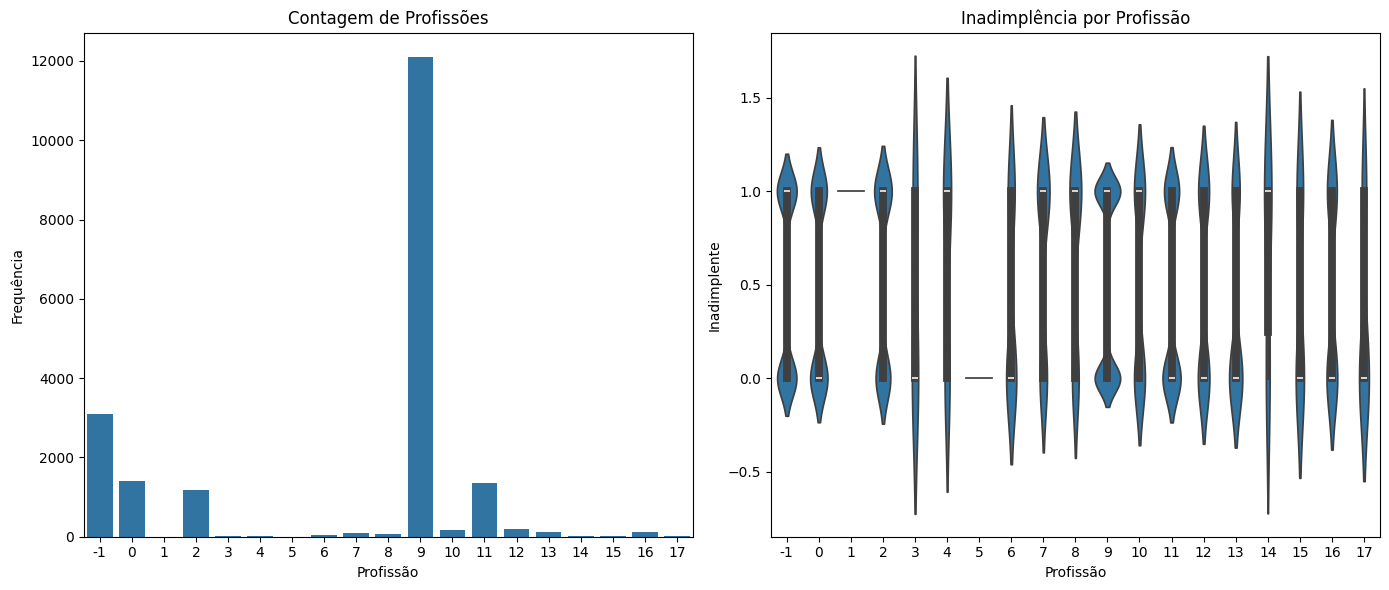

In [66]:
# Extraindo a profissão e removendo o ".0"
df_filtrado['profissao'] = df_filtrado[['profissao_-1.0', 'profissao_0.0', 'profissao_1.0', 'profissao_2.0',
                                         'profissao_3.0', 'profissao_4.0', 'profissao_5.0', 'profissao_6.0',
                                         'profissao_7.0', 'profissao_8.0', 'profissao_9.0', 'profissao_10.0',
                                         'profissao_11.0', 'profissao_12.0', 'profissao_13.0', 'profissao_14.0',
                                         'profissao_15.0', 'profissao_16.0', 'profissao_17.0', 'profissao_18.0']].idxmax(axis=1)

# Remover o prefixo "profissao_" e o sufixo ".0"
df_filtrado['profissao'] = df_filtrado['profissao'].str.replace('profissao_', '').str.replace('.0', '').astype(int)

# Criando a figura e os eixos
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Countplot
sns.countplot(data=df_filtrado, x='profissao', ax=axs[0])
axs[0].set_title('Contagem de Profissões')
axs[0].set_xlabel('Profissão')
axs[0].set_ylabel('Frequência')

# Violinplot
sns.violinplot(data=df_filtrado, x='profissao', y='inadimplente', ax=axs[1], order=sorted(df_filtrado['profissao'].unique()))
axs[1].set_title('Inadimplência por Profissão')
axs[1].set_xlabel('Profissão')
axs[1].set_ylabel('Inadimplente')

plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_16272\27197314.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['ocupacao'] = df_filtrado[['ocupacao_-1.0', 'ocupacao_0.0', 'ocupacao_1.0', 'ocupacao_2.0',
C:\Users\Lucas\AppData\Local\Temp\ipykernel_16272\27197314.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['ocupacao'] = df_filtrado['ocupacao'].str.replace('ocupacao_', '').str.replace('.0', '').astype(int)


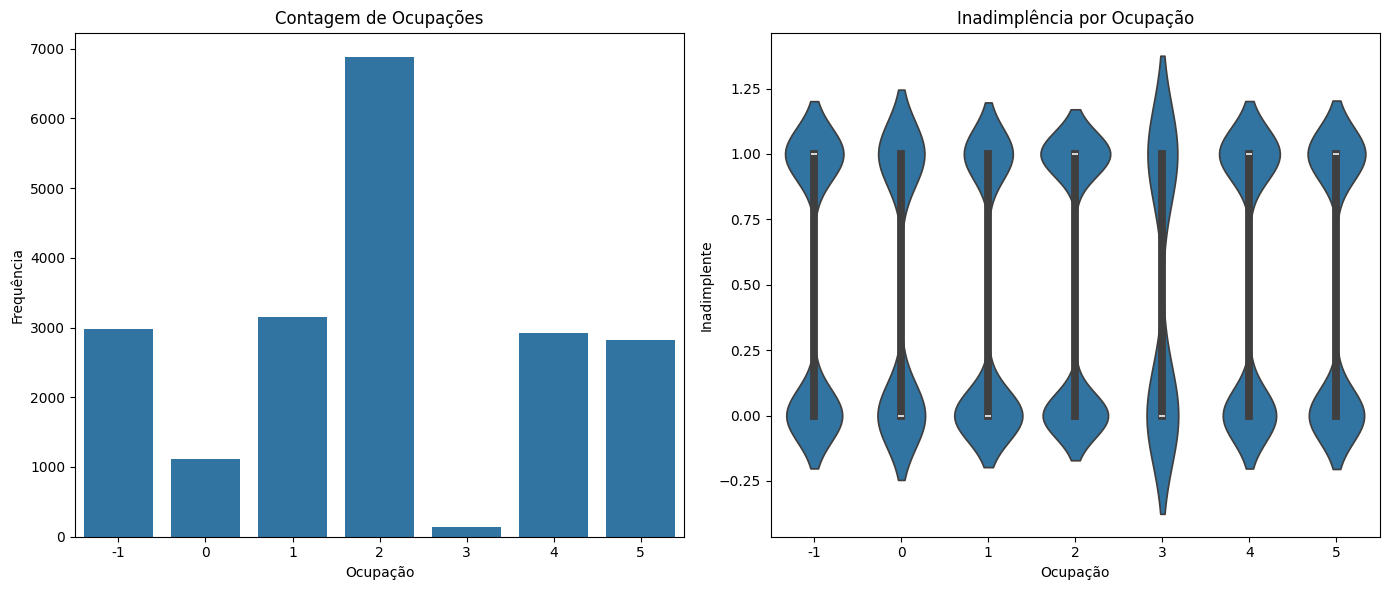

In [67]:
# Extraindo a ocupação e removendo o ".0"
df_filtrado['ocupacao'] = df_filtrado[['ocupacao_-1.0', 'ocupacao_0.0', 'ocupacao_1.0', 'ocupacao_2.0',
                                         'ocupacao_3.0', 'ocupacao_4.0', 'ocupacao_5.0']].idxmax(axis=1)

# Remover o prefixo "ocupacao_" e o sufixo ".0"
df_filtrado['ocupacao'] = df_filtrado['ocupacao'].str.replace('ocupacao_', '').str.replace('.0', '').astype(int)

# Criando a figura e os eixos
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Countplot
sns.countplot(data=df_filtrado, x='ocupacao', ax=axs[0])
axs[0].set_title('Contagem de Ocupações')
axs[0].set_xlabel('Ocupação')
axs[0].set_ylabel('Frequência')

# Violinplot
sns.violinplot(data=df_filtrado, x='ocupacao', y='inadimplente', ax=axs[1], order=sorted(df_filtrado['ocupacao'].unique()))
axs[1].set_title('Inadimplência por Ocupação')
axs[1].set_xlabel('Ocupação')
axs[1].set_ylabel('Inadimplente')

plt.tight_layout()
plt.show()

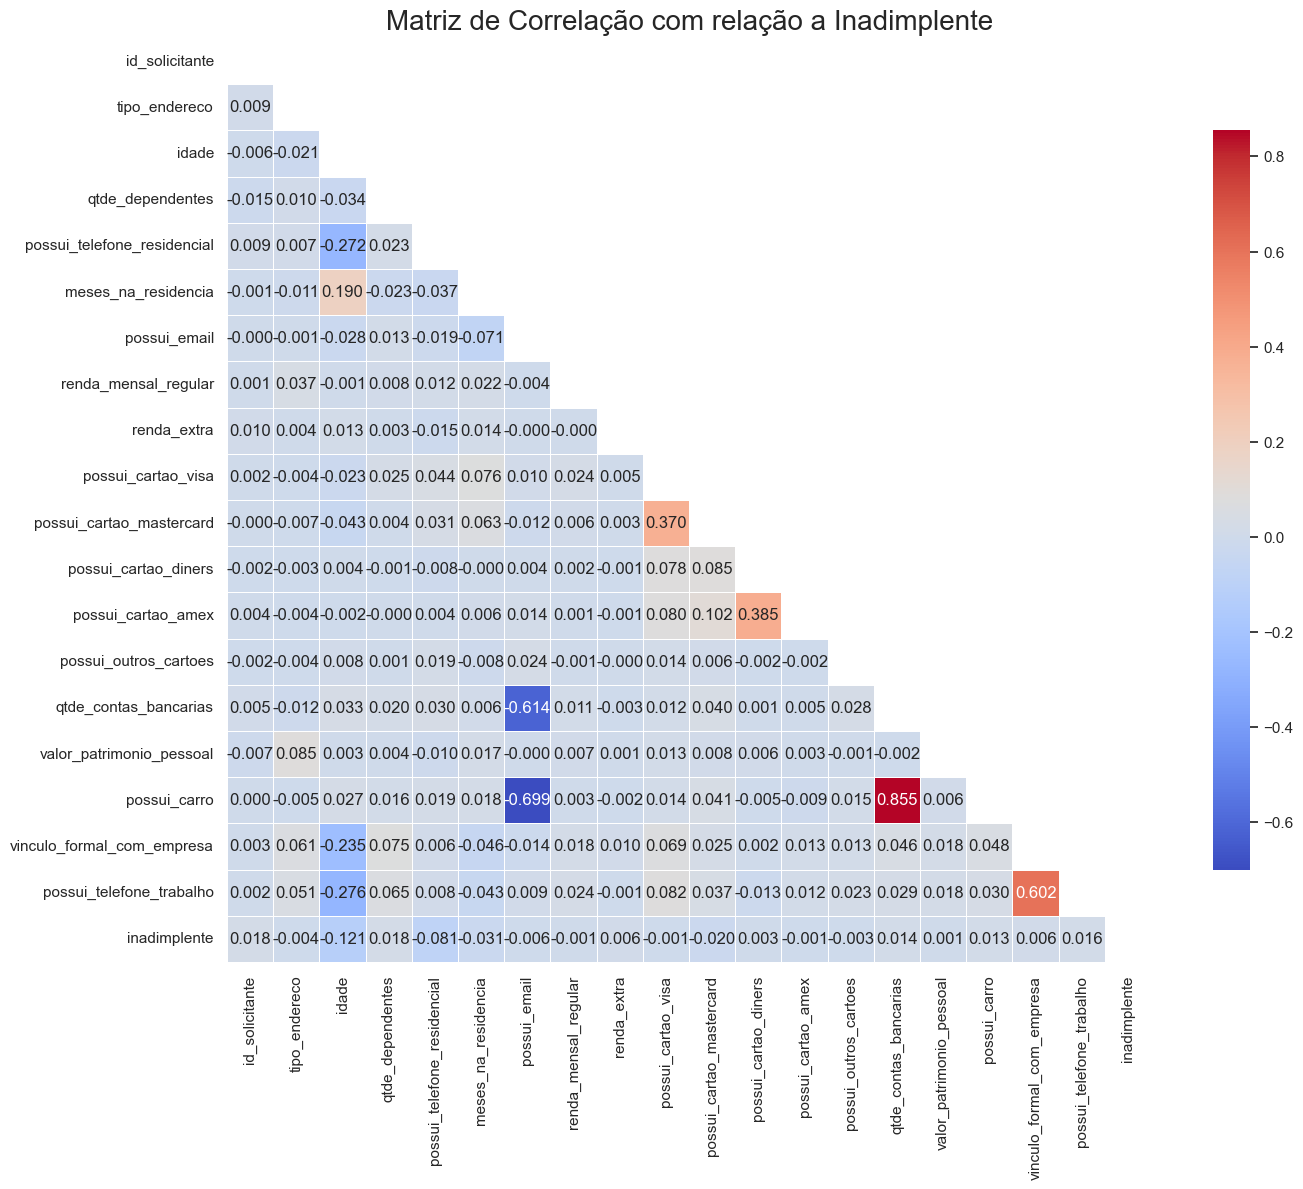

In [68]:
# Filtra as colunas que não serão utilizadas
columns_to_exclude = [
    'produto_solicitado_1', 'produto_solicitado_2', 'produto_solicitado_7', 
    'dia_vencimento_1', 'dia_vencimento_5', 'dia_vencimento_10', 
    'dia_vencimento_15', 'dia_vencimento_20', 'dia_vencimento_25', 
    'forma_envio_solicitacao_correio', 'forma_envio_solicitacao_internet', 
    'forma_envio_solicitacao_presencial', 'sexo_F', 'sexo_M', 'sexo_N', 
    'estado_civil_0', 'estado_civil_1', 'estado_civil_2', 
    'estado_civil_3', 'estado_civil_4', 'estado_civil_5', 
    'estado_civil_6', 'estado_civil_7', 'nacionalidade_0', 
    'nacionalidade_1', 'nacionalidade_2', 'estado_onde_nasceu_AC', 
    'estado_onde_nasceu_AL', 'estado_onde_nasceu_AM', 
    'estado_onde_nasceu_AP', 'estado_onde_nasceu_BA', 
    'estado_onde_nasceu_CE', 'estado_onde_nasceu_DF', 
    'estado_onde_nasceu_ES', 'estado_onde_nasceu_GO', 
    'estado_onde_nasceu_MA', 'estado_onde_nasceu_MG', 
    'estado_onde_nasceu_MS', 'estado_onde_nasceu_MT', 
    'estado_onde_nasceu_PA', 'estado_onde_nasceu_PB', 
    'estado_onde_nasceu_PE', 'estado_onde_nasceu_PI', 
    'estado_onde_nasceu_PR', 'estado_onde_nasceu_RJ', 
    'estado_onde_nasceu_RN', 'estado_onde_nasceu_RO', 
    'estado_onde_nasceu_RR', 'estado_onde_nasceu_RS', 
    'estado_onde_nasceu_SC', 'estado_onde_nasceu_SE', 
    'estado_onde_nasceu_SP', 'estado_onde_nasceu_TO', 
    'estado_onde_nasceu_XX', 'estado_onde_reside_AC', 
    'estado_onde_reside_AL', 'estado_onde_reside_AM', 
    'estado_onde_reside_AP', 'estado_onde_reside_BA', 
    'estado_onde_reside_CE', 'estado_onde_reside_DF', 
    'estado_onde_reside_ES', 'estado_onde_reside_GO', 
    'estado_onde_reside_MA', 'estado_onde_reside_MG', 
    'estado_onde_reside_MS', 'estado_onde_reside_MT', 
    'estado_onde_reside_PA', 'estado_onde_reside_PB', 
    'estado_onde_reside_PE', 'estado_onde_reside_PI', 
    'estado_onde_reside_PR', 'estado_onde_reside_RJ', 
    'estado_onde_reside_RN', 'estado_onde_reside_RO', 
    'estado_onde_reside_RR', 'estado_onde_reside_RS', 
    'estado_onde_reside_SC', 'estado_onde_reside_SE', 
    'estado_onde_reside_SP', 'estado_onde_reside_TO', 
    'tipo_residencia_-1', 'tipo_residencia_0', 
    'tipo_residencia_1', 'tipo_residencia_2', 
    'tipo_residencia_3', 'tipo_residencia_4', 
    'tipo_residencia_5', 'profissao_-1.0', 'profissao_0.0', 
    'profissao_1.0', 'profissao_2.0', 'profissao_3.0', 
    'profissao_4.0', 'profissao_5.0', 'profissao_6.0', 
    'profissao_7.0', 'profissao_8.0', 'profissao_9.0', 
    'profissao_10.0', 'profissao_11.0', 'profissao_12.0', 
    'profissao_13.0', 'profissao_14.0', 'profissao_15.0', 
    'profissao_16.0', 'profissao_17.0', 'profissao_18.0', 
    'ocupacao_-1.0', 'ocupacao_0.0', 'ocupacao_1.0', 
    'ocupacao_2.0', 'ocupacao_3.0', 'ocupacao_4.0', 
    'ocupacao_5.0',
    'ocupacao', 
    'profissao', 
    'tipo_residencia', 
    'estado_residencia', 
    'estado_nascimento', 
    'nacionalidade', 
    'estado_civil', 
    'sexo', 
    'forma_envio_solicitacao', 
    'dia_vencimento', 
    'produto_solicitado'
]

# Seleciona as colunas restantes
df_correlacao = df_filtrado.drop(columns=columns_to_exclude)

# Calcula a matriz de correlação
correlation_matrix = df_correlacao.corr()

# Cria uma máscara para o triângulo superior da matriz
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Configura o gráfico
plt.figure(figsize=(16, 12))
sns.set(style='white')

# Cria um gráfico de calor (heatmap)
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".3f", cmap='coolwarm', square=True, linewidths=.5, cbar_kws={"shrink": .8})

# Adiciona título
plt.title('Matriz de Correlação com relação a Inadimplente', fontsize=20)
plt.show()

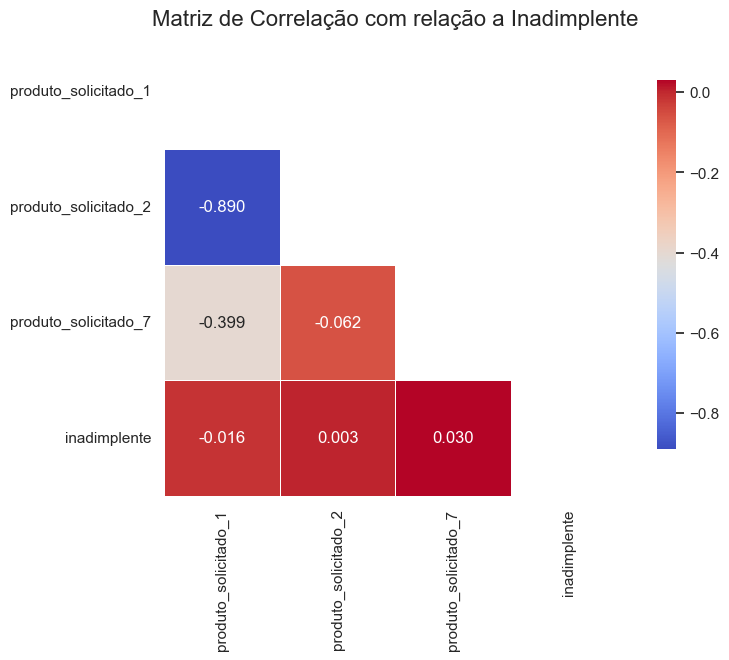

In [69]:
# Filtra as colunas que serão utilizadas
columns_to_include = [
    'produto_solicitado_1', 
    'produto_solicitado_2', 
    'produto_solicitado_7',
    'inadimplente'
]

# Seleciona as colunas relevantes
df_correlacao = df_filtrado[columns_to_include]

# Calcula a matriz de correlação
correlation_matrix = df_correlacao.corr()

# Cria uma máscara para o triângulo superior da matriz
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Configura o gráfico
plt.figure(figsize=(8, 6))
sns.set(style='white')

# Cria um gráfico de calor (heatmap)
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".3f", cmap='coolwarm', square=True, linewidths=.5, cbar_kws={"shrink": .8})

# Adiciona título
plt.title('Matriz de Correlação com relação a Inadimplente', fontsize=16)
plt.show()

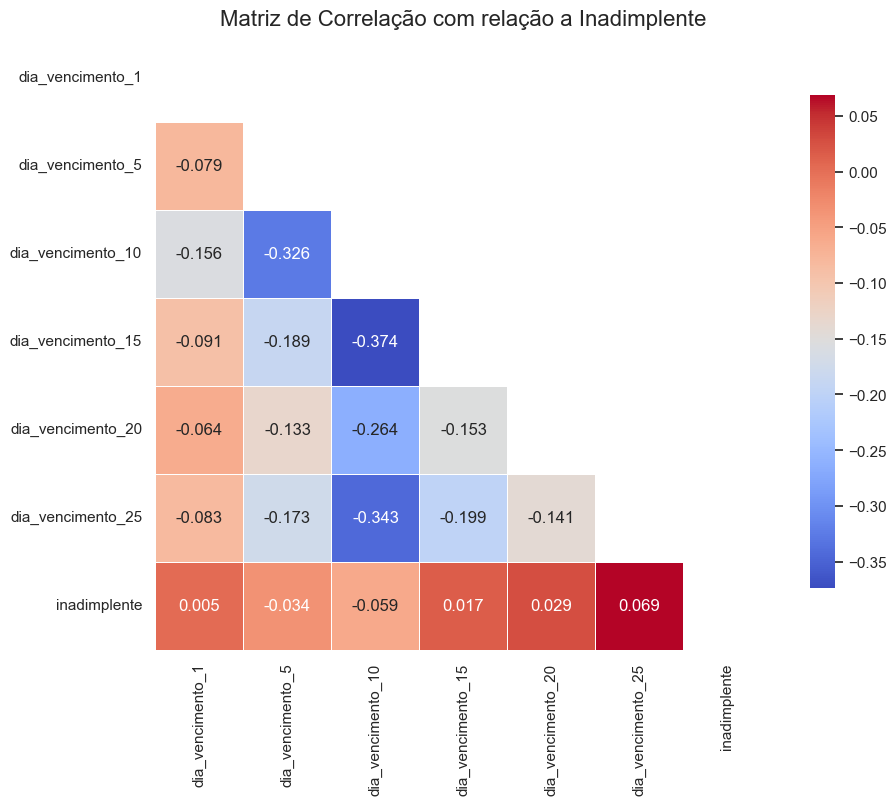

In [70]:
# Filtra as colunas que serão utilizadas
columns_to_include = [
    'dia_vencimento_1', 
    'dia_vencimento_5', 
    'dia_vencimento_10', 
    'dia_vencimento_15', 
    'dia_vencimento_20', 
    'dia_vencimento_25',
    'inadimplente'
]

# Seleciona as colunas relevantes
df_correlacao = df_filtrado[columns_to_include]

# Calcula a matriz de correlação
correlation_matrix = df_correlacao.corr()

# Cria uma máscara para o triângulo superior da matriz
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Configura o gráfico
plt.figure(figsize=(10, 8))
sns.set(style='white')

# Cria um gráfico de calor (heatmap)
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".3f", cmap='coolwarm', square=True, linewidths=.5, cbar_kws={"shrink": .8})

# Adiciona título
plt.title('Matriz de Correlação com relação a Inadimplente', fontsize=16)
plt.show()

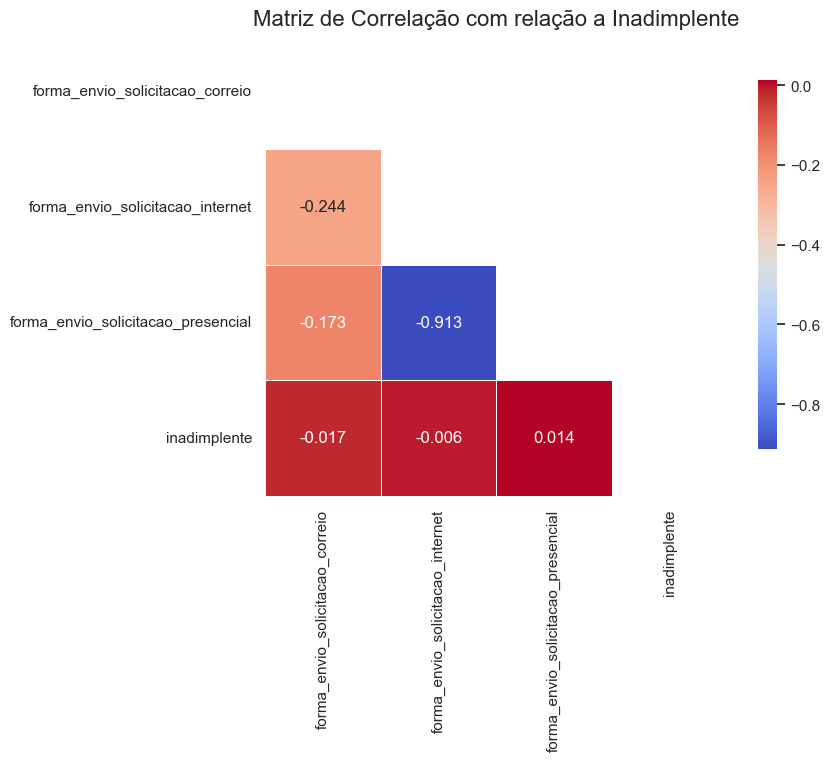

In [71]:
# Filtra as colunas que serão utilizadas
columns_to_include = [
    'forma_envio_solicitacao_correio', 
    'forma_envio_solicitacao_internet', 
    'forma_envio_solicitacao_presencial',
    'inadimplente'
]

# Seleciona as colunas relevantes
df_correlacao = df_filtrado[columns_to_include]

# Calcula a matriz de correlação
correlation_matrix = df_correlacao.corr()

# Cria uma máscara para o triângulo superior da matriz
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Configura o gráfico
plt.figure(figsize=(8, 6))
sns.set(style='white')

# Cria um gráfico de calor (heatmap)
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".3f", cmap='coolwarm', square=True, linewidths=.5, cbar_kws={"shrink": .8})

# Adiciona título
plt.title('Matriz de Correlação com relação a Inadimplente', fontsize=16)
plt.show()

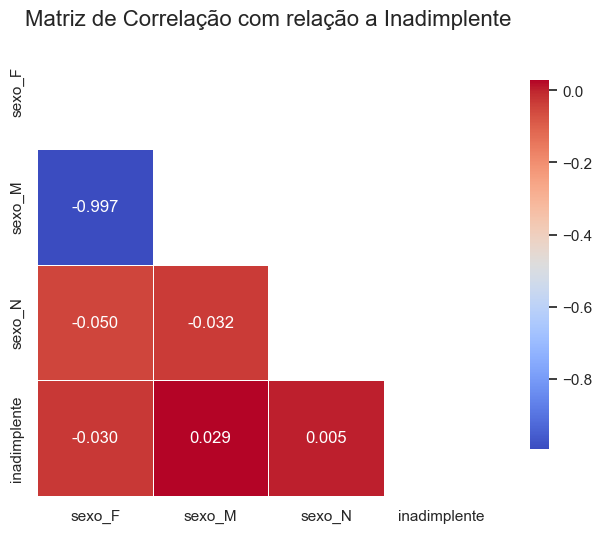

In [72]:
# Filtra as colunas que serão utilizadas
columns_to_include = [ 
    'sexo_F', 
    'sexo_M', 
    'sexo_N',
    'inadimplente',
]

# Seleciona as colunas relevantes
df_correlacao = df_filtrado[columns_to_include]

# Calcula a matriz de correlação
correlation_matrix = df_correlacao.corr()

# Cria uma máscara para o triângulo superior da matriz
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Configura o gráfico
plt.figure(figsize=(8, 6))
sns.set(style='white')

# Cria um gráfico de calor (heatmap)
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".3f", cmap='coolwarm', square=True, linewidths=.5, cbar_kws={"shrink": .8})

# Adiciona título
plt.title('Matriz de Correlação com relação a Inadimplente', fontsize=16)
plt.show()

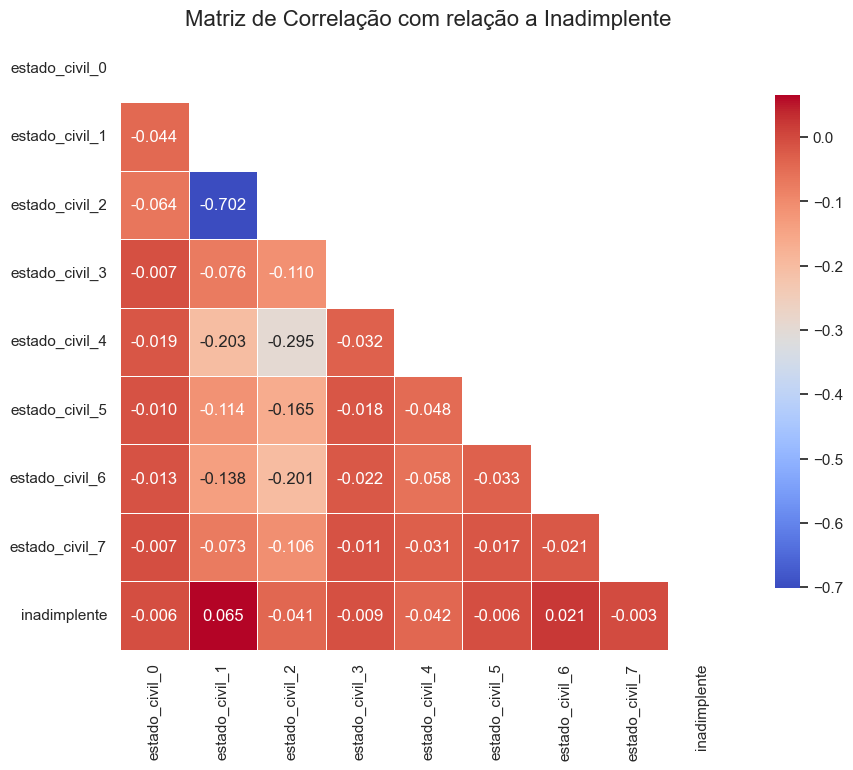

In [73]:
# Filtra as colunas que serão utilizadas
columns_to_include = [
    'estado_civil_0', 
    'estado_civil_1', 
    'estado_civil_2', 
    'estado_civil_3', 
    'estado_civil_4', 
    'estado_civil_5', 
    'estado_civil_6', 
    'estado_civil_7',
    'inadimplente'
]

# Seleciona as colunas relevantes
df_correlacao = df_filtrado[columns_to_include]

# Calcula a matriz de correlação
correlation_matrix = df_correlacao.corr()

# Cria uma máscara para o triângulo superior da matriz
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Configura o gráfico
plt.figure(figsize=(10, 8))
sns.set(style='white')

# Cria um gráfico de calor (heatmap)
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".3f", cmap='coolwarm', square=True, linewidths=.5, cbar_kws={"shrink": .8})

# Adiciona título
plt.title('Matriz de Correlação com relação a Inadimplente', fontsize=16)
plt.show()

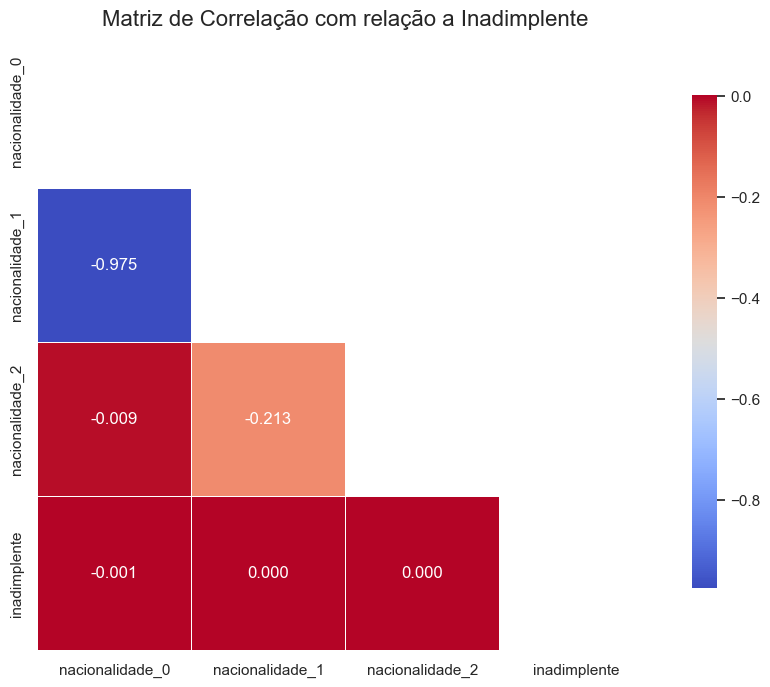

In [74]:
# Filtra as colunas que serão utilizadas
columns_to_include = [ 
    'nacionalidade_0', 
    'nacionalidade_1', 
    'nacionalidade_2',
    'inadimplente'
]

# Seleciona as colunas relevantes
df_correlacao = df_filtrado[columns_to_include]

# Calcula a matriz de correlação
correlation_matrix = df_correlacao.corr()

# Cria uma máscara para o triângulo superior da matriz
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Configura o gráfico
plt.figure(figsize=(10, 8))
sns.set(style='white')

# Cria um gráfico de calor (heatmap)
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".3f", cmap='coolwarm', square=True, linewidths=.5, cbar_kws={"shrink": .8})

# Adiciona título
plt.title('Matriz de Correlação com relação a Inadimplente', fontsize=16)
plt.show()

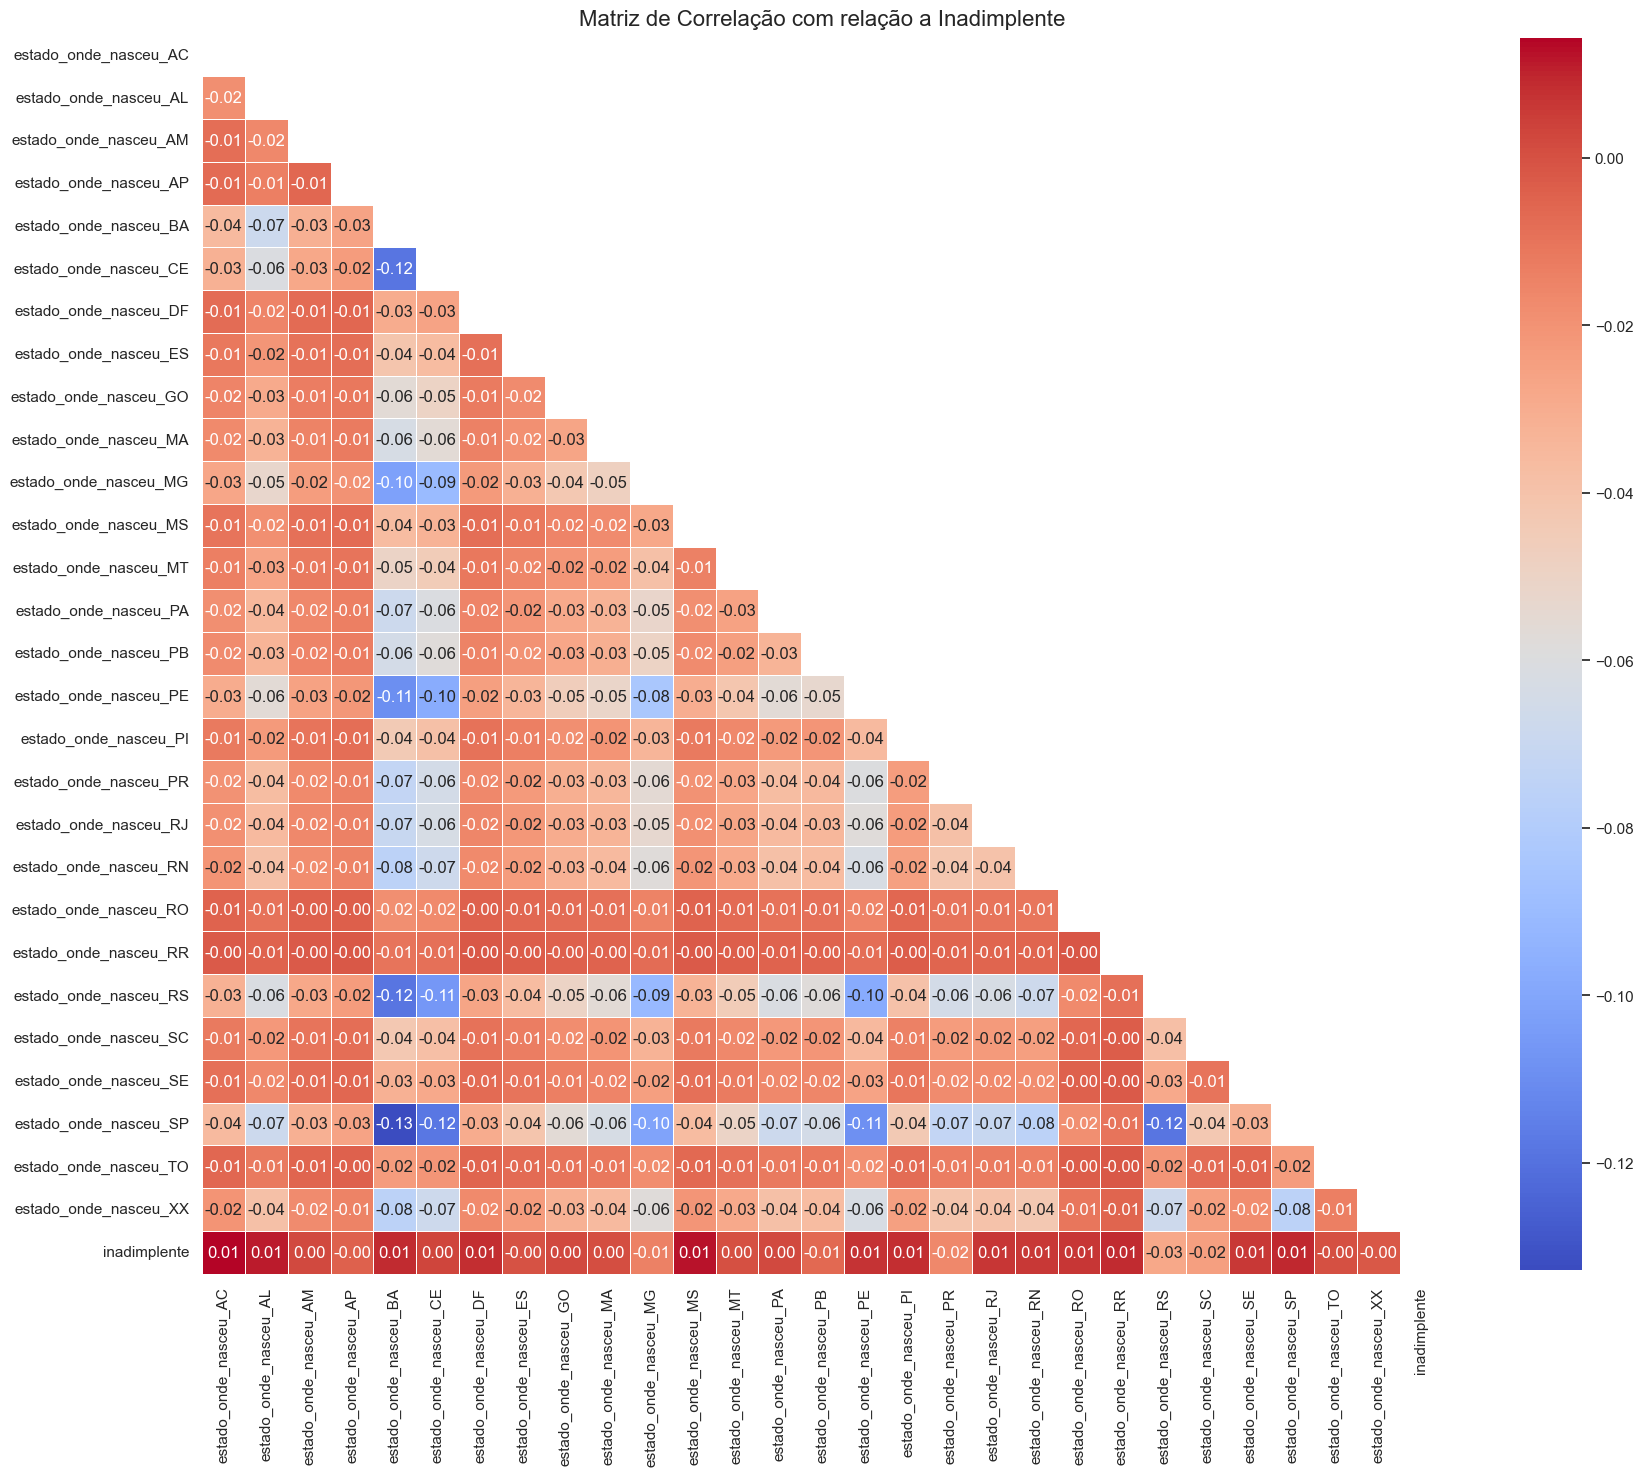

In [75]:
# Filtra as colunas que serão utilizadas
columns_to_include = [
    'estado_onde_nasceu_AC',
    'estado_onde_nasceu_AL',
    'estado_onde_nasceu_AM',
    'estado_onde_nasceu_AP',
    'estado_onde_nasceu_BA',
    'estado_onde_nasceu_CE',
    'estado_onde_nasceu_DF',
    'estado_onde_nasceu_ES',
    'estado_onde_nasceu_GO',
    'estado_onde_nasceu_MA',
    'estado_onde_nasceu_MG',
    'estado_onde_nasceu_MS',
    'estado_onde_nasceu_MT',
    'estado_onde_nasceu_PA',
    'estado_onde_nasceu_PB',
    'estado_onde_nasceu_PE',
    'estado_onde_nasceu_PI',
    'estado_onde_nasceu_PR',
    'estado_onde_nasceu_RJ',
    'estado_onde_nasceu_RN',
    'estado_onde_nasceu_RO',
    'estado_onde_nasceu_RR',
    'estado_onde_nasceu_RS',
    'estado_onde_nasceu_SC',
    'estado_onde_nasceu_SE',
    'estado_onde_nasceu_SP',
    'estado_onde_nasceu_TO',
    'estado_onde_nasceu_XX',
    'inadimplente'
]

# Seleciona as colunas relevantes
df_correlacao = df_filtrado[columns_to_include]

# Calcula a matriz de correlação
correlation_matrix = df_correlacao.corr()

# Cria uma máscara para o triângulo superior da matriz
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Configura o gráfico
plt.figure(figsize=(20, 20))
sns.set(style='white')

# Cria um gráfico de calor (heatmap)
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5, cbar_kws={"shrink": .8})

# Adiciona título
plt.title('Matriz de Correlação com relação a Inadimplente', fontsize=16)
plt.show()

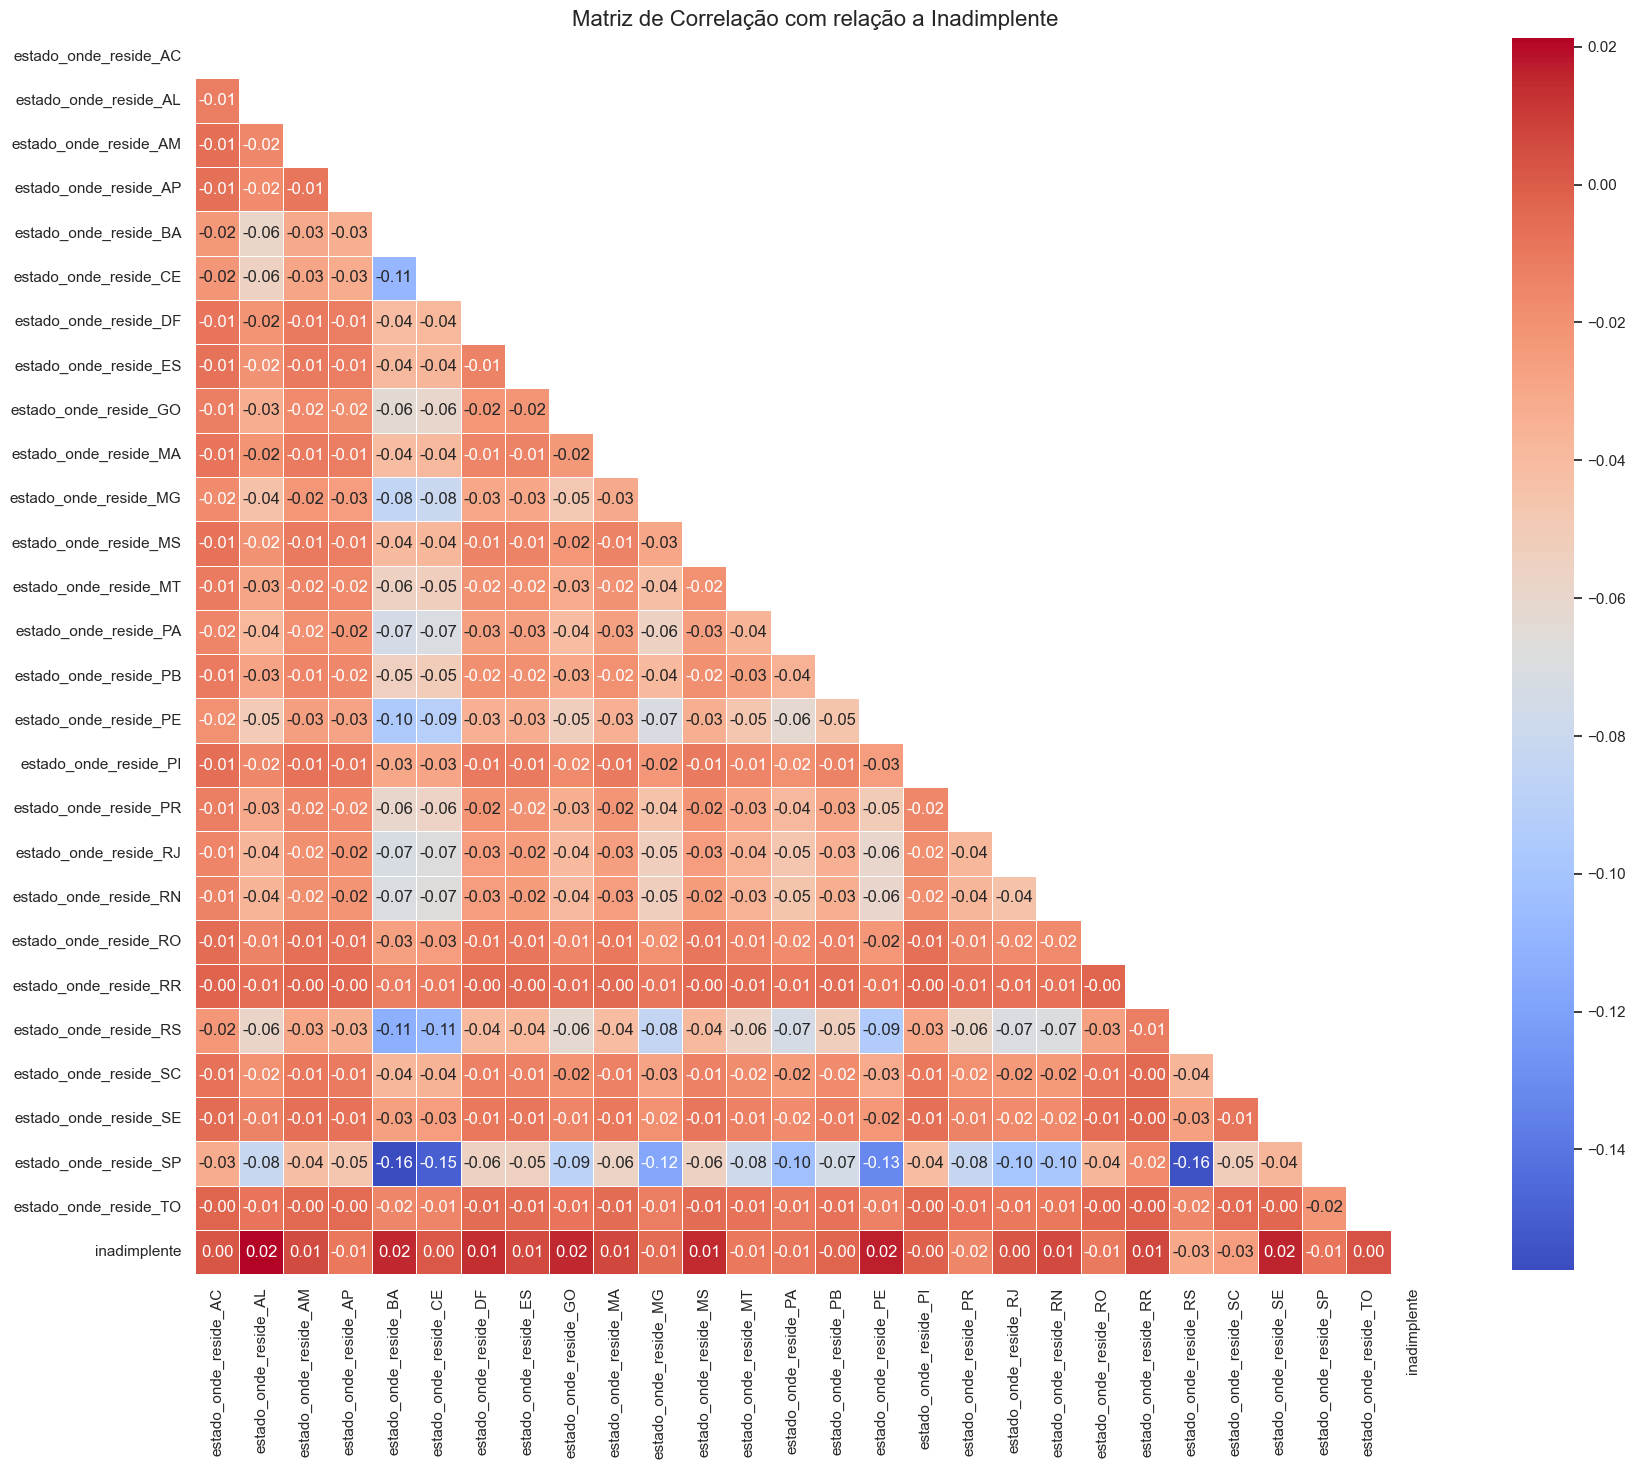

In [76]:
# Filtra as colunas que serão utilizadas
columns_to_include = [
    'estado_onde_reside_AC', 
    'estado_onde_reside_AL', 
    'estado_onde_reside_AM', 
    'estado_onde_reside_AP', 
    'estado_onde_reside_BA', 
    'estado_onde_reside_CE', 
    'estado_onde_reside_DF', 
    'estado_onde_reside_ES', 
    'estado_onde_reside_GO', 
    'estado_onde_reside_MA', 
    'estado_onde_reside_MG', 
    'estado_onde_reside_MS', 
    'estado_onde_reside_MT', 
    'estado_onde_reside_PA', 
    'estado_onde_reside_PB', 
    'estado_onde_reside_PE', 
    'estado_onde_reside_PI', 
    'estado_onde_reside_PR', 
    'estado_onde_reside_RJ', 
    'estado_onde_reside_RN', 
    'estado_onde_reside_RO', 
    'estado_onde_reside_RR', 
    'estado_onde_reside_RS', 
    'estado_onde_reside_SC', 
    'estado_onde_reside_SE', 
    'estado_onde_reside_SP', 
    'estado_onde_reside_TO',
    'inadimplente',
]

# Seleciona as colunas relevantes
df_correlacao = df_filtrado[columns_to_include]

# Calcula a matriz de correlação
correlation_matrix = df_correlacao.corr()

# Cria uma máscara para o triângulo superior da matriz
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Configura o gráfico
plt.figure(figsize=(20, 20))
sns.set(style='white')

# Cria um gráfico de calor (heatmap)
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5, cbar_kws={"shrink": .8})

# Adiciona título
plt.title('Matriz de Correlação com relação a Inadimplente', fontsize=16)
plt.show()

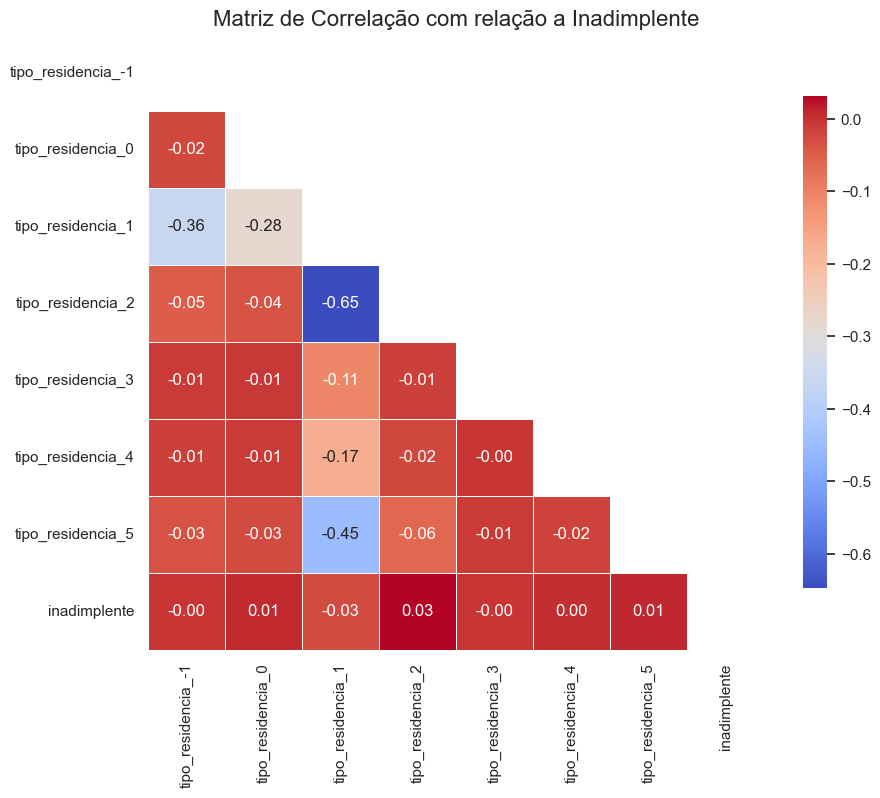

In [77]:
# Filtra as colunas que serão utilizadas
columns_to_include = [
    'tipo_residencia_-1', 
    'tipo_residencia_0', 
    'tipo_residencia_1', 
    'tipo_residencia_2', 
    'tipo_residencia_3', 
    'tipo_residencia_4',
    'tipo_residencia_5',
    'inadimplente'
]

# Seleciona as colunas relevantes
df_correlacao = df_filtrado[columns_to_include]

# Calcula a matriz de correlação
correlation_matrix = df_correlacao.corr()

# Cria uma máscara para o triângulo superior da matriz
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Configura o gráfico
plt.figure(figsize=(10, 8))
sns.set(style='white')

# Cria um gráfico de calor (heatmap)
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5, cbar_kws={"shrink": .8})

# Adiciona título
plt.title('Matriz de Correlação com relação a Inadimplente', fontsize=16)
plt.show()

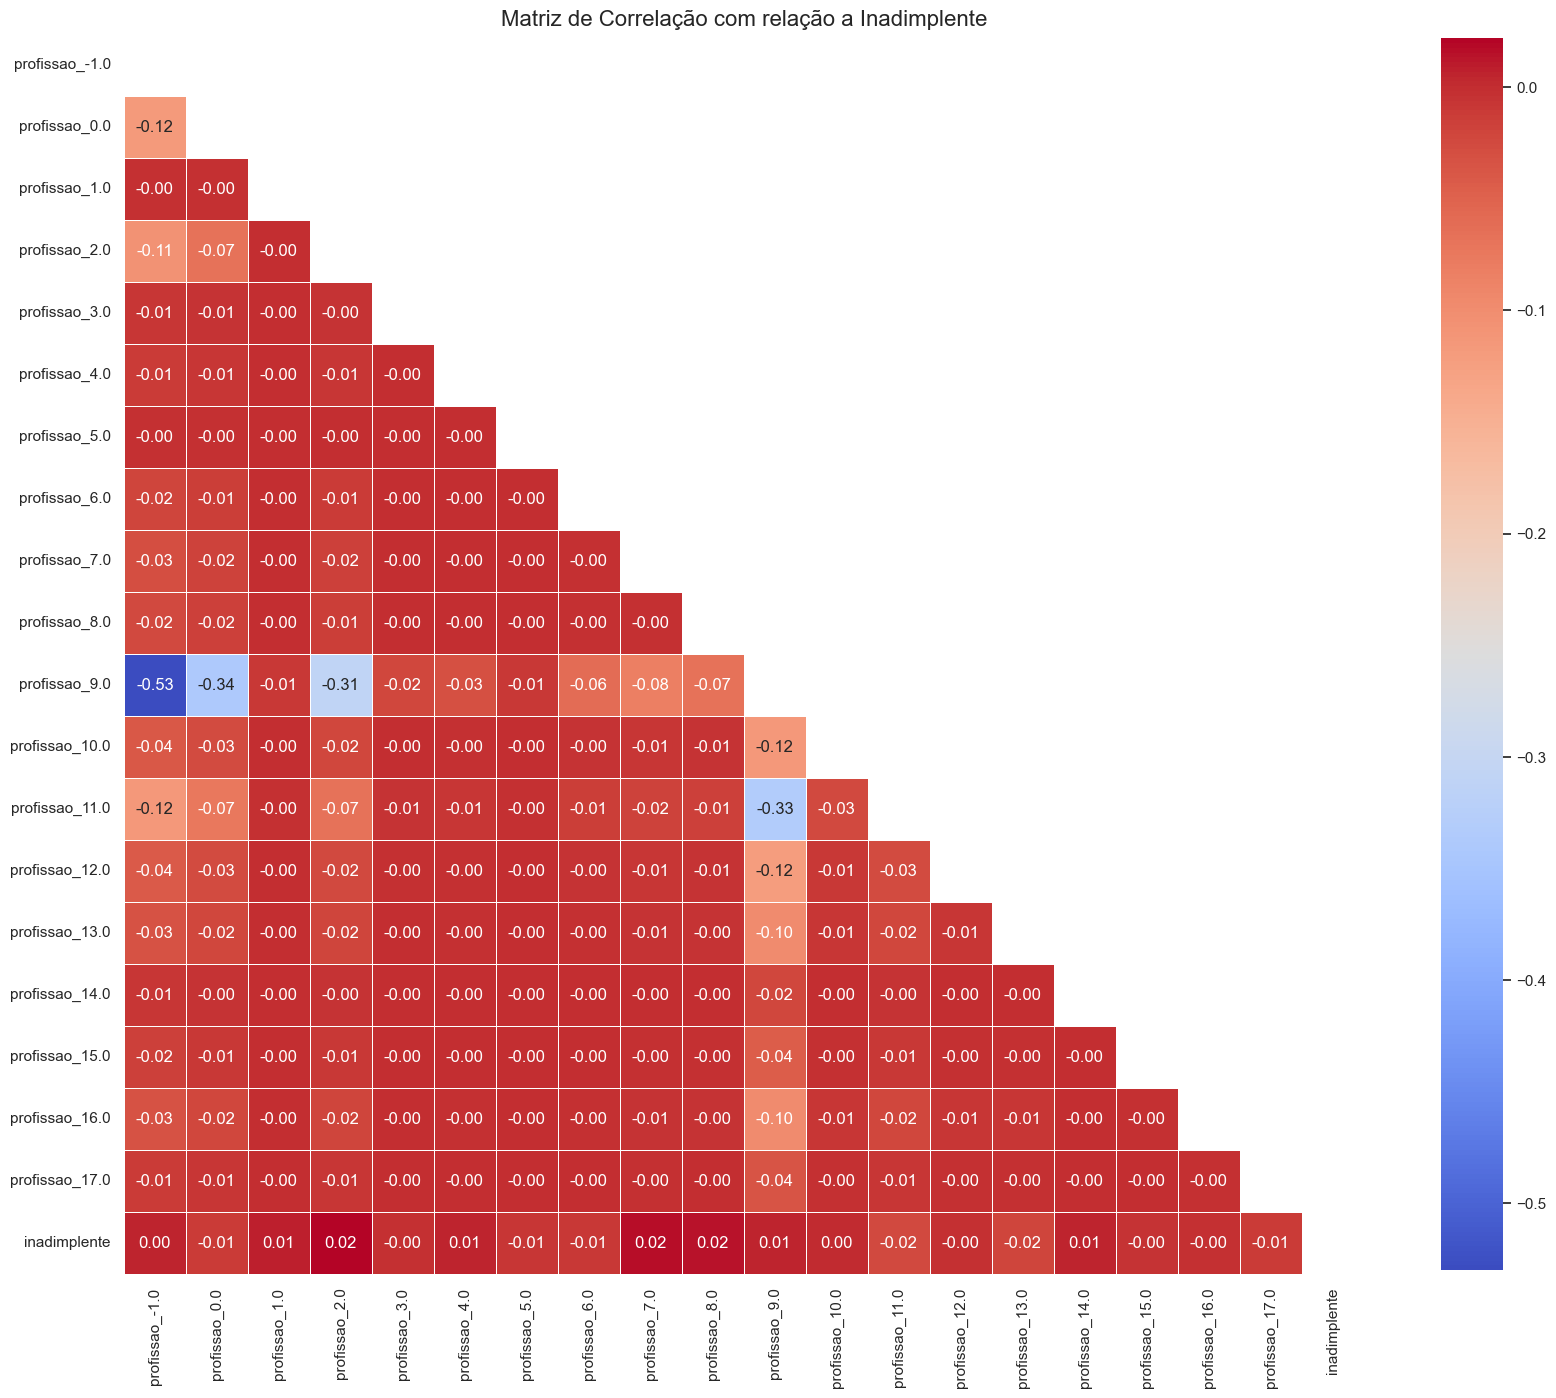

In [78]:
# Filtra as colunas que serão utilizadas
columns_to_include = [
    'profissao_-1.0', 
    'profissao_0.0', 
    'profissao_1.0', 
    'profissao_2.0', 
    'profissao_3.0', 
    'profissao_4.0', 
    'profissao_5.0', 
    'profissao_6.0', 
    'profissao_7.0', 
    'profissao_8.0', 
    'profissao_9.0', 
    'profissao_10.0', 
    'profissao_11.0', 
    'profissao_12.0', 
    'profissao_13.0', 
    'profissao_14.0', 
    'profissao_15.0', 
    'profissao_16.0', 
    'profissao_17.0', 
    'inadimplente',
]

# Seleciona as colunas relevantes
df_correlacao = df_filtrado[columns_to_include]

# Calcula a matriz de correlação
correlation_matrix = df_correlacao.corr()

# Cria uma máscara para o triângulo superior da matriz
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Configura o gráfico
plt.figure(figsize=(20, 20))
sns.set(style='white')

# Cria um gráfico de calor (heatmap)
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5, cbar_kws={"shrink": .8})

# Adiciona título
plt.title('Matriz de Correlação com relação a Inadimplente', fontsize=16)
plt.show()

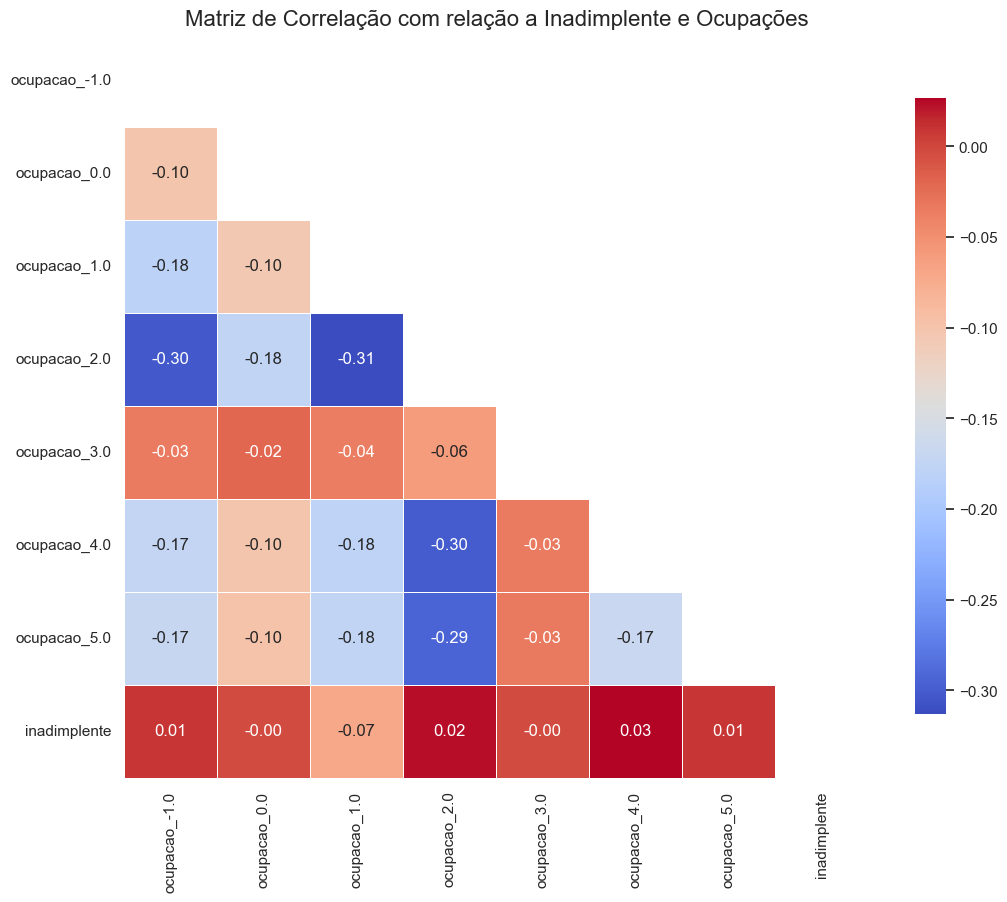

In [79]:
# Filtra as colunas que serão utilizadas
columns_to_include = [
    'ocupacao_-1.0', 
    'ocupacao_0.0', 
    'ocupacao_1.0', 
    'ocupacao_2.0', 
    'ocupacao_3.0', 
    'ocupacao_4.0', 
    'ocupacao_5.0',
    'inadimplente',
]

# Seleciona as colunas relevantes
df_correlacao = df_filtrado[columns_to_include]

# Calcula a matriz de correlação
correlation_matrix = df_correlacao.corr()

# Cria uma máscara para o triângulo superior da matriz
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Configura o gráfico
plt.figure(figsize=(12, 10))
sns.set(style='white')

# Cria um gráfico de calor (heatmap)
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5, cbar_kws={"shrink": .8})

# Adiciona título
plt.title('Matriz de Correlação com relação a Inadimplente e Ocupações', fontsize=16)
plt.show()

## 5. Treinamento do Modelo

In [80]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV

# Separar os dados onde 'inadimplente' não é NA e os que são
df_inadimplente = df[df['inadimplente'].notna()]
df_answer = df[df['inadimplente'].isna()]

# Divisão em train e test (80% para train, 20% para test)
train, test = train_test_split(df_inadimplente, test_size=0.2, random_state=42)

# Identificar colunas numéricas para calcular a correlação
numerical_columns = train.select_dtypes(include=[np.number]).columns

# Calcular a correlação com a variável 'inadimplente'
correlation_matrix = train[numerical_columns].corr()
correlation_with_target = correlation_matrix['inadimplente'].drop('inadimplente').sort_values(ascending=False)

# Selecionar features com correlação relevante (positiva ou negativa)
threshold = 0.005
selected_features = correlation_with_target[
    (correlation_with_target >= threshold) | (correlation_with_target <= -threshold)
].index.tolist()

# Remover o id_solicitante das features selecionadas (se existir)
if 'id_solicitante' in selected_features:
    selected_features.remove('id_solicitante')

print("Features selecionadas:", selected_features)

# Preparar os datasets para o modelo
X_train = train[selected_features]
y_train = train['inadimplente']

X_test = test[selected_features]
y_test = test['inadimplente']

# Configurando modelos e hiperparâmetros para GridSearchCV
models_and_params = {
    'RandomForest': (RandomForestClassifier(random_state=42), {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }),
    'GradientBoosting': (GradientBoostingClassifier(random_state=42), {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    }),
    'HistGradientBoosting': (HistGradientBoostingClassifier(random_state=42), {
        'max_iter': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [None, 10, 20],
        'min_samples_leaf': [10, 20, 30],
        'l2_regularization': [0.0, 0.1, 1.0],
    }),
    'LogisticRegression': (LogisticRegression(random_state=42, max_iter=1000), {
        'penalty': ['l2', 'none'],
        'C': [0.01, 0.1, 1.0, 10.0],
        'solver': ['lbfgs', 'saga']
    })
}

# Melhor modelo e hiperparâmetros
best_model = None
best_score = -np.inf
best_name = ""
best_params = {}

# Realizando GridSearchCV para cada modelo
for name, (model, params) in models_and_params.items():
    print(f"\nTreinando {name} com GridSearchCV...")
    grid_search = GridSearchCV(estimator=model, param_grid=params, scoring='accuracy', cv=3, n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    
    print(f"Melhor score (accuracy) para {name}: {grid_search.best_score_}")
    print(f"Melhores parâmetros para {name}: {grid_search.best_params_}")
    
    if grid_search.best_score_ > best_score:
        best_model = grid_search.best_estimator_
        best_score = grid_search.best_score_
        best_name = name
        best_params = grid_search.best_params_

print(f"\nMelhor modelo: {best_name} com acurácia de {best_score}")
print(f"Melhores parâmetros: {best_params}")

Features selecionadas: ['dia_vencimento_25', 'estado_civil_1', 'produto_solicitado_7', 'sexo_M', 'tipo_residencia_2', 'dia_vencimento_20', 'estado_onde_reside_AL', 'ocupacao_4.0', 'estado_civil_6', 'profissao_2.0', 'ocupacao_2.0', 'dia_vencimento_15', 'qtde_contas_bancarias', 'estado_onde_reside_SE', 'qtde_dependentes', 'forma_envio_solicitacao_presencial', 'profissao_7.0', 'estado_onde_reside_GO', 'estado_onde_reside_BA', 'possui_telefone_trabalho', 'possui_carro', 'profissao_8.0', 'estado_onde_nasceu_AL', 'estado_onde_nasceu_AC', 'tipo_residencia_5', 'tipo_residencia_0', 'estado_onde_nasceu_MS', 'estado_onde_reside_PE', 'estado_onde_nasceu_BA', 'estado_onde_reside_MS', 'estado_onde_nasceu_RR', 'profissao_4.0', 'estado_onde_nasceu_CE', 'estado_onde_reside_DF', 'estado_onde_nasceu_PI', 'ocupacao_5.0', 'estado_onde_nasceu_SP', 'estado_onde_reside_TO', 'ocupacao_-1.0', 'estado_onde_reside_CE', 'profissao_-1.0', 'ocupacao_0.0', 'estado_onde_reside_ES', 'vinculo_formal_com_empresa', 'renda

c:\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
24 fits failed out of a total of 48.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Python312\Lib\site-packages\sklearn\base.py", line 1467, in wrapper
    estimator._validate_params()
  File "c:\Python312\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "c:\Python312\Lib\site-packages\sklearn\utils\_param_validation.py", line 95, in validate_pa

Melhor score (accuracy) para LogisticRegression: 0.5867496686671901
Melhores parâmetros para LogisticRegression: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}

Melhor modelo: GradientBoosting com acurácia de 0.5915619655924783
Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}


c:\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 6. Validação do Modelo

In [81]:
from sklearn.metrics import classification_report

# Avaliar o modelo no conjunto de teste
y_pred = best_model.predict(X_test)
print("\nRelatório de classificação nos dados de teste:")
print(classification_report(y_test, y_pred))


Relatório de classificação nos dados de teste:
              precision    recall  f1-score   support

         0.0       0.61      0.56      0.58      2027
         1.0       0.58      0.63      0.61      1973

    accuracy                           0.60      4000
   macro avg       0.60      0.60      0.60      4000
weighted avg       0.60      0.60      0.60      4000



## 7. Conclusão do Processo

In [82]:
from datetime import datetime

# Aplicar o modelo no conjunto 'answer'
X_answer = df_answer[selected_features]
df_answer_result = df_answer[['id_solicitante']].copy()
df_answer_result['inadimplente'] = best_model.predict(X_answer).astype(int)

# Gerar timestamp para o nome do arquivo
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
file_name = f"data/resposta_final_{timestamp}.csv"

# Salvar a resposta final
df_answer_result.to_csv(file_name, index=False)

print(f"\nArquivo '{file_name}' salvo com as predições para o conjunto answer.")


Arquivo 'data/resposta_final_20241209_201211.csv' salvo com as predições para o conjunto answer.
